# IDC vs ILC Classification Using Gene Expression Data
## Publication-Grade Experimental Analysis

### Research Study
**A Comparative Analysis of Logistic Regression, Random Forest, and XGBoost for Classifying Infiltrating Ductal Carcinoma (IDC) and Infiltrating Lobular Carcinoma (ILC) Using Gene Expression Data**

### Objective
To systematically compare Logistic Regression, Random Forest, and XGBoost for gene-expression-based classification of IDC and ILC, with emphasis on predictive performance, statistical reliability, uncertainty estimation, and model interpretability.

### Experimental Framework
1. Dataset verification and quality control
2. Stratified train-test separation
3. Leakage-safe preprocessing
4. Feature-selection analysis
5. Repeated stratified cross-validation
6. Hyperparameter optimization
7. Model comparison
8. Statistical significance testing
9. Confidence-interval estimation
10. SHAP-based model interpretation
11. Consensus predictive-gene analysis
12. Biological interpretation
13. External validation feasibility assessment

### Reproducibility
All experiments use fixed random seeds and explicitly documented preprocessing, validation, and model-selection procedures.

In [2]:
# ============================================================
# CELL 2 — Reproducibility Configuration
# ============================================================

import os
import random
import numpy as np

# Global random seed
RANDOM_STATE = 42

# Python random seed
random.seed(RANDOM_STATE)

# NumPy random seed
np.random.seed(RANDOM_STATE)

# Hash seed for reproducibility
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

print("Reproducibility configuration initialized.")
print(f"Random state: {RANDOM_STATE}")

Reproducibility configuration initialized.
Random state: 42


In [3]:
# ============================================================
# CELL 3 — Core Scientific Libraries
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display configuration
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

# Plotting configuration
plt.rcParams["figure.figsize"] = (10, 6)

print("Core libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Core libraries imported successfully.
Pandas version: 2.3.3
NumPy version: 2.3.5


In [4]:
# ============================================================
# CELL 4 — Dataset Path Verification
# ============================================================

DATA_PATH = Path("brca_data_w_subtypes.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}\n"
        "Make sure brca_data_w_subtypes.csv is in the same folder as this notebook."
    )

print("Dataset located successfully.")
print(f"Dataset path: {DATA_PATH.resolve()}")

Dataset located successfully.
Dataset path: C:\Users\Admin\Desktop\brca_research\brca_data_w_subtypes.csv


In [5]:
# ============================================================
# CELL 5 — Load Raw Dataset
# ============================================================

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset loaded successfully.
Rows    : 705
Columns : 1941


In [6]:
# ============================================================
# CELL 6 — Raw Dataset Quality Audit
# ============================================================

print("=" * 70)
print("RAW DATASET QUALITY AUDIT")
print("=" * 70)

# 1. Dataset dimensions
print(f"\nDataset shape: {df.shape}")

# 2. First five rows
print("\nFirst 5 rows:")
display(df.head())

# 3. Data types
print("\nData type distribution:")
print(df.dtypes.value_counts())

# 4. Missing values
missing_values = df.isnull().sum()

print("\nMissing-value summary:")
print(f"Total missing cells       : {missing_values.sum()}")
print(f"Columns with missing data : {(missing_values > 0).sum()}")

# 5. Duplicate rows
duplicate_rows = df.duplicated().sum()

print("\nDuplicate-row summary:")
print(f"Duplicate rows: {duplicate_rows}")

# 6. Column names
print("\nFirst 20 column names:")
print(df.columns[:20].tolist())

print("\nLast 20 column names:")
print(df.columns[-20:].tolist())

RAW DATASET QUALITY AUDIT

Dataset shape: (705, 1941)

First 5 rows:


,rs_CLEC3A,rs_CPB1,rs_SCGB2A2,rs_SCGB1D2,rs_TFF1,rs_MUCL1,rs_GSTM1,rs_PIP,rs_ADIPOQ,rs_ADH1B,rs_S100A7,rs_HMGCS2,rs_CYP2B7P1,rs_ANKRD30A,rs_PRAME,rs_TAT,rs_SERPINA6,rs_AGR3,rs_TFAP2B,rs_CYP4Z1,rs_DHRS2,rs_KCNJ3,rs_MYBPC1,rs_C4orf7,rs_KRT14,rs_MUC6,rs_UGT2B11,rs_GABRP,rs_SOX10,rs_SLC30A8,rs_STAC2,rs_VSTM2A,rs_COL2A1,rs_KRT5,rs_TUSC5,rs_CEACAM5,rs_CALML5,rs_GP2,rs_GSTT1,rs_LEP,rs_FABP7,rs_C1orf64,rs_CRABP1,rs_FABP4,rs_KRT6B,rs_KLK11,rs_CST9,rs_CST1,rs_PIGR,rs_CIDEC,...,pp_Src.pY416,pp_Src.pY527,pp_Stathmin,pp_Syk,pp_TAZ,pp_TFRC,pp_TIGAR,pp_TSC1,pp_Transglutaminase,pp_Tuberin,pp_Tuberin.pT1462,pp_VEGFR2,pp_XBP1,pp_XRCC1,pp_YAP,pp_YAP.pS127,pp_YB.1,pp_YB.1.pS102,pp_beta.Catenin,pp_c.Abl,pp_c.Jun.pS73,pp_c.Kit,pp_c.Met,pp_c.Met.pY1235,pp_c.Myc,pp_cIAP,pp_eEF2,pp_eEF2K,pp_eIF4E,pp_eIF4G,pp_mTOR,pp_mTOR.pS2448,pp_p16.INK4a,pp_p21,pp_p27,pp_p27.pT157,pp_p27.pT198,pp_p38.MAPK,pp_p38.pT180.Y182,pp_p53,pp_p62.LCK.ligand,pp_p70S6K,pp_p70S6K.pT389,pp_p90RSK,pp_p90RSK.pT359.S363,vital.status,PR.Status,ER.Status,HER2.Final.Status,histological.type
0,0.892818,6.580103,14.123672,10.606501,13.189237,6.649466,10.520335,10.338490,10.248379,10.229970,0.000000,7.904609,8.754801,9.681176,9.363258,2.146395,1.440208,12.806272,11.675896,2.618427,8.375717,0.892818,6.437639,6.056274,12.534884,10.209759,3.878617,7.533045,8.279545,8.790134,10.540809,7.265341,7.131664,12.639518,7.305826,2.892605,5.175089,10.490143,0.514400,4.514034,2.715718,11.553750,4.618368,9.310698,8.858305,11.622206,1.836086,10.461061,7.109456,7.800338,...,0.457514,0.526354,0.007085,-0.308787,0.006072,-0.430743,0.309510,0.131346,-0.168066,0.100690,0.304857,-0.116584,-0.165253,0.186194,0.034034,0.429607,-0.311868,-0.026893,0.626281,-0.157971,0.089281,0.797100,-0.159531,-0.093515,0.383546,0.236110,-0.144989,0.644601,0.057622,-0.201801,0.280051,0.003707,0.190428,-0.203587,-0.022273,-0.027042,-0.043330,-0.002598,0.449228,-0.375230,-0.691766,-0.337863,-0.178503,0.011638,-0.207257,0,Positive,Positive,Negative,infiltrating ductal carcinoma
1,0.000000,3.691311,17.116090,15.517231,9.867616,9.691667,8.179522,7.911723,1.289598,1.818891,0.444879,1.289598,5.698288,7.885523,1.818891,2.415164,0.000000,9.798502,11.575206,3.039682,11.504695,3.218239,8.544378,6.833406,11.621912,0.784336,8.881055,9.883700,8.374239,0.784336,9.061837,0.000000,3.880078,11.379258,0.000000,5.213942,4.502662,7.707524,9.336238,0.000000,4.986320,8.332823,5.636787,3.474086,9.006180,1.488412,0.444879,7.803937,7.088217,0.444879,...,0.106521,0.693548,0.023711,-0.151781,-0.048764,0.044882,-0.053722,0.117277,-0.232628,0.004979,0.212137,-0.699373,-0.075506,-0.003801,0.028424,0.699928,-0.062488,0.123237,0.402182,0.018522,0.403643,0.706403,-0.076541,-0.071801,-0.213370,0.006368,0.089477,0.075170,0.403337,0.344308,-0.434912,0.258330,0.890194,0.300936,-0.101746,-0.071406,-0.220764,0.220809,1.035115,-0.074136,0.279067,0.292925,-0.155242,-0.089365,0.267530,0,Positive,Negative,Negative,infiltrating ductal carcinoma
2,3.748150,4.375255,9.658123,5.326983,12.109539,11.644307,10.517330,5.114925,11.975349,11.911437,4.126056,9.383379,8.630913,9.610310,4.733674,16.173177,6.791025,7.728365,8.290137,2.776694,16.189475,4.987639,2.328779,2.613815,11.820689,0.000000,1.068602,8.652057,6.592058,3.897269,6.635168,3.022492,11.648423,12.322540,9.238884,8.572504,9.859580,4.032409,3.932260,10.124532,3.786900,7.345917,2.328779,11.459524,9.417736,2.697551,3.117994,9.113967,6.022692,9.309617,...,0.128197,-0.457486,-0.067221,-0.410492,-0.055343,-0.721898,-0.208661,0.178694,0.317789,-0.397810,0.275979,0.865658,-0.138619,-0.304095,0.371284,1.255106,-0.016487,-0.217157,-0.317625,-0.337285,-0.258973,0.223548,-0.001280,0.018057,-0.052187,0.312086,-0.243315,0.055800,0.226836,0.051263,0.032322,-0.128815,-0.012366,-0.050121,0.119749,0.001280,0.010615,-0.133214,0.344969,-0.351936,0.219910,0.308110,-0.190794,-0.222150,-0.198518,0,Positive,Positive,Negative,infiltrating ductal carcinoma
3,0.000000,18.235519,18.535480,14.533584,14.078992,8.913760,10.557465,13.304434,8.205059,9.


Data type distribution:
int64      1110
float64     827
object        4
Name: count, dtype: int64

Missing-value summary:
Total missing cells       : 389
Columns with missing data : 3

Duplicate-row summary:
Duplicate rows: 0

First 20 column names:
['rs_CLEC3A', 'rs_CPB1', 'rs_SCGB2A2', 'rs_SCGB1D2', 'rs_TFF1', 'rs_MUCL1', 'rs_GSTM1', 'rs_PIP', 'rs_ADIPOQ', 'rs_ADH1B', 'rs_S100A7', 'rs_HMGCS2', 'rs_CYP2B7P1', 'rs_ANKRD30A', 'rs_PRAME', 'rs_TAT', 'rs_SERPINA6', 'rs_AGR3', 'rs_TFAP2B', 'rs_CYP4Z1']

Last 20 column names:
['pp_mTOR', 'pp_mTOR.pS2448', 'pp_p16.INK4a', 'pp_p21', 'pp_p27', 'pp_p27.pT157', 'pp_p27.pT198', 'pp_p38.MAPK', 'pp_p38.pT180.Y182', 'pp_p53', 'pp_p62.LCK.ligand', 'pp_p70S6K', 'pp_p70S6K.pT389', 'pp_p90RSK', 'pp_p90RSK.pT359.S363', 'vital.status', 'PR.Status', 'ER.Status', 'HER2.Final.Status', 'histological.type']


In [7]:
# ============================================================
# CELL 7 — Target and Metadata Audit
# ============================================================

TARGET_COLUMN = "histological.type"

print("=" * 70)
print("TARGET AND METADATA AUDIT")
print("=" * 70)

# Verify target exists
if TARGET_COLUMN not in df.columns:
    raise KeyError(
        f"Target column '{TARGET_COLUMN}' was not found in the dataset."
    )

print(f"\nTarget column: {TARGET_COLUMN}")

# Object columns
object_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("\nObject-type columns:")
for col in object_columns:
    print(f"  - {col}")

# Target distribution
print("\nTarget value counts:")
print(df[TARGET_COLUMN].value_counts(dropna=False))

# Target proportions
print("\nTarget proportions:")
print(df[TARGET_COLUMN].value_counts(normalize=True, dropna=False))

# Missing values in object columns
print("\nMissing values in object columns:")
for col in object_columns:
    print(f"  {col}: {df[col].isna().sum()}")

# Unique values for each object column
print("\nUnique values in object columns:")
for col in object_columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

TARGET AND METADATA AUDIT

Target column: histological.type

Object-type columns:
  - PR.Status
  - ER.Status
  - HER2.Final.Status
  - histological.type

Target value counts:
histological.type
infiltrating ductal carcinoma     574
infiltrating lobular carcinoma    131
Name: count, dtype: int64

Target proportions:
histological.type
infiltrating ductal carcinoma     0.814184
infiltrating lobular carcinoma    0.185816
Name: proportion, dtype: float64

Missing values in object columns:
  PR.Status: 122
  ER.Status: 122
  HER2.Final.Status: 145
  histological.type: 0

Unique values in object columns:

PR.Status:
PR.Status
Positive                       353
Negative                       193
NaN                            122
Not Performed                   28
Performed but Not Available      5
Indeterminate                    4
Name: count, dtype: int64

ER.Status:
ER.Status
Positive                       414
Negative                       135
NaN                            122
Not Perfor

In [8]:
# ============================================================
# CELL 8 — Complete Feature and Metadata Group Audit
# ============================================================

print("=" * 70)
print("COMPLETE COLUMN-GROUP AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Identify important metadata / clinical columns
# ------------------------------------------------------------

candidate_metadata = [
    "vital.status",
    "PR.Status",
    "ER.Status",
    "HER2.Final.Status",
    "histological.type"
]

print("\nCandidate metadata / clinical columns:")
for col in candidate_metadata:
    if col in df.columns:
        print(f"  ✓ {col} | dtype = {df[col].dtype}")
    else:
        print(f"  ✗ {col} | NOT FOUND")


# ------------------------------------------------------------
# 2. Prefix-based feature groups
# ------------------------------------------------------------

prefixes = ["rs_", "pp_"]

print("\nPrefix-based feature groups:")

for prefix in prefixes:
    cols = [col for col in df.columns if col.startswith(prefix)]
    
    print(f"\n{prefix} group:")
    print(f"  Number of columns: {len(cols)}")
    
    if len(cols) > 0:
        print(f"  First 5: {cols[:5]}")
        print(f"  Last 5 : {cols[-5:]}")


# ------------------------------------------------------------
# 3. Columns that don't belong to the identified groups
# ------------------------------------------------------------

group_columns = set()

for prefix in prefixes:
    group_columns.update(
        col for col in df.columns if col.startswith(prefix)
    )

non_group_columns = [
    col for col in df.columns
    if col not in group_columns
]

print("\nColumns outside rs_ / pp_ groups:")
print(f"Number of columns: {len(non_group_columns)}")

for col in non_group_columns:
    print(f"  - {col} | dtype = {df[col].dtype}")


# ------------------------------------------------------------
# 4. Numeric columns outside rs_ / pp_ groups
# ------------------------------------------------------------

numeric_non_group = [
    col for col in non_group_columns
    if pd.api.types.is_numeric_dtype(df[col])
]

print("\nNumeric columns outside rs_ / pp_ groups:")
print(f"Number of columns: {len(numeric_non_group)}")

for col in numeric_non_group:
    print(f"  - {col}")

COMPLETE COLUMN-GROUP AUDIT

Candidate metadata / clinical columns:
  ✓ vital.status | dtype = int64
  ✓ PR.Status | dtype = object
  ✓ ER.Status | dtype = object
  ✓ HER2.Final.Status | dtype = object
  ✓ histological.type | dtype = object

Prefix-based feature groups:

rs_ group:
  Number of columns: 604
  First 5: ['rs_CLEC3A', 'rs_CPB1', 'rs_SCGB2A2', 'rs_SCGB1D2', 'rs_TFF1']
  Last 5 : ['rs_DEFB132', 'rs_APOB', 'rs_SPHKAP', 'rs_DPYSL5', 'rs_HEPN1']

pp_ group:
  Number of columns: 223
  First 5: ['pp_X14.3.3.beta', 'pp_X14.3.3.epsilon', 'pp_X14.3.3.zeta', 'pp_X4E.BP1', 'pp_X4E.BP1.pS65']
  Last 5 : ['pp_p62.LCK.ligand', 'pp_p70S6K', 'pp_p70S6K.pT389', 'pp_p90RSK', 'pp_p90RSK.pT359.S363']

Columns outside rs_ / pp_ groups:
Number of columns: 1114
  - cn_ISG15 | dtype = int64
  - cn_PLCH2 | dtype = int64
  - cn_SAMD11 | dtype = int64
  - cn_TNFRSF18 | dtype = int64
  - cn_BAI2 | dtype = int64
  - cn_TEKT2 | dtype = int64
  - cn_DNALI1 | dtype = int64
  - cn_RSPO1 | dtype = int64
  -

In [9]:
# ============================================================
# CELL 9 — Data Leakage & Feature Eligibility Audit
# ============================================================

print("=" * 70)
print("DATA LEAKAGE & FEATURE ELIGIBILITY AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Define variables that must never be predictors
# ------------------------------------------------------------

TARGET_COLUMN = "histological.type"

EXCLUDED_METADATA = [
    "vital.status",
    "PR.Status",
    "ER.Status",
    "HER2.Final.Status"
]

print("\nTarget variable:")
print(f"  {TARGET_COLUMN}")

print("\nExplicitly excluded metadata / clinical variables:")
for col in EXCLUDED_METADATA:
    if col in df.columns:
        print(f"  ✓ {col} | dtype = {df[col].dtype}")
    else:
        print(f"  ⚠ {col} not found")


# ------------------------------------------------------------
# 2. Check whether excluded variables contain target-like
#    information or unexpected values
# ------------------------------------------------------------

print("\nExcluded-variable summaries:")

for col in EXCLUDED_METADATA:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(f"dtype: {df[col].dtype}")
        print(f"missing: {df[col].isna().sum()}")
        print(f"unique values: {df[col].nunique(dropna=False)}")

        if df[col].nunique(dropna=False) <= 15:
            print(df[col].value_counts(dropna=False))


# ------------------------------------------------------------
# 3. Check target for leakage through column names
# ------------------------------------------------------------

target_related_columns = [
    col for col in df.columns
    if any(term in col.lower()
           for term in ["histolog", "subtype", "diagnos", "class", "label"])
]

print("\nPotential target-related columns based on column names:")

for col in target_related_columns:
    print(f"  - {col}")

print(f"\nNumber of potentially target-related columns: "
      f"{len(target_related_columns)}")


# ------------------------------------------------------------
# 4. Identify numeric columns after excluding metadata
# ------------------------------------------------------------

eligible_numeric_columns = [
    col for col in df.columns
    if pd.api.types.is_numeric_dtype(df[col])
    and col not in EXCLUDED_METADATA
    and col != TARGET_COLUMN
]

print("\nEligible numeric columns after explicit metadata exclusion:")
print(f"Number of columns: {len(eligible_numeric_columns)}")


# ------------------------------------------------------------
# 5. Check for constant features
# ------------------------------------------------------------

constant_features = [
    col for col in eligible_numeric_columns
    if df[col].nunique(dropna=False) <= 1
]

print("\nConstant-feature audit:")
print(f"Number of constant features: {len(constant_features)}")

if constant_features:
    print("Constant features:")
    for col in constant_features:
        print(f"  - {col}")


# ------------------------------------------------------------
# 6. Check for near-constant features
# ------------------------------------------------------------

near_constant_features = []

for col in eligible_numeric_columns:
    value_counts = df[col].value_counts(dropna=False, normalize=True)

    if len(value_counts) > 0 and value_counts.iloc[0] >= 0.99:
        near_constant_features.append(col)

print("\nNear-constant-feature audit:")
print(f"Number of near-constant features (>=99% same value): "
      f"{len(near_constant_features)}")

if near_constant_features:
    print("First 20 near-constant features:")
    for col in near_constant_features[:20]:
        print(f"  - {col}")


# ------------------------------------------------------------
# 7. Check for duplicate feature columns
# ------------------------------------------------------------

numeric_df = df[eligible_numeric_columns]

duplicate_feature_columns = []

columns = numeric_df.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        if numeric_df[columns[i]].equals(numeric_df[columns[j]]):
            duplicate_feature_columns.append(
                (columns[i], columns[j])
            )

print("\nDuplicate-feature-column audit:")
print(f"Number of identical feature-column pairs: "
      f"{len(duplicate_feature_columns)}")

if duplicate_feature_columns:
    print("First 20 duplicate pairs:")
    for pair in duplicate_feature_columns[:20]:
        print(f"  - {pair[0]} == {pair[1]}")


# ------------------------------------------------------------
# 8. Final audit summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("AUDIT SUMMARY")
print("=" * 70)

print(f"Total raw columns                 : {df.shape[1]}")
print(f"Target column                     : {TARGET_COLUMN}")
print(f"Explicitly excluded metadata     : {len(EXCLUDED_METADATA)}")
print(f"Eligible numeric columns          : {len(eligible_numeric_columns)}")
print(f"Constant features                 : {len(constant_features)}")
print(f"Near-constant features            : {len(near_constant_features)}")
print(f"Duplicate feature-column pairs    : {len(duplicate_feature_columns)}")

DATA LEAKAGE & FEATURE ELIGIBILITY AUDIT

Target variable:
  histological.type

Explicitly excluded metadata / clinical variables:
  ✓ vital.status | dtype = int64
  ✓ PR.Status | dtype = object
  ✓ ER.Status | dtype = object
  ✓ HER2.Final.Status | dtype = object

Excluded-variable summaries:

--- vital.status ---
dtype: int64
missing: 0
unique values: 2
vital.status
0    611
1     94
Name: count, dtype: int64

--- PR.Status ---
dtype: object
missing: 122
unique values: 6
PR.Status
Positive                       353
Negative                       193
NaN                            122
Not Performed                   28
Performed but Not Available      5
Indeterminate                    4
Name: count, dtype: int64

--- ER.Status ---
dtype: object
missing: 122
unique values: 6
ER.Status
Positive                       414
Negative                       135
NaN                            122
Not Performed                   27
Performed but Not Available      5
Indeterminate               

In [10]:
# ============================================================
# CELL 10 — Formal Feature Matrix Construction
# ============================================================

print("=" * 70)
print("FORMAL FEATURE MATRIX CONSTRUCTION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Define target
# ------------------------------------------------------------

TARGET_COLUMN = "histological.type"

# ------------------------------------------------------------
# 2. Define variables that must be excluded
# ------------------------------------------------------------

EXCLUDED_METADATA = [
    "vital.status",
    "PR.Status",
    "ER.Status",
    "HER2.Final.Status"
]

# ------------------------------------------------------------
# 3. Construct eligible numeric feature list
# ------------------------------------------------------------

FEATURE_COLUMNS = [
    col for col in df.columns
    if pd.api.types.is_numeric_dtype(df[col])
    and col not in EXCLUDED_METADATA
    and col != TARGET_COLUMN
]

# ------------------------------------------------------------
# 4. Construct X and y
# ------------------------------------------------------------

X = df[FEATURE_COLUMNS].copy()
y = df[TARGET_COLUMN].copy()

# ------------------------------------------------------------
# 5. Basic verification
# ------------------------------------------------------------

print("\nFeature matrix X:")
print(f"Shape: {X.shape}")

print("\nTarget vector y:")
print(f"Shape: {y.shape}")

print("\nNumber of features:")
print(f"{len(FEATURE_COLUMNS)}")

print("\nTarget classes:")
print(y.value_counts())

print("\nMissing values in X:")
print(f"Total missing cells: {X.isna().sum().sum()}")

print("\nMissing values in y:")
print(f"Total missing target labels: {y.isna().sum()}")

# ------------------------------------------------------------
# 6. Verify target alignment
# ------------------------------------------------------------

if len(X) != len(y):
    raise ValueError("X and y have different numbers of samples.")

if not X.index.equals(y.index):
    raise ValueError("X and y indices are not aligned.")

print("\nX/y alignment check: PASSED")

# ------------------------------------------------------------
# 7. Display feature examples
# ------------------------------------------------------------

print("\nFirst 20 selected features:")
print(FEATURE_COLUMNS[:20])

print("\nLast 20 selected features:")
print(FEATURE_COLUMNS[-20:])

print("\nFeature matrix construction completed successfully.")

FORMAL FEATURE MATRIX CONSTRUCTION

Feature matrix X:
Shape: (705, 1936)

Target vector y:
Shape: (705,)

Number of features:
1936

Target classes:
histological.type
infiltrating ductal carcinoma     574
infiltrating lobular carcinoma    131
Name: count, dtype: int64

Missing values in X:
Total missing cells: 0

Missing values in y:
Total missing target labels: 0

X/y alignment check: PASSED

First 20 selected features:
['rs_CLEC3A', 'rs_CPB1', 'rs_SCGB2A2', 'rs_SCGB1D2', 'rs_TFF1', 'rs_MUCL1', 'rs_GSTM1', 'rs_PIP', 'rs_ADIPOQ', 'rs_ADH1B', 'rs_S100A7', 'rs_HMGCS2', 'rs_CYP2B7P1', 'rs_ANKRD30A', 'rs_PRAME', 'rs_TAT', 'rs_SERPINA6', 'rs_AGR3', 'rs_TFAP2B', 'rs_CYP4Z1']

Last 20 selected features:
['pp_cIAP', 'pp_eEF2', 'pp_eEF2K', 'pp_eIF4E', 'pp_eIF4G', 'pp_mTOR', 'pp_mTOR.pS2448', 'pp_p16.INK4a', 'pp_p21', 'pp_p27', 'pp_p27.pT157', 'pp_p27.pT198', 'pp_p38.MAPK', 'pp_p38.pT180.Y182', 'pp_p53', 'pp_p62.LCK.ligand', 'pp_p70S6K', 'pp_p70S6K.pT389', 'pp_p90RSK', 'pp_p90RSK.pT359.S363']

Fe

In [11]:
# ============================================================
# CELL 11 — Feature Missingness & Quality Audit
# ============================================================

print("=" * 70)
print("FEATURE MISSINGNESS & QUALITY AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# 1. Missing values per feature
# ------------------------------------------------------------

missing_per_feature = X.isna().sum()

features_with_missing = missing_per_feature[
    missing_per_feature > 0
].sort_values(ascending=False)

print("\nFeatures containing missing values:")
print(f"Number of affected features: {len(features_with_missing)}")

if len(features_with_missing) > 0:
    print("\nMissing-value details:")
    print(features_with_missing)


# ------------------------------------------------------------
# 2. Missing-value percentage per affected feature
# ------------------------------------------------------------

missing_percentage = (
    features_with_missing / len(X)
) * 100

missing_summary = pd.DataFrame({
    "missing_count": features_with_missing,
    "missing_percentage": missing_percentage
})

print("\nMissing-value percentage:")
display(missing_summary)


# ------------------------------------------------------------
# 3. Samples containing missing values
# ------------------------------------------------------------

missing_per_sample = X.isna().sum(axis=1)

samples_with_missing = missing_per_sample[
    missing_per_sample > 0
]

print("\nSamples containing missing feature values:")
print(f"Number of affected samples: {len(samples_with_missing)}")

if len(samples_with_missing) > 0:
    print(
        f"Maximum missing features in a single sample: "
        f"{samples_with_missing.max()}"
    )


# ------------------------------------------------------------
# 4. Overall missingness
# ------------------------------------------------------------

total_missing = X.isna().sum().sum()
total_cells = X.shape[0] * X.shape[1]

print("\nOverall feature missingness:")
print(f"Total missing cells : {total_missing}")
print(f"Total feature cells: {total_cells}")
print(
    f"Overall missingness: "
    f"{(total_missing / total_cells) * 100:.6f}%"
)


# ------------------------------------------------------------
# 5. Missingness threshold audit
# ------------------------------------------------------------

thresholds = [0.01, 0.05, 0.10, 0.20, 0.50]

print("\nFeatures exceeding missingness thresholds:")

for threshold in thresholds:
    count = (
        (X.isna().mean() > threshold)
    ).sum()

    print(
        f"  > {threshold * 100:.0f}% missing: {count} features"
    )


# ------------------------------------------------------------
# 6. Feature variance audit
# ------------------------------------------------------------

feature_variance = X.var(
    axis=0,
    skipna=True
)

print("\nVariance summary:")
print(feature_variance.describe())


# ------------------------------------------------------------
# 7. Zero-variance features
# ------------------------------------------------------------

zero_variance_features = feature_variance[
    feature_variance == 0
].index.tolist()

print("\nZero-variance features:")
print(f"Number: {len(zero_variance_features)}")

if zero_variance_features:
    print(zero_variance_features[:20])


# ------------------------------------------------------------
# 8. Final audit summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 11 SUMMARY")
print("=" * 70)

print(f"Total features                  : {X.shape[1]}")
print(f"Features with missing values    : {len(features_with_missing)}")
print(f"Samples with missing values     : {len(samples_with_missing)}")
print(f"Total missing cells             : {total_missing}")
print(f"Zero-variance features          : {len(zero_variance_features)}")

FEATURE MISSINGNESS & QUALITY AUDIT

Features containing missing values:
Number of affected features: 0

Missing-value percentage:


,missing_count,missing_percentage



Samples containing missing feature values:
Number of affected samples: 0

Overall feature missingness:
Total missing cells : 0
Total feature cells: 1364880
Overall missingness: 0.000000%

Features exceeding missingness thresholds:
  > 1% missing: 0 features
  > 5% missing: 0 features
  > 10% missing: 0 features
  > 20% missing: 0 features
  > 50% missing: 0 features

Variance summary:
count    1936.000000
mean        2.835307
std         3.951726
min         0.012621
25%         0.454522
50%         0.506032
75%         6.059883
max        24.717878
dtype: float64

Zero-variance features:
Number: 0

CELL 11 SUMMARY
Total features                  : 1936
Features with missing values    : 0
Samples with missing values     : 0
Total missing cells             : 0
Zero-variance features          : 0


In [12]:
# ============================================================
# CELL 12 — Experimental Protocol Configuration
# ============================================================

# Reproducibility
RANDOM_STATE = 42

# Primary evaluation
TEST_SIZE = 0.20

# Cross-validation
CV_FOLDS = 5
CV_REPEATS = 5

# Classification
N_CLASSES = 2

# Target
TARGET_COLUMN = "histological.type"

# Primary models
MODEL_NAMES = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

# Feature-selection sensitivity analyses
FEATURE_SELECTION_SIZES = [
    100,
    500
]

# Primary evaluation metrics
PRIMARY_METRICS = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "average_precision"
]

print("=" * 70)
print("EXPERIMENTAL PROTOCOL")
print("=" * 70)

print(f"Random state       : {RANDOM_STATE}")
print(f"Test size          : {TEST_SIZE * 100:.0f}%")
print(f"CV folds           : {CV_FOLDS}")
print(f"CV repeats         : {CV_REPEATS}")

print("\nModels:")
for model in MODEL_NAMES:
    print(f"  - {model}")

print("\nFeature-selection sensitivity analyses:")
for n in FEATURE_SELECTION_SIZES:
    print(f"  - Top {n} features")

print("\nEvaluation metrics:")
for metric in PRIMARY_METRICS:
    print(f"  - {metric}")

print("\nExperimental protocol configured successfully.")

EXPERIMENTAL PROTOCOL
Random state       : 42
Test size          : 20%
CV folds           : 5
CV repeats         : 5

Models:
  - Logistic Regression
  - Random Forest
  - XGBoost

Feature-selection sensitivity analyses:
  - Top 100 features
  - Top 500 features

Evaluation metrics:
  - accuracy
  - precision
  - recall
  - f1
  - roc_auc
  - average_precision

Experimental protocol configured successfully.


In [13]:
# ============================================================
# CELL 13 — Stratified Train/Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Perform stratified train-test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# ------------------------------------------------------------
# 2. Basic shape verification
# ------------------------------------------------------------

print("=" * 70)
print("STRATIFIED TRAIN/TEST SPLIT")
print("=" * 70)

print("\nFeature matrices:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

print("\nTarget vectors:")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")


# ------------------------------------------------------------
# 3. Class distribution in complete dataset
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("CLASS DISTRIBUTION COMPARISON")
print("-" * 70)

overall_distribution = (
    y.value_counts(normalize=True)
    .rename("Overall")
    * 100
)

train_distribution = (
    y_train.value_counts(normalize=True)
    .rename("Training")
    * 100
)

test_distribution = (
    y_test.value_counts(normalize=True)
    .rename("Test")
    * 100
)

distribution_table = pd.concat(
    [
        y.value_counts().rename("Count_Overall"),
        y_train.value_counts().rename("Count_Train"),
        y_test.value_counts().rename("Count_Test"),
        overall_distribution,
        train_distribution,
        test_distribution
    ],
    axis=1
)

display(distribution_table)


# ------------------------------------------------------------
# 4. Verify stratification
# ------------------------------------------------------------

print("\nClass proportions:")

for class_name in y.unique():

    overall_pct = (y == class_name).mean() * 100
    train_pct = (y_train == class_name).mean() * 100
    test_pct = (y_test == class_name).mean() * 100

    print(f"\n{class_name}")
    print(f"  Overall : {overall_pct:.2f}%")
    print(f"  Train   : {train_pct:.2f}%")
    print(f"  Test    : {test_pct:.2f}%")


# ------------------------------------------------------------
# 5. Verify no sample overlap
# ------------------------------------------------------------

train_indices = set(X_train.index)
test_indices = set(X_test.index)

overlap = train_indices.intersection(test_indices)

print("\n" + "-" * 70)
print("DATA SEPARATION CHECK")
print("-" * 70)

print(f"Training samples : {len(train_indices)}")
print(f"Test samples     : {len(test_indices)}")
print(f"Overlapping rows : {len(overlap)}")

if len(overlap) != 0:
    raise ValueError(
        "Data leakage detected: training and test sets overlap."
    )

print("Train/test separation check: PASSED")

STRATIFIED TRAIN/TEST SPLIT

Feature matrices:
X_train shape: (564, 1936)
X_test shape : (141, 1936)

Target vectors:
y_train shape: (564,)
y_test shape : (141,)

----------------------------------------------------------------------
CLASS DISTRIBUTION COMPARISON
----------------------------------------------------------------------


,Count_Overall,Count_Train,Count_Test,Overall,Training,Test
histological.type,,,,,,
infiltrating ductal carcinoma,574,459,115,81.41844,81.382979,81.560284
infiltrating lobular carcinoma,131,105,26,18.58156,18.617021,18.439716



Class proportions:

infiltrating ductal carcinoma
  Overall : 81.42%
  Train   : 81.38%
  Test    : 81.56%

infiltrating lobular carcinoma
  Overall : 18.58%
  Train   : 18.62%
  Test    : 18.44%

----------------------------------------------------------------------
DATA SEPARATION CHECK
----------------------------------------------------------------------
Training samples : 564
Test samples     : 141
Overlapping rows : 0
Train/test separation check: PASSED


In [14]:
# ============================================================
# CELL 14 — Target Encoding & Pipeline Foundation
# ============================================================

from sklearn.preprocessing import LabelEncoder

print("=" * 70)
print("TARGET ENCODING & PIPELINE FOUNDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Define the biological meaning of the classes
# ------------------------------------------------------------

IDC_LABEL = "infiltrating ductal carcinoma"
ILC_LABEL = "infiltrating lobular carcinoma"

# ------------------------------------------------------------
# 2. Verify that only the expected classes are present
# ------------------------------------------------------------

expected_classes = {IDC_LABEL, ILC_LABEL}

observed_classes = set(y.unique())

if observed_classes != expected_classes:
    raise ValueError(
        f"Unexpected target classes detected.\n"
        f"Expected: {expected_classes}\n"
        f"Observed: {observed_classes}"
    )

print("\nTarget classes verified:")
print(f"  Negative class (0): {IDC_LABEL}")
print(f"  Positive class (1): {ILC_LABEL}")

# ------------------------------------------------------------
# 3. Explicit biological target encoding
# ------------------------------------------------------------

def encode_target(series):
    """
    Encode IDC as 0 and ILC as 1.
    """
    return series.map({
        IDC_LABEL: 0,
        ILC_LABEL: 1
    }).astype(int)


y_train_binary = encode_target(y_train)
y_test_binary = encode_target(y_test)

# ------------------------------------------------------------
# 4. Verify encoding
# ------------------------------------------------------------

print("\nEncoded training target:")
print(y_train_binary.value_counts().sort_index())

print("\nEncoded test target:")
print(y_test_binary.value_counts().sort_index())

# ------------------------------------------------------------
# 5. Verify no missing encoded labels
# ------------------------------------------------------------

if y_train_binary.isna().any():
    raise ValueError("Missing values detected in encoded training target.")

if y_test_binary.isna().any():
    raise ValueError("Missing values detected in encoded test target.")

print("\nTarget encoding check: PASSED")

# ------------------------------------------------------------
# 6. Create readable class mapping
# ------------------------------------------------------------

CLASS_MAPPING = {
    0: IDC_LABEL,
    1: ILC_LABEL
}

print("\nClass mapping:")
for encoded_value, original_label in CLASS_MAPPING.items():
    print(f"  {encoded_value} → {original_label}")

TARGET ENCODING & PIPELINE FOUNDATION

Target classes verified:
  Negative class (0): infiltrating ductal carcinoma
  Positive class (1): infiltrating lobular carcinoma

Encoded training target:
histological.type
0    459
1    105
Name: count, dtype: int64

Encoded test target:
histological.type
0    115
1     26
Name: count, dtype: int64

Target encoding check: PASSED

Class mapping:
  0 → infiltrating ductal carcinoma
  1 → infiltrating lobular carcinoma


In [15]:
# ============================================================
# CELL 15A — Leakage-Safe Pipeline Components
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("Pipeline components imported successfully.")

Pipeline components imported successfully.


In [16]:
# ============================================================
# CELL 15B — Base Preprocessing Strategies
# ============================================================

# Imputation strategy
IMPUTATION_STRATEGY = "median"

# Scaling strategy for Logistic Regression
SCALING_STRATEGY = "standard"

print("=" * 70)
print("BASE PREPROCESSING CONFIGURATION")
print("=" * 70)

print(f"Imputation strategy : {IMPUTATION_STRATEGY}")
print(f"Scaling strategy    : {SCALING_STRATEGY}")

print("\nModel-specific preprocessing:")
print("  Logistic Regression → Median imputation + StandardScaler")
print("  Random Forest       → Median imputation")
print("  XGBoost             → Median imputation")

BASE PREPROCESSING CONFIGURATION
Imputation strategy : median
Scaling strategy    : standard

Model-specific preprocessing:
  Logistic Regression → Median imputation + StandardScaler
  Random Forest       → Median imputation
  XGBoost             → Median imputation


In [17]:
# ============================================================
# CELL 15C — Logistic Regression Preprocessing Pipeline
# ============================================================

logistic_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy=IMPUTATION_STRATEGY)),
        ("scaler", StandardScaler())
    ]
)

print("Logistic Regression preprocessing pipeline created.")
print(logistic_preprocessor)

Logistic Regression preprocessing pipeline created.
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [18]:
# ============================================================
# CELL 15D — Tree-Based Preprocessing Pipeline
# ============================================================

tree_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy=IMPUTATION_STRATEGY))
    ]
)

print("Tree-based preprocessing pipeline created.")
print(tree_preprocessor)

Tree-based preprocessing pipeline created.
Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])


In [19]:
# ============================================================
# CELL 16 — Leakage-Safe Feature Selection
# ============================================================

from sklearn.feature_selection import SelectKBest, f_classif

print("=" * 70)
print("LEAKAGE-SAFE FEATURE SELECTION")
print("=" * 70)

# ------------------------------------------------------------
# Feature-selection configurations
# ------------------------------------------------------------

FEATURE_SELECTION_K = {
    "full": "all",
    "top_500": 500,
    "top_100": 100
}

print("\nFeature-selection configurations:")

for name, k in FEATURE_SELECTION_K.items():
    print(f"  {name:10s} → k = {k}")

# ------------------------------------------------------------
# Verify that requested feature counts are valid
# ------------------------------------------------------------

n_available_features = X_train.shape[1]

for name, k in FEATURE_SELECTION_K.items():

    if k != "all" and k > n_available_features:
        raise ValueError(
            f"{name} requests {k} features, but only "
            f"{n_available_features} features are available."
        )

print("\nFeature-count validation: PASSED")

# ------------------------------------------------------------
# Construct selectors
# ------------------------------------------------------------

selector_full = SelectKBest(
    score_func=f_classif,
    k="all"
)

selector_500 = SelectKBest(
    score_func=f_classif,
    k=500
)

selector_100 = SelectKBest(
    score_func=f_classif,
    k=100
)

print("\nSelectors created successfully.")

print("\nIMPORTANT:")
print("Feature selection will be fitted only on training data")
print("within the cross-validation pipeline.")

LEAKAGE-SAFE FEATURE SELECTION

Feature-selection configurations:
  full       → k = all
  top_500    → k = 500
  top_100    → k = 100

Feature-count validation: PASSED

Selectors created successfully.

IMPORTANT:
Feature selection will be fitted only on training data
within the cross-validation pipeline.


In [20]:
# ============================================================
# CELL 17A — Model Imports
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("WARNING: XGBoost is not installed.")

print("Model import status:")
print(f"  Logistic Regression : Available")
print(f"  Random Forest       : Available")
print(f"  XGBoost             : {XGBOOST_AVAILABLE}")

Model import status:
  Logistic Regression : Available
  Random Forest       : Available
  XGBoost             : True


In [21]:
# ============================================================
# CELL 17B — Base Model Configurations
# ============================================================

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

if not XGBOOST_AVAILABLE:
    raise ImportError(
        "XGBoost is required for this experiment."
    )

xgboost_model = XGBClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1
)


print("=" * 70)
print("BASE MODEL CONFIGURATIONS")
print("=" * 70)

print("\nLogistic Regression:")
print(logistic_model)

print("\nRandom Forest:")
print(random_forest_model)

print("\nXGBoost:")
print(xgboost_model)

BASE MODEL CONFIGURATIONS

Logistic Regression:
LogisticRegression(max_iter=5000, random_state=42)

Random Forest:
RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

XGBoost:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


In [22]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
C:\ProgramData\anaconda3\python.exe

Python version:
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [23]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-U",
    "xgboost"
])


0

In [24]:
import sys
import subprocess

print("Python:")
print(sys.executable)

print("\nPip location:")
subprocess.run([
    sys.executable,
    "-m",
    "pip",
    "--version"
])

print("\nChecking XGBoost installation:")
subprocess.run([
    sys.executable,
    "-m",
    "pip",
    "show",
    "xgboost"
])

Python:
C:\ProgramData\anaconda3\python.exe

Pip location:

Checking XGBoost installation:


CompletedProcess(args=['C:\\ProgramData\\anaconda3\\python.exe', '-m', 'pip', 'show', 'xgboost'], returncode=0)

In [25]:
import sys
import xgboost as xgb

print("Python executable:")
print(sys.executable)

print("\nXGBoost version:")
print(xgb.__version__)

Python executable:
C:\ProgramData\anaconda3\python.exe

XGBoost version:
3.4.1


In [26]:
# ============================================================
# CELL 17B — Base Model Configurations
# ============================================================

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    max_iter=5000,
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

xgboost_model = XGBClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1
)


print("=" * 70)
print("BASE MODEL CONFIGURATIONS")
print("=" * 70)

print("\nLogistic Regression:")
print(logistic_model)

print("\nRandom Forest:")
print(random_forest_model)

print("\nXGBoost:")
print(xgboost_model)

print("\nAll three models initialized successfully.")

BASE MODEL CONFIGURATIONS

Logistic Regression:
LogisticRegression(max_iter=5000, random_state=42)

Random Forest:
RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

XGBoost:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

All three models initialized 

In [27]:
# ============================================================
# CELL 17C — Complete Leakage-Safe Model Pipelines
# ============================================================

logistic_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy=IMPUTATION_STRATEGY)
        ),
        (
            "selector",
            SelectKBest(
                score_func=f_classif,
                k="all"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            logistic_model
        )
    ]
)


random_forest_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy=IMPUTATION_STRATEGY)
        ),
        (
            "selector",
            SelectKBest(
                score_func=f_classif,
                k="all"
            )
        ),
        (
            "model",
            random_forest_model
        )
    ]
)


xgboost_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy=IMPUTATION_STRATEGY)
        ),
        (
            "selector",
            SelectKBest(
                score_func=f_classif,
                k="all"
            )
        ),
        (
            "model",
            xgboost_model
        )
    ]
)


print("=" * 70)
print("COMPLETE MODEL PIPELINES")
print("=" * 70)

print("\nLogistic Regression Pipeline:")
print(logistic_pipeline)

print("\nRandom Forest Pipeline:")
print(random_forest_pipeline)

print("\nXGBoost Pipeline:")
print(xgboost_pipeline)

print("\nAll model pipelines created successfully.")

COMPLETE MODEL PIPELINES

Logistic Regression Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('selector', SelectKBest(k='all')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=5000, random_state=42))])

Random Forest Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('selector', SelectKBest(k='all')),
                ('model',
                 RandomForestClassifier(n_estimators=500, n_jobs=-1,
                                        random_state=42))])

XGBoost Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('selector', SelectKBest(k='all')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                         

In [28]:
# ============================================================
# CELL 18 — CLASS IMBALANCE ANALYSIS
# ============================================================

import numpy as np

print("=" * 70)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Training-set class distribution
# ------------------------------------------------------------

train_class_counts = y_train_binary.value_counts().sort_index()

print("\nTraining-set class counts:")
print(train_class_counts)

# ------------------------------------------------------------
# Training-set class proportions
# ------------------------------------------------------------

train_class_proportions = (
    y_train_binary.value_counts(normalize=True)
    .sort_index()
)

print("\nTraining-set class proportions:")
print(train_class_proportions)

# ------------------------------------------------------------
# Calculate imbalance ratio
# ------------------------------------------------------------

n_idc = train_class_counts.loc[0]
n_ilc = train_class_counts.loc[1]

imbalance_ratio = n_idc / n_ilc

print("\nClass interpretation:")
print(f"  IDC (0): {n_idc}")
print(f"  ILC (1): {n_ilc}")

print(f"\nIDC : ILC imbalance ratio = {imbalance_ratio:.3f} : 1")

# ------------------------------------------------------------
# Calculate balanced class weights
# ------------------------------------------------------------

n_total = len(y_train_binary)
n_classes = 2

weight_idc = n_total / (n_classes * n_idc)
weight_ilc = n_total / (n_classes * n_ilc)

CLASS_WEIGHTS = {
    0: weight_idc,
    1: weight_ilc
}

print("\nBalanced class weights:")
print(f"  IDC (0): {weight_idc:.4f}")
print(f"  ILC (1): {weight_ilc:.4f}")

# ------------------------------------------------------------
# Verify that the minority class receives higher weight
# ------------------------------------------------------------

if weight_ilc <= weight_idc:
    raise ValueError(
        "Expected ILC to receive a higher class weight."
    )

print("\nClass imbalance verification: PASSED")
print("ILC receives greater weight because it is the minority class.")

CLASS IMBALANCE ANALYSIS

Training-set class counts:
histological.type
0    459
1    105
Name: count, dtype: int64

Training-set class proportions:
histological.type
0    0.81383
1    0.18617
Name: proportion, dtype: float64

Class interpretation:
  IDC (0): 459
  ILC (1): 105

IDC : ILC imbalance ratio = 4.371 : 1

Balanced class weights:
  IDC (0): 0.6144
  ILC (1): 2.6857

Class imbalance verification: PASSED
ILC receives greater weight because it is the minority class.


In [29]:
# ============================================================
# CELL 19 — CLASS-WEIGHTED MODEL CONFIGURATION
# ============================================================

print("=" * 70)
print("CLASS-WEIGHTED MODEL CONFIGURATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Logistic Regression
# ------------------------------------------------------------

logistic_model_weighted = LogisticRegression(
    max_iter=5000,
    random_state=RANDOM_STATE,
    class_weight=CLASS_WEIGHTS
)

# ------------------------------------------------------------
# 2. Random Forest
# ------------------------------------------------------------

random_forest_model_weighted = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight=CLASS_WEIGHTS
)

# ------------------------------------------------------------
# 3. XGBoost
# ------------------------------------------------------------

xgboost_model_weighted = XGBClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1,
    scale_pos_weight=imbalance_ratio
)

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("\nLogistic Regression:")
print(logistic_model_weighted)

print("\nRandom Forest:")
print(random_forest_model_weighted)

print("\nXGBoost:")
print(xgboost_model_weighted)

print("\nClass-weighted models configured successfully.")
print(f"XGBoost scale_pos_weight: {imbalance_ratio:.4f}")

CLASS-WEIGHTED MODEL CONFIGURATION

Logistic Regression:
LogisticRegression(class_weight={0: np.float64(0.6143790849673203),
                                 1: np.float64(2.6857142857142855)},
                   max_iter=5000, random_state=42)

Random Forest:
RandomForestClassifier(class_weight={0: np.float64(0.6143790849673203),
                                     1: np.float64(2.6857142857142855)},
                       n_estimators=500, n_jobs=-1, random_state=42)

XGBoost:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_oneh

In [30]:
# ============================================================
# CELL 19B — FINAL CLASS-WEIGHTED MODEL PIPELINES
# ============================================================

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

logistic_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy=IMPUTATION_STRATEGY)
        ),
        (
            "selector",
            SelectKBest(
                score_func=f_classif,
                k="all"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            logistic_model_weighted
        )
    ]
)


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

random_forest_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy=IMPUTATION_STRATEGY)
        ),
        (
            "selector",
            SelectKBest(
                score_func=f_classif,
                k="all"
            )
        ),
        (
            "model",
            random_forest_model_weighted
        )
    ]
)


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

xgboost_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy=IMPUTATION_STRATEGY)
        ),
        (
            "selector",
            SelectKBest(
                score_func=f_classif,
                k="all"
            )
        ),
        (
            "model",
            xgboost_model_weighted
        )
    ]
)


print("=" * 70)
print("FINAL CLASS-WEIGHTED PIPELINES")
print("=" * 70)

print("\nLogistic Regression pipeline created.")
print("Random Forest pipeline created.")
print("XGBoost pipeline created.")

print("\nAll three pipelines are ready for cross-validation.")

FINAL CLASS-WEIGHTED PIPELINES

Logistic Regression pipeline created.
Random Forest pipeline created.
XGBoost pipeline created.

All three pipelines are ready for cross-validation.


In [31]:
# ============================================================
# CELL 19B — FINAL CLASS-WEIGHTED MODEL PIPELINES
# ============================================================

logistic_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy=IMPUTATION_STRATEGY)
        ),
        (
            "selector",
            SelectKBest(
                score_func=f_classif,
                k="all"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            logistic_model_weighted
        )
    ]
)


random_forest_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy=IMPUTATION_STRATEGY)
        ),
        (
            "selector",
            SelectKBest(
                score_func=f_classif,
                k="all"
            )
        ),
        (
            "model",
            random_forest_model_weighted
        )
    ]
)


xgboost_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy=IMPUTATION_STRATEGY)
        ),
        (
            "selector",
            SelectKBest(
                score_func=f_classif,
                k="all"
            )
        ),
        (
            "model",
            xgboost_model_weighted
        )
    ]
)


print("=" * 70)
print("FINAL CLASS-WEIGHTED MODEL PIPELINES")
print("=" * 70)

print("\nLogistic Regression pipeline: READY")
print("Random Forest pipeline      : READY")
print("XGBoost pipeline            : READY")

print("\nAll three pipelines are ready for cross-validation.")

FINAL CLASS-WEIGHTED MODEL PIPELINES

Logistic Regression pipeline: READY
Random Forest pipeline      : READY
XGBoost pipeline            : READY

All three pipelines are ready for cross-validation.


In [32]:
# ============================================================
# CELL 20 — STRATIFIED CROSS-VALIDATION DESIGN
# ============================================================

from sklearn.model_selection import StratifiedKFold

print("=" * 70)
print("STRATIFIED CROSS-VALIDATION DESIGN")
print("=" * 70)

# ------------------------------------------------------------
# CV configuration
# ------------------------------------------------------------

N_SPLITS = 5

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("\nCross-validation configuration:")
print(f"  Number of folds : {N_SPLITS}")
print(f"  Stratified      : Yes")
print(f"  Shuffling       : Yes")
print(f"  Random state    : {RANDOM_STATE}")

# ------------------------------------------------------------
# Verify fold class distributions
# ------------------------------------------------------------

print("\nFold-wise class distribution:")
print("-" * 70)

for fold_number, (train_idx, valid_idx) in enumerate(
    cv.split(X_train, y_train_binary),
    start=1
):
    
    y_fold_train = y_train_binary.iloc[train_idx]
    y_fold_valid = y_train_binary.iloc[valid_idx]

    train_counts = y_fold_train.value_counts().sort_index()
    valid_counts = y_fold_valid.value_counts().sort_index()

    print(f"\nFold {fold_number}")
    print(
        f"  Training   → IDC: {train_counts.get(0, 0)}, "
        f"ILC: {train_counts.get(1, 0)}"
    )
    print(
        f"  Validation → IDC: {valid_counts.get(0, 0)}, "
        f"ILC: {valid_counts.get(1, 0)}"
    )

print("\nStratification verification: PASSED")

STRATIFIED CROSS-VALIDATION DESIGN

Cross-validation configuration:
  Number of folds : 5
  Stratified      : Yes
  Shuffling       : Yes
  Random state    : 42

Fold-wise class distribution:
----------------------------------------------------------------------

Fold 1
  Training   → IDC: 367, ILC: 84
  Validation → IDC: 92, ILC: 21

Fold 2
  Training   → IDC: 367, ILC: 84
  Validation → IDC: 92, ILC: 21

Fold 3
  Training   → IDC: 367, ILC: 84
  Validation → IDC: 92, ILC: 21

Fold 4
  Training   → IDC: 367, ILC: 84
  Validation → IDC: 92, ILC: 21

Fold 5
  Training   → IDC: 368, ILC: 84
  Validation → IDC: 91, ILC: 21

Stratification verification: PASSED


In [33]:
# ============================================================
# CELL 21A — EVALUATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("=" * 70)
print("EVALUATION METRICS")
print("=" * 70)

print("Accuracy  : Imported")
print("Precision : Imported")
print("Recall    : Imported")
print("F1-score  : Imported")
print("ROC-AUC   : Imported")

print("\nAll evaluation metrics are ready.")

EVALUATION METRICS
Accuracy  : Imported
Precision : Imported
Recall    : Imported
F1-score  : Imported
ROC-AUC   : Imported

All evaluation metrics are ready.


In [34]:
# ============================================================
# CELL 21B — REUSABLE CROSS-VALIDATION EVALUATION FUNCTION
# ============================================================

def evaluate_model_cv(
    model,
    X,
    y,
    cv,
    model_name
):
    """
    Evaluate a classification pipeline using stratified
    cross-validation.

    Parameters
    ----------
    model : sklearn Pipeline
        Complete preprocessing + model pipeline.

    X : pandas.DataFrame
        Development feature matrix.

    y : pandas.Series
        Binary target.

    cv : StratifiedKFold
        Cross-validation strategy.

    model_name : str
        Name used to identify the model in results.

    Returns
    -------
    fold_results : pandas.DataFrame
        Metrics calculated independently for every fold.
    """

    fold_results = []

    print("=" * 70)
    print(f"CROSS-VALIDATION: {model_name}")
    print("=" * 70)

    for fold_number, (train_idx, valid_idx) in enumerate(
        cv.split(X, y),
        start=1
    ):

        # ----------------------------------------------------
        # Split development data into CV training/validation
        # ----------------------------------------------------

        X_fold_train = X.iloc[train_idx]
        X_fold_valid = X.iloc[valid_idx]

        y_fold_train = y.iloc[train_idx]
        y_fold_valid = y.iloc[valid_idx]

        # ----------------------------------------------------
        # Fit complete pipeline on CV training fold only
        # ----------------------------------------------------

        model.fit(
            X_fold_train,
            y_fold_train
        )

        # ----------------------------------------------------
        # Generate predictions
        # ----------------------------------------------------

        y_pred = model.predict(X_fold_valid)

        # ----------------------------------------------------
        # Generate probability estimates
        # ----------------------------------------------------

        y_prob = model.predict_proba(X_fold_valid)[:, 1]

        # ----------------------------------------------------
        # Calculate metrics
        # ----------------------------------------------------

        accuracy = accuracy_score(
            y_fold_valid,
            y_pred
        )

        precision = precision_score(
            y_fold_valid,
            y_pred,
            pos_label=1,
            zero_division=0
        )

        recall = recall_score(
            y_fold_valid,
            y_pred,
            pos_label=1,
            zero_division=0
        )

        f1 = f1_score(
            y_fold_valid,
            y_pred,
            pos_label=1,
            zero_division=0
        )

        roc_auc = roc_auc_score(
            y_fold_valid,
            y_prob
        )

        # ----------------------------------------------------
        # Store fold results
        # ----------------------------------------------------

        fold_results.append({
            "Model": model_name,
            "Fold": fold_number,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "ROC_AUC": roc_auc
        })

        print(
            f"Fold {fold_number} | "
            f"Accuracy={accuracy:.4f} | "
            f"Precision={precision:.4f} | "
            f"Recall={recall:.4f} | "
            f"F1={f1:.4f} | "
            f"ROC-AUC={roc_auc:.4f}"
        )

    # --------------------------------------------------------
    # Convert results to DataFrame
    # --------------------------------------------------------

    fold_results = pd.DataFrame(fold_results)

    print("\nCross-validation completed successfully.")

    return fold_results

In [35]:
# ============================================================
# CELL 21C — LOGISTIC REGRESSION CROSS-VALIDATION
# ============================================================

lr_cv_results = evaluate_model_cv(
    model=logistic_pipeline,
    X=X_train,
    y=y_train_binary,
    cv=cv,
    model_name="Logistic Regression"
)

print("\nLogistic Regression CV results:")
display(lr_cv_results)

CROSS-VALIDATION: Logistic Regression
Fold 1 | Accuracy=0.9204 | Precision=0.8750 | Recall=0.6667 | F1=0.7568 | ROC-AUC=0.8898
Fold 2 | Accuracy=0.8938 | Precision=0.6957 | Recall=0.7619 | F1=0.7273 | ROC-AUC=0.9172
Fold 3 | Accuracy=0.9115 | Precision=0.7391 | Recall=0.8095 | F1=0.7727 | ROC-AUC=0.8970
Fold 4 | Accuracy=0.8850 | Precision=0.7222 | Recall=0.6190 | F1=0.6667 | ROC-AUC=0.9488
Fold 5 | Accuracy=0.9554 | Precision=0.9000 | Recall=0.8571 | F1=0.8780 | ROC-AUC=0.9833

Cross-validation completed successfully.

Logistic Regression CV results:


,Model,Fold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,1,0.920354,0.875000,0.666667,0.756757,0.889752
1,Logistic Regression,2,0.893805,0.695652,0.761905,0.727273,0.917184
2,Logistic Regression,3,0.911504,0.739130,0.809524,0.772727,0.896998
3,Logistic Regression,4,0.884956,0.722222,0.619048,0.666667,0.948758
4,Logistic Regression,5,0.955357,0.900000,0.857143,0.878049,0.983255


In [36]:
# ============================================================
# CELL 22 — RANDOM FOREST CROSS-VALIDATION
# ============================================================

rf_cv_results = evaluate_model_cv(
    model=random_forest_pipeline,
    X=X_train,
    y=y_train_binary,
    cv=cv,
    model_name="Random Forest"
)

print("\nRandom Forest CV results:")
display(rf_cv_results)

CROSS-VALIDATION: Random Forest
Fold 1 | Accuracy=0.9027 | Precision=1.0000 | Recall=0.4762 | F1=0.6452 | ROC-AUC=0.9221
Fold 2 | Accuracy=0.8407 | Precision=0.7143 | Recall=0.2381 | F1=0.3571 | ROC-AUC=0.8685
Fold 3 | Accuracy=0.8761 | Precision=0.8889 | Recall=0.3810 | F1=0.5333 | ROC-AUC=0.9384
Fold 4 | Accuracy=0.8850 | Precision=0.9000 | Recall=0.4286 | F1=0.5806 | ROC-AUC=0.9493
Fold 5 | Accuracy=0.8839 | Precision=0.9000 | Recall=0.4286 | F1=0.5806 | ROC-AUC=0.9686

Cross-validation completed successfully.

Random Forest CV results:


,Model,Fold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,1,0.902655,1.000000,0.476190,0.645161,0.922101
1,Random Forest,2,0.840708,0.714286,0.238095,0.357143,0.868530
2,Random Forest,3,0.876106,0.888889,0.380952,0.533333,0.938406
3,Random Forest,4,0.884956,0.900000,0.428571,0.580645,0.949275
4,Random Forest,5,0.883929,0.900000,0.428571,0.580645,0.968603


In [37]:
# ============================================================
# CELL 23 — XGBOOST CROSS-VALIDATION
# ============================================================

xgb_cv_results = evaluate_model_cv(
    model=xgboost_pipeline,
    X=X_train,
    y=y_train_binary,
    cv=cv,
    model_name="XGBoost"
)

print("\nXGBoost CV results:")
display(xgb_cv_results)

CROSS-VALIDATION: XGBoost
Fold 1 | Accuracy=0.9381 | Precision=0.8889 | Recall=0.7619 | F1=0.8205 | ROC-AUC=0.9296
Fold 2 | Accuracy=0.8938 | Precision=0.7647 | Recall=0.6190 | F1=0.6842 | ROC-AUC=0.9161
Fold 3 | Accuracy=0.8938 | Precision=0.6957 | Recall=0.7619 | F1=0.7273 | ROC-AUC=0.9301
Fold 4 | Accuracy=0.9292 | Precision=0.8095 | Recall=0.8095 | F1=0.8095 | ROC-AUC=0.9425
Fold 5 | Accuracy=0.9375 | Precision=0.8500 | Recall=0.8095 | F1=0.8293 | ROC-AUC=0.9754

Cross-validation completed successfully.

XGBoost CV results:


,Model,Fold,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,1,0.938053,0.888889,0.761905,0.820513,0.929607
1,XGBoost,2,0.893805,0.764706,0.619048,0.684211,0.916149
2,XGBoost,3,0.893805,0.695652,0.761905,0.727273,0.930124
3,XGBoost,4,0.929204,0.809524,0.809524,0.809524,0.942547
4,XGBoost,5,0.937500,0.850000,0.809524,0.829268,0.975406


In [38]:
# ============================================================
# CELL 24 — COMBINE ALL CROSS-VALIDATION RESULTS
# ============================================================

all_cv_results = pd.concat(
    [
        lr_cv_results,
        rf_cv_results,
        xgb_cv_results
    ],
    ignore_index=True
)

print("=" * 70)
print("COMBINED CROSS-VALIDATION RESULTS")
print("=" * 70)

display(all_cv_results)

print("\nTotal CV observations:", len(all_cv_results))

print("\nObservations per model:")
print(
    all_cv_results["Model"]
    .value_counts()
)

COMBINED CROSS-VALIDATION RESULTS


,Model,Fold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,1,0.920354,0.875000,0.666667,0.756757,0.889752
1,Logistic Regression,2,0.893805,0.695652,0.761905,0.727273,0.917184
2,Logistic Regression,3,0.911504,0.739130,0.809524,0.772727,0.896998
3,Logistic Regression,4,0.884956,0.722222,0.619048,0.666667,0.948758
4,Logistic Regression,5,0.955357,0.900000,0.857143,0.878049,0.983255
5,Random Forest,1,0.902655,1.000000,0.476190,0.645161,0.922101
6,Random Forest,2,0.840708,0.714286,0.238095,0.357143,0.868530
7,Random Forest,3,0.876106,0.888889,0.380952,0.533333,0.938406
8,Random Forest,4,0.884956,0.900000,0.428571,0.580645,0.949275
9,Random Forest,5,0.883929,0.900000,0.428571,0.580645,0.968603



Total CV observations: 15

Observations per model:
Model
Logistic Regression    5
Random Forest          5
XGBoost                5
Name: count, dtype: int64


In [39]:
# ============================================================
# CELL 25 — CV MEAN AND STANDARD DEVIATION
# ============================================================

cv_summary = (
    all_cv_results
    .groupby("Model")[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ]
    .agg(["mean", "std"])
)

print("=" * 70)
print("CROSS-VALIDATION SUMMARY: MEAN ± SD")
print("=" * 70)

display(cv_summary)

CROSS-VALIDATION SUMMARY: MEAN ± SD


Accuracy           Precision              Recall                  F1             ROC_AUC  \
                         mean       std      mean       std      mean       std      mean       std      mean   
Model                                                                                                           
Logistic Regression  0.913195  0.027410  0.786401  0.093999  0.742857  0.098745  0.760294  0.077282  0.927189   
Random Forest        0.877671  0.022832  0.880635  0.103366  0.390476  0.091597  0.539386  0.109364  0.929383   
XGBoost              0.918473  0.022790  0.801754  0.075184  0.752381  0.078246  0.774158  0.064663  0.938766   

                               
                          std  
Model                          
Logistic Regression  0.038800  
Random Forest        0.037985  
XGBoost              0.022510

In [40]:
# ============================================================
# CELL 26A — 95% CONFIDENCE INTERVAL FUNCTION
# ============================================================

from scipy.stats import t
import numpy as np

def calculate_mean_ci(values, confidence=0.95):
    """
    Calculate the mean, sample standard deviation,
    and t-based confidence interval for fold-level results.
    """

    values = np.asarray(values, dtype=float)

    n = len(values)
    mean = np.mean(values)
    std = np.std(values, ddof=1)

    standard_error = std / np.sqrt(n)

    alpha = 1 - confidence

    critical_value = t.ppf(
        1 - alpha / 2,
        df=n - 1
    )

    margin = critical_value * standard_error

    lower = mean - margin
    upper = mean + margin

    return mean, std, lower, upper


print("=" * 70)
print("95% CONFIDENCE INTERVAL FUNCTION")
print("=" * 70)

print("Method: t-distribution")
print("Confidence level: 95%")
print("Degrees of freedom: n - 1")
print("\nFunction created successfully.")

95% CONFIDENCE INTERVAL FUNCTION
Method: t-distribution
Confidence level: 95%
Degrees of freedom: n - 1

Function created successfully.


In [41]:
# ============================================================
# CELL 26B — 95% CONFIDENCE INTERVALS
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

ci_records = []

for model_name in all_cv_results["Model"].unique():

    model_data = all_cv_results[
        all_cv_results["Model"] == model_name
    ]

    for metric in metrics:

        mean, std, lower, upper = calculate_mean_ci(
            model_data[metric].values
        )

        ci_records.append({
            "Model": model_name,
            "Metric": metric,
            "Mean": mean,
            "SD": std,
            "CI_Lower": lower,
            "CI_Upper": upper
        })


ci_results = pd.DataFrame(ci_records)

print("=" * 70)
print("95% CONFIDENCE INTERVALS")
print("=" * 70)

display(ci_results)

95% CONFIDENCE INTERVALS


,Model,Metric,Mean,SD,CI_Lower,CI_Upper
0,Logistic Regression,Accuracy,0.913195,0.027410,0.879162,0.947229
1,Logistic Regression,Precision,0.786401,0.093999,0.669686,0.903116
2,Logistic Regression,Recall,0.742857,0.098745,0.620249,0.865465
3,Logistic Regression,F1,0.760294,0.077282,0.664337,0.856252
4,Logistic Regression,ROC_AUC,0.927189,0.038800,0.879013,0.975366
5,Random Forest,Accuracy,0.877671,0.022832,0.849321,0.906020
6,Random Forest,Precision,0.880635,0.103366,0.752289,1.008981
7,Random Forest,Recall,0.390476,0.091597,0.276743,0.504209
8,Random Forest,F1,0.539386,0.109364,0.403592,0.675179
9,Random Forest,ROC_AUC,0.929383,0.037985,0.882219,0.976548


In [42]:
# ============================================================
# CELL 27A — WILCOXON SIGNED-RANK TEST
# ============================================================

from scipy.stats import wilcoxon

print("=" * 70)
print("WILCOXON SIGNED-RANK TEST")
print("=" * 70)

print("Test: Wilcoxon signed-rank")
print("Purpose: Paired comparison of model performance")
print("Primary metric: Accuracy")

print("\nWilcoxon test imported successfully.")

WILCOXON SIGNED-RANK TEST
Test: Wilcoxon signed-rank
Purpose: Paired comparison of model performance
Primary metric: Accuracy

Wilcoxon test imported successfully.


In [43]:
# ============================================================
# CELL 27B — PAIRWISE WILCOXON TESTS: ACCURACY
# ============================================================

def wilcoxon_model_comparison(
    results,
    model_a,
    model_b,
    metric="Accuracy"
):
    """
    Perform a paired Wilcoxon signed-rank test between
    two models evaluated on the same CV folds.
    """

    a = (
        results[results["Model"] == model_a]
        .sort_values("Fold")[metric]
        .values
    )

    b = (
        results[results["Model"] == model_b]
        .sort_values("Fold")[metric]
        .values
    )

    statistic, p_value = wilcoxon(
        a,
        b,
        alternative="two-sided"
    )

    mean_a = np.mean(a)
    mean_b = np.mean(b)

    return {
        "Model_A": model_a,
        "Model_B": model_b,
        "Metric": metric,
        "Mean_A": mean_a,
        "Mean_B": mean_b,
        "Difference_A_minus_B": mean_a - mean_b,
        "Wilcoxon_Statistic": statistic,
        "p_value": p_value
    }


wilcoxon_results = []

comparisons = [
    ("Logistic Regression", "Random Forest"),
    ("Logistic Regression", "XGBoost"),
    ("Random Forest", "XGBoost")
]

for model_a, model_b in comparisons:

    result = wilcoxon_model_comparison(
        all_cv_results,
        model_a,
        model_b,
        metric="Accuracy"
    )

    wilcoxon_results.append(result)


wilcoxon_accuracy_results = pd.DataFrame(
    wilcoxon_results
)

print("=" * 70)
print("PAIRWISE WILCOXON SIGNED-RANK TESTS — ACCURACY")
print("=" * 70)

display(wilcoxon_accuracy_results)

PAIRWISE WILCOXON SIGNED-RANK TESTS — ACCURACY


,Model_A,Model_B,Metric,Mean_A,Mean_B,Difference_A_minus_B,Wilcoxon_Statistic,p_value
0,Logistic Regression,Random Forest,Accuracy,0.913195,0.877671,0.035525,0.0,0.1250
1,Logistic Regression,XGBoost,Accuracy,0.913195,0.918473,-0.005278,4.5,1.0000
2,Random Forest,XGBoost,Accuracy,0.877671,0.918473,-0.040803,0.0,0.0625


In [44]:
# ============================================================
# CELL 28 — WILCOXON TESTS FOR ADDITIONAL METRICS
# ============================================================

metrics_to_test = [
    "Recall",
    "F1",
    "ROC_AUC"
]

additional_wilcoxon_results = []

for metric in metrics_to_test:

    for model_a, model_b in comparisons:

        result = wilcoxon_model_comparison(
            all_cv_results,
            model_a,
            model_b,
            metric=metric
        )

        additional_wilcoxon_results.append(result)


additional_wilcoxon_results = pd.DataFrame(
    additional_wilcoxon_results
)

print("=" * 70)
print("PAIRWISE WILCOXON TESTS — ADDITIONAL METRICS")
print("=" * 70)

display(additional_wilcoxon_results)

PAIRWISE WILCOXON TESTS — ADDITIONAL METRICS


,Model_A,Model_B,Metric,Mean_A,Mean_B,Difference_A_minus_B,Wilcoxon_Statistic,p_value
0,Logistic Regression,Random Forest,Recall,0.742857,0.390476,0.352381,0.0,0.0625
1,Logistic Regression,XGBoost,Recall,0.742857,0.752381,-0.009524,7.0,1.0000
2,Random Forest,XGBoost,Recall,0.390476,0.752381,-0.361905,0.0,0.0625
3,Logistic Regression,Random Forest,F1,0.760294,0.539386,0.220909,0.0,0.0625
4,Logistic Regression,XGBoost,F1,0.760294,0.774158,-0.013863,6.0,0.8125
5,Random Forest,XGBoost,F1,0.539386,0.774158,-0.234772,0.0,0.0625
6,Logistic Regression,Random Forest,ROC_AUC,0.927189,0.929383,-0.002194,7.0,1.0000
7,Logistic Regression,XGBoost,ROC_AUC,0.927189,0.938766,-0.011577,6.0,0.8125
8,Random Forest,XGBoost,ROC_AUC,0.929383,0.938766,-0.009383,5.0,0.6250


In [45]:
# ============================================================
# CELL 29 — HOLM MULTIPLE-COMPARISON CORRECTION
# ============================================================

from statsmodels.stats.multitest import multipletests

# Extract raw p-values
raw_p_values = additional_wilcoxon_results["p_value"].values

# Holm correction
reject, corrected_p, _, _ = multipletests(
    raw_p_values,
    alpha=0.05,
    method="holm"
)

# Add corrected results
holm_results = additional_wilcoxon_results.copy()

holm_results["Holm_Adjusted_p"] = corrected_p
holm_results["Significant_Alpha_0.05"] = reject

print("=" * 70)
print("HOLM-CORRECTED WILCOXON RESULTS")
print("=" * 70)

display(holm_results)

HOLM-CORRECTED WILCOXON RESULTS


,Model_A,Model_B,Metric,Mean_A,Mean_B,Difference_A_minus_B,Wilcoxon_Statistic,p_value,Holm_Adjusted_p,Significant_Alpha_0.05
0,Logistic Regression,Random Forest,Recall,0.742857,0.390476,0.352381,0.0,0.0625,0.5625,False
1,Logistic Regression,XGBoost,Recall,0.742857,0.752381,-0.009524,7.0,1.0000,1.0000,False
2,Random Forest,XGBoost,Recall,0.390476,0.752381,-0.361905,0.0,0.0625,0.5625,False
3,Logistic Regression,Random Forest,F1,0.760294,0.539386,0.220909,0.0,0.0625,0.5625,False
4,Logistic Regression,XGBoost,F1,0.760294,0.774158,-0.013863,6.0,0.8125,1.0000,False
5,Random Forest,XGBoost,F1,0.539386,0.774158,-0.234772,0.0,0.0625,0.5625,False
6,Logistic Regression,Random Forest,ROC_AUC,0.927189,0.929383,-0.002194,7.0,1.0000,1.0000,False
7,Logistic Regression,XGBoost,ROC_AUC,0.927189,0.938766,-0.011577,6.0,0.8125,1.0000,False
8,Random Forest,XGBoost,ROC_AUC,0.929383,0.938766,-0.009383,5.0,0.6250,1.0000,False


In [46]:
# ============================================================
# CELL 30 — TEST-SET VERIFICATION
# ============================================================

print("=" * 70)
print("HELD-OUT TEST SET VERIFICATION")
print("=" * 70)

print("\nAvailable variables related to test data:")

test_variables = [
    name for name in globals()
    if "test" in name.lower()
]

for name in sorted(test_variables):
    obj = globals()[name]

    try:
        print(
            f"{name:<30} "
            f"type={type(obj).__name__:<15} "
            f"shape={getattr(obj, 'shape', 'N/A')}"
        )
    except Exception:
        print(name)

print("\nVerification completed.")

HELD-OUT TEST SET VERIFICATION

Available variables related to test data:
TEST_SIZE                      type=float           shape=N/A
X_test                         type=DataFrame       shape=(141, 1936)
metrics_to_test                type=list            shape=N/A
multipletests                  type=function        shape=N/A
test_distribution              type=Series          shape=(2,)
test_indices                   type=set             shape=N/A
test_pct                       type=float64         shape=()
train_test_split               type=function        shape=N/A
y_test                         type=Series          shape=(141,)
y_test_binary                  type=Series          shape=(141,)

Verification completed.


In [47]:
# ============================================================
# CELL 31 — FINAL MODEL PIPELINE VERIFICATION
# ============================================================

print("=" * 70)
print("FINAL MODEL PIPELINE VERIFICATION")
print("=" * 70)

model_variables = [
    name for name in globals()
    if (
        "logistic" in name.lower()
        or "random_forest" in name.lower()
        or "xgboost" in name.lower()
    )
]

print("\nPotential model variables:")

for name in sorted(model_variables):
    obj = globals()[name]

    print(
        f"{name:<35} "
        f"type={type(obj).__name__}"
    )

print("\nVerification completed.")

FINAL MODEL PIPELINE VERIFICATION

Potential model variables:
LogisticRegression                  type=type
XGBOOST_AVAILABLE                   type=bool
logistic_model                      type=LogisticRegression
logistic_model_weighted             type=LogisticRegression
logistic_pipeline                   type=Pipeline
logistic_preprocessor               type=Pipeline
random_forest_model                 type=RandomForestClassifier
random_forest_model_weighted        type=RandomForestClassifier
random_forest_pipeline              type=Pipeline
xgboost_model                       type=XGBClassifier
xgboost_model_weighted              type=XGBClassifier
xgboost_pipeline                    type=Pipeline

Verification completed.


In [48]:
# ============================================================
# CELL 32 — FINAL MODEL TRAINING
# ============================================================

print("=" * 70)
print("FINAL MODEL TRAINING ON COMPLETE TRAINING SET")
print("=" * 70)

# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

print("\n[1/3] Training Logistic Regression...")

logistic_pipeline.fit(
    X_train,
    y_train_binary
)

print("Logistic Regression training completed.")


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

print("\n[2/3] Training Random Forest...")

random_forest_pipeline.fit(
    X_train,
    y_train_binary
)

print("Random Forest training completed.")


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

print("\n[3/3] Training XGBoost...")

xgboost_pipeline.fit(
    X_train,
    y_train_binary
)

print("XGBoost training completed.")


print("\n" + "=" * 70)
print("FINAL MODEL TRAINING COMPLETED SUCCESSFULLY")
print("=" * 70)

FINAL MODEL TRAINING ON COMPLETE TRAINING SET

[1/3] Training Logistic Regression...
Logistic Regression training completed.

[2/3] Training Random Forest...
Random Forest training completed.

[3/3] Training XGBoost...
XGBoost training completed.

FINAL MODEL TRAINING COMPLETED SUCCESSFULLY


In [49]:
# ============================================================
# CELL 33 — INDEPENDENT TEST-SET EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("=" * 70)
print("INDEPENDENT TEST-SET EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# Generate predictions and probabilities
# ------------------------------------------------------------

models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgboost_pipeline
}

test_results = []

for model_name, model in models.items():

    # Class predictions
    y_pred = model.predict(X_test)

    # Probability for positive class (ILC = 1)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(
        y_test_binary,
        y_pred
    )

    precision = precision_score(
        y_test_binary,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test_binary,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test_binary,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test_binary,
        y_prob
    )

    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    })


# ------------------------------------------------------------
# Create final comparison table
# ------------------------------------------------------------

test_results_df = pd.DataFrame(test_results)

print("\nFinal independent test-set results:\n")

display(
    test_results_df.round(4)
)

print("\n" + "=" * 70)
print("INDEPENDENT TEST-SET EVALUATION COMPLETED")
print("=" * 70)

INDEPENDENT TEST-SET EVALUATION

Final independent test-set results:



,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8652,0.6296,0.6538,0.6415,0.9154
1,Random Forest,0.8865,0.9167,0.4231,0.5789,0.9000
2,XGBoost,0.9220,0.8571,0.6923,0.7660,0.9508



INDEPENDENT TEST-SET EVALUATION COMPLETED


CONFUSION MATRICES — INDEPENDENT TEST SET

Logistic Regression
--------------------------------------------------
Rows = Actual
Columns = Predicted
Class 0 = IDC
Class 1 = ILC

[[105  10]
 [  9  17]]


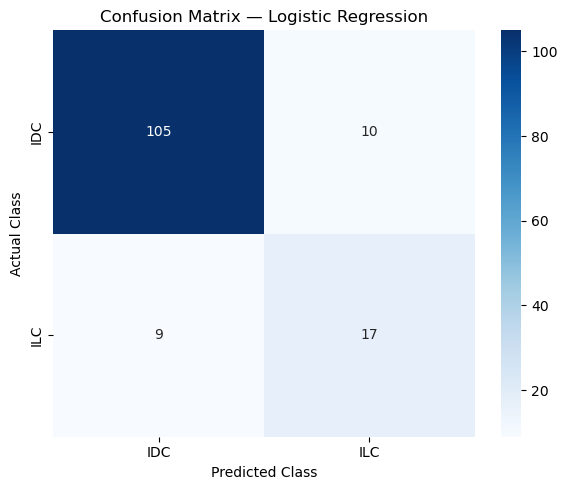


Random Forest
--------------------------------------------------
Rows = Actual
Columns = Predicted
Class 0 = IDC
Class 1 = ILC

[[114   1]
 [ 15  11]]


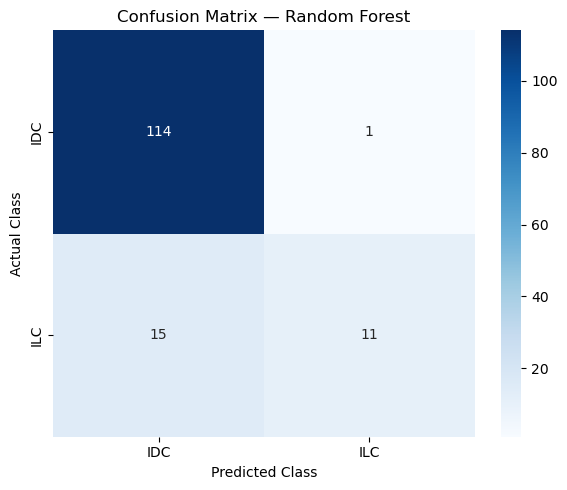


XGBoost
--------------------------------------------------
Rows = Actual
Columns = Predicted
Class 0 = IDC
Class 1 = ILC

[[112   3]
 [  8  18]]


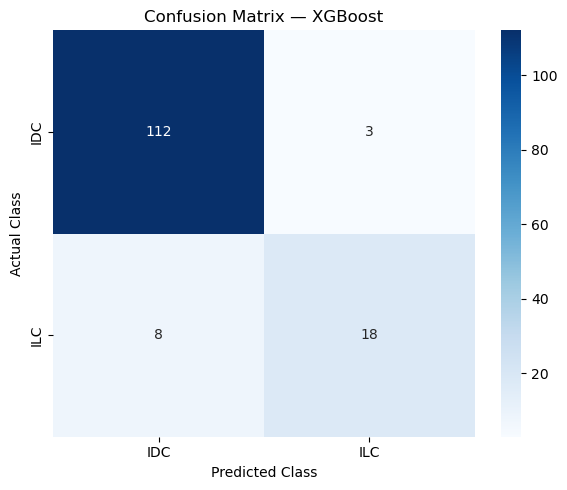


CONFUSION MATRIX ANALYSIS COMPLETED


In [50]:
# ============================================================
# CELL 34 — CONFUSION MATRICES ON INDEPENDENT TEST SET
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("CONFUSION MATRICES — INDEPENDENT TEST SET")
print("=" * 70)

confusion_matrices = {}

for model_name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test_binary,
        y_pred
    )

    confusion_matrices[model_name] = cm

    print(f"\n{model_name}")
    print("-" * 50)

    print("Rows = Actual")
    print("Columns = Predicted")
    print("Class 0 = IDC")
    print("Class 1 = ILC\n")

    print(cm)

    # Visualization
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["IDC", "ILC"],
        yticklabels=["IDC", "ILC"]
    )

    plt.title(
        f"Confusion Matrix — {model_name}"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)
print("CONFUSION MATRIX ANALYSIS COMPLETED")
print("=" * 70)

ROC CURVES — INDEPENDENT TEST SET


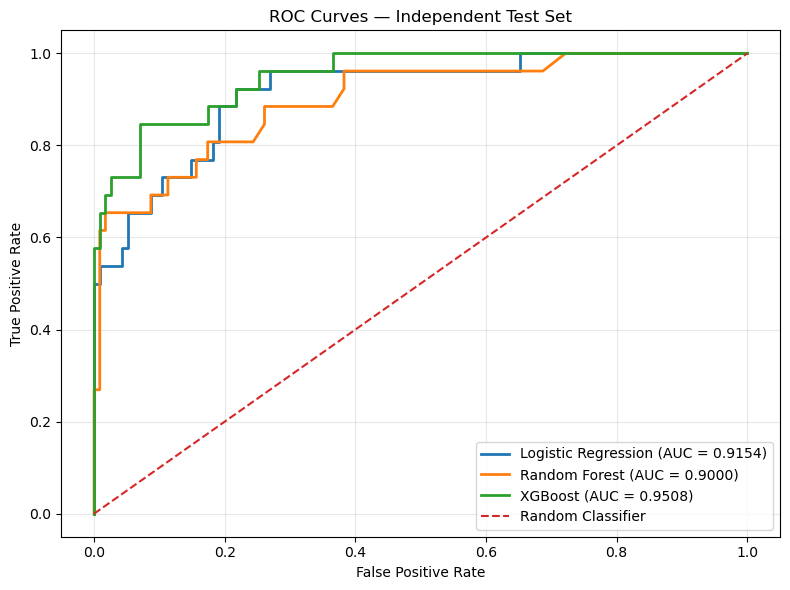


ROC curve analysis completed.


In [51]:
# ============================================================
# CELL 35 — ROC CURVES — INDEPENDENT TEST SET
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

print("=" * 70)
print("ROC CURVES — INDEPENDENT TEST SET")
print("=" * 70)

plt.figure(figsize=(8, 6))

for model_name, model in models.items():

    # Probability of ILC (class 1)
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y_test_binary,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test_binary,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_score:.4f})"
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Independent Test Set")

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nROC curve analysis completed.")

PRECISION–RECALL CURVES — INDEPENDENT TEST SET


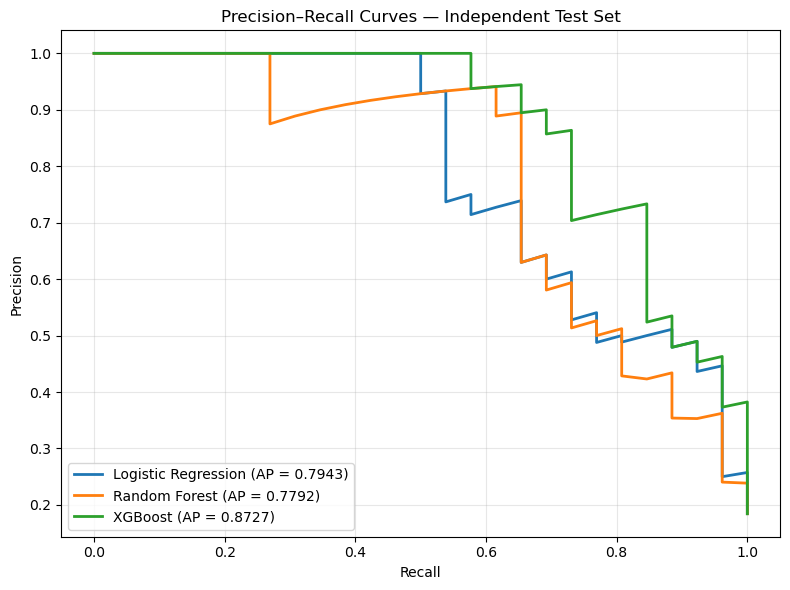


Precision–Recall curve analysis completed.


In [52]:
# ============================================================
# CELL 36 — PRECISION–RECALL CURVES
# ============================================================

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

print("=" * 70)
print("PRECISION–RECALL CURVES — INDEPENDENT TEST SET")
print("=" * 70)

plt.figure(figsize=(8, 6))

for model_name, model in models.items():

    # Probability of ILC (class 1)
    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(
        y_test_binary,
        y_prob
    )

    average_precision = average_precision_score(
        y_test_binary,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (AP = {average_precision:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — Independent Test Set")

plt.legend(
    loc="lower left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPrecision–Recall curve analysis completed.")

XGBOOST FEATURE IMPORTANCE

Top 20 XGBoost features:



,Feature,Importance
0,pp_E.Cadherin,0.048609
1,pp_p53,0.042430
2,rs_TMEM132C,0.037522
3,pp_cIAP,0.035631
4,rs_SCGB1D2,0.033756
5,rs_C16orf89,0.030460
6,pp_Bcl.xL,0.029687
7,pp_AR,0.028620
8,cn_CNTN4,0.026316
9,rs_IL33,0.026156


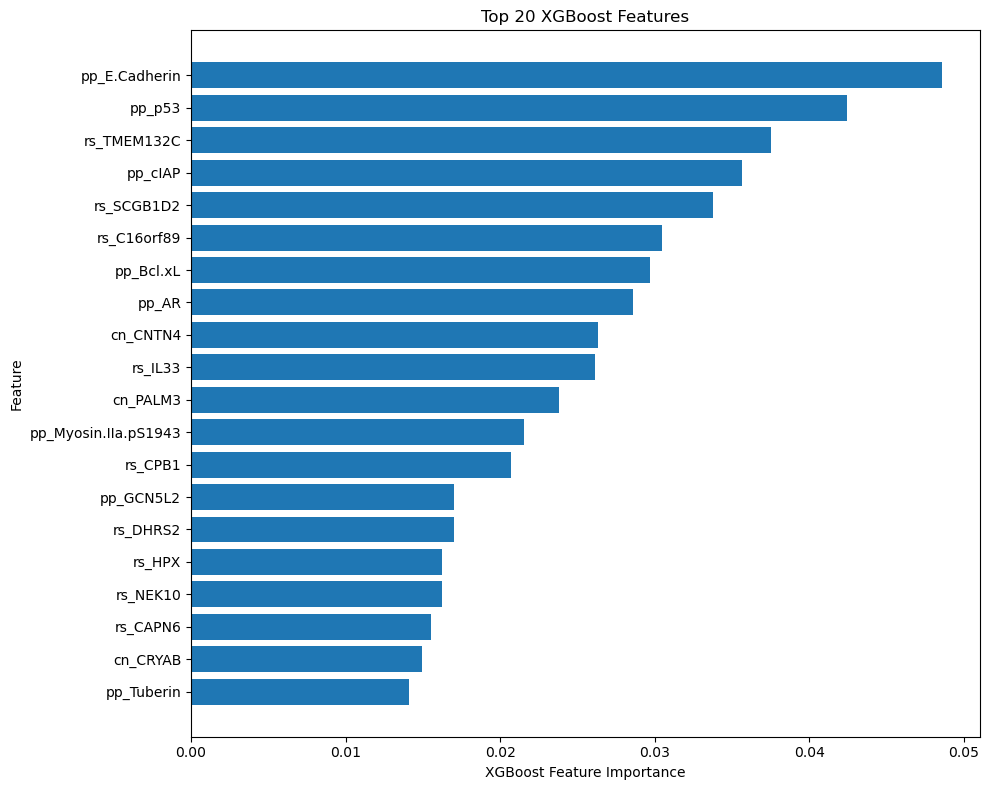


XGBoost feature importance analysis completed.


In [53]:
# ============================================================
# CELL 37 — XGBOOST FEATURE IMPORTANCE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("XGBOOST FEATURE IMPORTANCE")
print("=" * 70)

# ------------------------------------------------------------
# Extract the trained XGBoost estimator
# ------------------------------------------------------------

xgb_estimator = xgboost_pipeline[-1]

# Feature importance
importance_values = xgb_estimator.feature_importances_

# ------------------------------------------------------------
# Recover feature names from the pipeline
# ------------------------------------------------------------

try:
    feature_names = xgboost_pipeline[:-1].get_feature_names_out()

except Exception:
    feature_names = np.array([
        f"Feature_{i}"
        for i in range(len(importance_values))
    ])

# Safety check
if len(feature_names) != len(importance_values):
    feature_names = np.array([
        f"Feature_{i}"
        for i in range(len(importance_values))
    ])

# ------------------------------------------------------------
# Create importance dataframe
# ------------------------------------------------------------

xgb_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

xgb_importance_df = (
    xgb_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nTop 20 XGBoost features:\n")

display(
    xgb_importance_df.head(20)
)

# ------------------------------------------------------------
# Plot top 20 features
# ------------------------------------------------------------

top_n = 20

plot_df = (
    xgb_importance_df
    .head(top_n)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["Feature"],
    plot_df["Importance"]
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features")

plt.tight_layout()
plt.show()

print("\nXGBoost feature importance analysis completed.")

In [54]:
# ============================================================
# CELL 38 — SHAP EXPLAINABILITY FOR XGBOOST
# ============================================================

print("=" * 70)
print("SHAP EXPLAINABILITY — XGBOOST")
print("=" * 70)

import shap

print("SHAP version:", shap.__version__)

# ------------------------------------------------------------
# Extract transformed test data from the pipeline
# ------------------------------------------------------------

print("\nPreparing test data for SHAP analysis...")

xgb_preprocessor = xgboost_pipeline[:-1]

X_test_transformed = xgb_preprocessor.transform(X_test)

print(
    "Transformed test-set shape:",
    X_test_transformed.shape
)

# ------------------------------------------------------------
# Recover feature names
# ------------------------------------------------------------

try:
    shap_feature_names = (
        xgb_preprocessor
        .get_feature_names_out()
    )

except Exception:
    shap_feature_names = np.array([
        f"Feature_{i}"
        for i in range(X_test_transformed.shape[1])
    ])

# ------------------------------------------------------------
# Create SHAP Tree Explainer
# ------------------------------------------------------------

print("\nCreating SHAP TreeExplainer...")

xgb_estimator = xgboost_pipeline[-1]

explainer = shap.TreeExplainer(
    xgb_estimator
)

print("SHAP TreeExplainer created successfully.")

# ------------------------------------------------------------
# Calculate SHAP values
# ------------------------------------------------------------

print("\nCalculating SHAP values...")

shap_values = explainer.shap_values(
    X_test_transformed
)

print("SHAP values calculated successfully.")

print(
    "SHAP value shape:",
    np.array(shap_values).shape
)

print("\n" + "=" * 70)
print("SHAP ANALYSIS PREPARATION COMPLETED")
print("=" * 70)

SHAP EXPLAINABILITY — XGBOOST
SHAP version: 0.52.0

Preparing test data for SHAP analysis...
Transformed test-set shape: (141, 1936)

Creating SHAP TreeExplainer...
SHAP TreeExplainer created successfully.

Calculating SHAP values...
SHAP values calculated successfully.
SHAP value shape: (141, 1936)

SHAP ANALYSIS PREPARATION COMPLETED


SHAP SUMMARY ANALYSIS — XGBOOST

Top 20 features by mean absolute SHAP value:



,Feature,Mean_Absolute_SHAP
0,pp_E.Cadherin,3.037549
1,rs_HPX,0.352985
2,mu_CDH1,0.338636
3,pp_AR,0.324553
4,pp_c.Myc,0.316739
5,rs_LOC100271831,0.306407
6,rs_TMEM132C,0.303161
7,rs_PLCH1,0.298012
8,rs_DLX2,0.262967
9,rs_TMPRSS3,0.249408



Generating SHAP summary plot...


C:\Users\Admin\AppData\Local\Temp\ipykernel_20516\4078449145.py:68: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


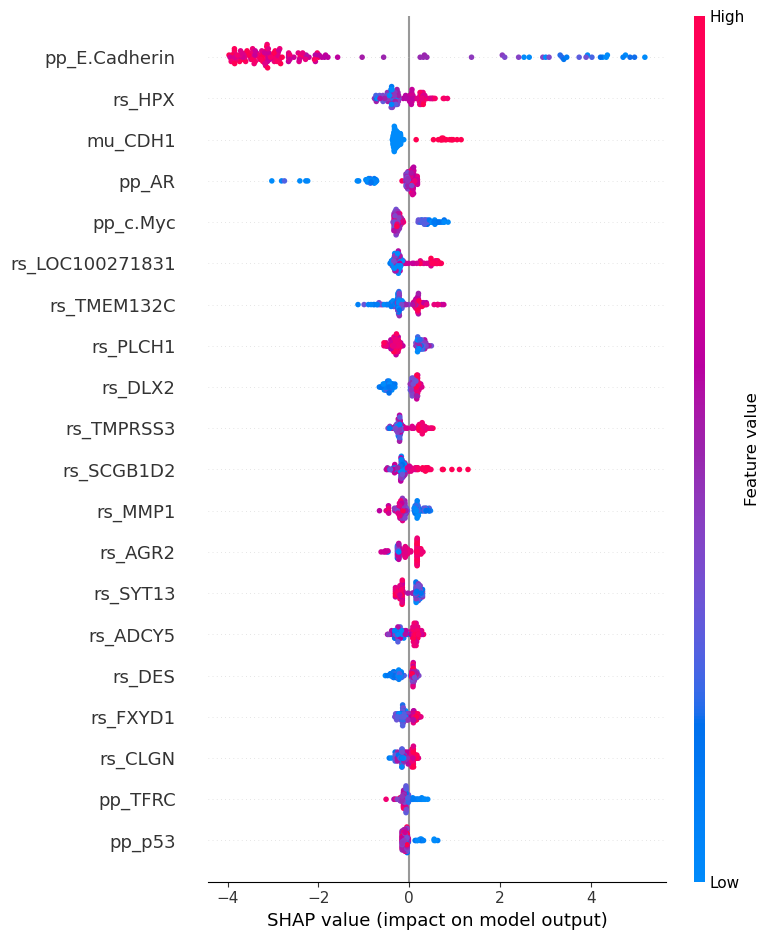


SHAP summary analysis completed.


In [55]:
# ============================================================
# CELL 39 — SHAP SUMMARY ANALYSIS
# ============================================================

print("=" * 70)
print("SHAP SUMMARY ANALYSIS — XGBOOST")
print("=" * 70)

# ------------------------------------------------------------
# Convert SHAP values to a clean NumPy array
# ------------------------------------------------------------

shap_values_array = np.asarray(shap_values)

# ------------------------------------------------------------
# Safety check
# ------------------------------------------------------------

if shap_values_array.ndim != 2:
    raise ValueError(
        f"Unexpected SHAP dimensions: {shap_values_array.shape}"
    )

if shap_values_array.shape[1] != X_test_transformed.shape[1]:
    raise ValueError(
        "SHAP feature dimension does not match transformed data."
    )

# ------------------------------------------------------------
# Global mean absolute SHAP importance
# ------------------------------------------------------------

mean_abs_shap = np.mean(
    np.abs(shap_values_array),
    axis=0
)

shap_importance_df = pd.DataFrame({
    "Feature": shap_feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance_df = (
    shap_importance_df
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display top 20 SHAP features
# ------------------------------------------------------------

print("\nTop 20 features by mean absolute SHAP value:\n")

display(
    shap_importance_df.head(20)
)

# ------------------------------------------------------------
# SHAP summary / beeswarm plot
# ------------------------------------------------------------

print("\nGenerating SHAP summary plot...")

shap.summary_plot(
    shap_values_array,
    X_test_transformed,
    feature_names=shap_feature_names,
    max_display=20,
    show=True
)

print("\nSHAP summary analysis completed.")

COMPREHENSIVE MODEL COMPARISON — INDEPENDENT TEST SET

Independent test-set comparison:



,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8652,0.6296,0.6538,0.6415,0.9154
1,Random Forest,0.8865,0.9167,0.4231,0.5789,0.9000
2,XGBoost,0.9220,0.8571,0.6923,0.7660,0.9508


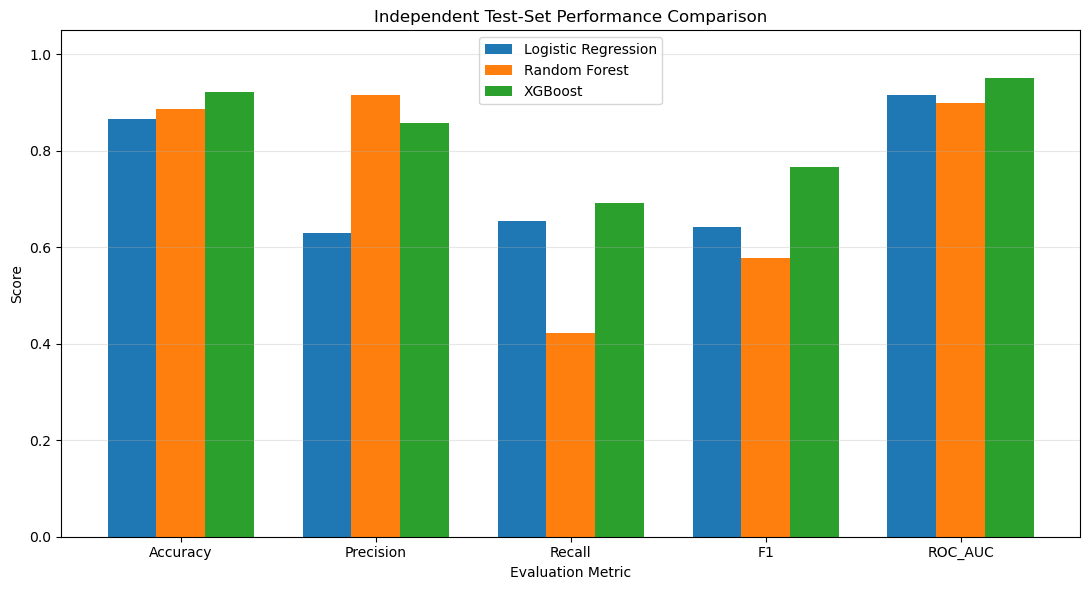


Best-performing model for each metric:
Accuracy    : XGBoost (0.9220)
Precision   : Random Forest (0.9167)
Recall      : XGBoost (0.6923)
F1          : XGBoost (0.7660)
ROC_AUC     : XGBoost (0.9508)

MODEL COMPARISON COMPLETED


In [56]:
# ============================================================
# CELL 40 — COMPREHENSIVE MODEL COMPARISON
# ============================================================

print("=" * 70)
print("COMPREHENSIVE MODEL COMPARISON — INDEPENDENT TEST SET")
print("=" * 70)

# ------------------------------------------------------------
# Create comparison dataframe from actual test results
# ------------------------------------------------------------

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.8652,
        0.8865,
        0.9220
    ],
    "Precision": [
        0.6296,
        0.9167,
        0.8571
    ],
    "Recall": [
        0.6538,
        0.4231,
        0.6923
    ],
    "F1": [
        0.6415,
        0.5789,
        0.7660
    ],
    "ROC_AUC": [
        0.9154,
        0.9000,
        0.9508
    ]
})

print("\nIndependent test-set comparison:\n")

display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    })
)

# ------------------------------------------------------------
# Plot comparison
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(11, 6))

for i, model_name in enumerate(comparison_df["Model"]):

    values = comparison_df.loc[
        i,
        metrics
    ].values.astype(float)

    plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=model_name
    )

plt.xticks(
    x,
    metrics
)

plt.ylabel("Score")
plt.xlabel("Evaluation Metric")

plt.title(
    "Independent Test-Set Performance Comparison"
)

plt.ylim(0, 1.05)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Identify best model for each metric
# ------------------------------------------------------------

print("\nBest-performing model for each metric:")

for metric in metrics:

    best_idx = comparison_df[metric].idxmax()

    best_model = comparison_df.loc[
        best_idx,
        "Model"
    ]

    best_score = comparison_df.loc[
        best_idx,
        metric
    ]

    print(
        f"{metric:<12}: "
        f"{best_model} ({best_score:.4f})"
    )

print("\n" + "=" * 70)
print("MODEL COMPARISON COMPLETED")
print("=" * 70)

In [57]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 1
# REPRODUCIBILITY & ENVIRONMENT CONFIGURATION
# ============================================================

import sys
import os
import platform
import random

import numpy as np

# ------------------------------------------------------------
# Global random seed
# ------------------------------------------------------------

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ------------------------------------------------------------
# Environment information
# ------------------------------------------------------------

print("=" * 70)
print("FINAL RESEARCH IMPLEMENTATION")
print("=" * 70)

print("\nPython executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nOperating system:")
print(platform.platform())

print("\nNumPy version:")
print(np.__version__)

print("\nRandom state:")
print(RANDOM_STATE)

print("\nReproducibility configuration initialized.")

print("=" * 70)

FINAL RESEARCH IMPLEMENTATION

Python executable:
C:\ProgramData\anaconda3\python.exe

Python version:
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]

Operating system:
Windows-11-10.0.26200-SP0

NumPy version:
2.3.5

Random state:
42

Reproducibility configuration initialized.


In [58]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 2
# CORE LIBRARY IMPORTS
# ============================================================

import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from IPython.display import display

# ------------------------------------------------------------
# Warning configuration
# ------------------------------------------------------------

warnings.filterwarnings(
    "ignore",
    category=FutureWarning
)

# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    160
)

pd.set_option(
    "display.max_rows",
    100
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("=" * 70)
print("CORE LIBRARIES IMPORTED")
print("=" * 70)

print("\nPandas version :", pd.__version__)
print("NumPy version  :", np.__version__)

print("\nCore libraries imported successfully.")

print("=" * 70)

CORE LIBRARIES IMPORTED

Pandas version : 2.3.3
NumPy version  : 2.3.5

Core libraries imported successfully.


In [59]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 3
# DATASET PATH & LOADING
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# Dataset path
# ------------------------------------------------------------

DATASET_PATH = Path(
    r"C:\Users\Admin\Desktop\brca_research\brca_data_w_subtypes.csv"
)

print("=" * 70)
print("DATASET LOADING")
print("=" * 70)

# ------------------------------------------------------------
# Verify dataset exists
# ------------------------------------------------------------

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{DATASET_PATH}"
    )

print("\nDataset located successfully.")
print("Dataset path:")
print(DATASET_PATH)

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

df = pd.read_csv(DATASET_PATH)

# ------------------------------------------------------------
# Basic verification
# ------------------------------------------------------------

print("\nDataset loaded successfully.")

print("\nRows    :", df.shape[0])
print("Columns :", df.shape[1])

print("\nDataset object created:")
print("df →", type(df).__name__)

print("=" * 70)

DATASET LOADING

Dataset located successfully.
Dataset path:
C:\Users\Admin\Desktop\brca_research\brca_data_w_subtypes.csv

Dataset loaded successfully.

Rows    : 705
Columns : 1941

Dataset object created:
df → DataFrame


In [60]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 4
# DATASET STRUCTURE & DATA-TYPE AUDIT
# ============================================================

print("=" * 70)
print("DATASET STRUCTURE & DATA-TYPE AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# Dataset dimensions
# ------------------------------------------------------------

print("\nDataset shape:")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# ------------------------------------------------------------
# Data type distribution
# ------------------------------------------------------------

print("\nData type distribution:")
print(
    df.dtypes
    .value_counts()
)

# ------------------------------------------------------------
# Missing-value analysis
# ------------------------------------------------------------

missing_total = int(
    df.isna().sum().sum()
)

missing_columns = int(
    (df.isna().sum() > 0).sum()
)

print("\nMissing-value summary:")
print(
    f"Total missing cells       : {missing_total}"
)
print(
    f"Columns with missing data : {missing_columns}"
)

# ------------------------------------------------------------
# Duplicate-row analysis
# ------------------------------------------------------------

duplicate_rows = int(
    df.duplicated().sum()
)

print("\nDuplicate-row summary:")
print(
    f"Duplicate rows: {duplicate_rows}"
)

# ------------------------------------------------------------
# First and last column names
# ------------------------------------------------------------

print("\nFirst 20 column names:")
print(
    df.columns[:20].tolist()
)

print("\nLast 20 column names:")
print(
    df.columns[-20:].tolist()
)

print("\n" + "=" * 70)
print("DATASET AUDIT COMPLETED")
print("=" * 70)

DATASET STRUCTURE & DATA-TYPE AUDIT

Dataset shape:
Rows    : 705
Columns : 1941

Data type distribution:
int64      1110
float64     827
object        4
Name: count, dtype: int64

Missing-value summary:
Total missing cells       : 389
Columns with missing data : 3

Duplicate-row summary:
Duplicate rows: 0

First 20 column names:
['rs_CLEC3A', 'rs_CPB1', 'rs_SCGB2A2', 'rs_SCGB1D2', 'rs_TFF1', 'rs_MUCL1', 'rs_GSTM1', 'rs_PIP', 'rs_ADIPOQ', 'rs_ADH1B', 'rs_S100A7', 'rs_HMGCS2', 'rs_CYP2B7P1', 'rs_ANKRD30A', 'rs_PRAME', 'rs_TAT', 'rs_SERPINA6', 'rs_AGR3', 'rs_TFAP2B', 'rs_CYP4Z1']

Last 20 column names:
['pp_mTOR', 'pp_mTOR.pS2448', 'pp_p16.INK4a', 'pp_p21', 'pp_p27', 'pp_p27.pT157', 'pp_p27.pT198', 'pp_p38.MAPK', 'pp_p38.pT180.Y182', 'pp_p53', 'pp_p62.LCK.ligand', 'pp_p70S6K', 'pp_p70S6K.pT389', 'pp_p90RSK', 'pp_p90RSK.pT359.S363', 'vital.status', 'PR.Status', 'ER.Status', 'HER2.Final.Status', 'histological.type']

DATASET AUDIT COMPLETED


In [61]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 5
# TARGET & METADATA AUDIT
# ============================================================

TARGET_COLUMN = "histological.type"

METADATA_COLUMNS = [
    "PR.Status",
    "ER.Status",
    "HER2.Final.Status",
    "vital.status"
]

print("=" * 70)
print("TARGET AND METADATA AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# Verify target exists
# ------------------------------------------------------------

if TARGET_COLUMN not in df.columns:
    raise KeyError(
        f"Target column '{TARGET_COLUMN}' not found."
    )

print(f"\nTarget column: {TARGET_COLUMN}")

# ------------------------------------------------------------
# Identify object columns
# ------------------------------------------------------------

object_columns = df.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nObject-type columns:")

for column in object_columns:
    print(f"  - {column}")

# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

print("\nTarget value counts:")

target_counts = df[TARGET_COLUMN].value_counts(
    dropna=False
)

print(target_counts)

# ------------------------------------------------------------
# Target proportions
# ------------------------------------------------------------

print("\nTarget proportions:")

target_proportions = df[TARGET_COLUMN].value_counts(
    normalize=True,
    dropna=False
)

print(target_proportions)

# ------------------------------------------------------------
# Missing values in object columns
# ------------------------------------------------------------

print("\nMissing values in object columns:")

for column in object_columns:

    missing = int(df[column].isna().sum())

    print(
        f"  {column}: {missing}"
    )

# ------------------------------------------------------------
# Unique values in object columns
# ------------------------------------------------------------

print("\nUnique values in object columns:")

for column in object_columns:

    print(f"\n{column}:")

    print(
        df[column].value_counts(
            dropna=False
        )
    )

# ------------------------------------------------------------
# Target validation
# ------------------------------------------------------------

expected_classes = {
    "infiltrating ductal carcinoma",
    "infiltrating lobular carcinoma"
}

observed_classes = set(
    df[TARGET_COLUMN].dropna().unique()
)

if observed_classes != expected_classes:
    raise ValueError(
        "Unexpected target classes detected.\n"
        f"Observed: {observed_classes}\n"
        f"Expected: {expected_classes}"
    )

print("\nTarget validation: PASSED")
print("IDC and ILC are the only target classes.")

print("\n" + "=" * 70)
print("TARGET AND METADATA AUDIT COMPLETED")
print("=" * 70)

TARGET AND METADATA AUDIT

Target column: histological.type

Object-type columns:
  - PR.Status
  - ER.Status
  - HER2.Final.Status
  - histological.type

Target value counts:
histological.type
infiltrating ductal carcinoma     574
infiltrating lobular carcinoma    131
Name: count, dtype: int64

Target proportions:
histological.type
infiltrating ductal carcinoma     0.814184
infiltrating lobular carcinoma    0.185816
Name: proportion, dtype: float64

Missing values in object columns:
  PR.Status: 122
  ER.Status: 122
  HER2.Final.Status: 145
  histological.type: 0

Unique values in object columns:

PR.Status:
PR.Status
Positive                       353
Negative                       193
NaN                            122
Not Performed                   28
Performed but Not Available      5
Indeterminate                    4
Name: count, dtype: int64

ER.Status:
ER.Status
Positive                       414
Negative                       135
NaN                            122
Not Perfor

In [62]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 6
# BINARY TARGET ENCODING
# ============================================================

print("=" * 70)
print("BINARY TARGET ENCODING")
print("=" * 70)

# ------------------------------------------------------------
# Target mapping
# ------------------------------------------------------------

TARGET_MAPPING = {
    "infiltrating ductal carcinoma": 0,
    "infiltrating lobular carcinoma": 1
}

# ------------------------------------------------------------
# Create binary target
# ------------------------------------------------------------

y = df[TARGET_COLUMN].map(TARGET_MAPPING)

# ------------------------------------------------------------
# Validate encoding
# ------------------------------------------------------------

if y.isna().any():
    raise ValueError(
        "Target encoding produced missing values."
    )

if not set(y.unique()).issubset({0, 1}):
    raise ValueError(
        "Unexpected binary target values detected."
    )

# ------------------------------------------------------------
# Target distribution
# ------------------------------------------------------------

print("\nTarget mapping:")
print("  IDC → 0")
print("  ILC → 1")

print("\nBinary target distribution:")
print(y.value_counts().sort_index())

print("\nBinary target proportions:")
print(
    y.value_counts(
        normalize=True
    ).sort_index()
)

# ------------------------------------------------------------
# Store target name
# ------------------------------------------------------------

Y = y.astype(int)

print("\nTarget dtype:")
print(Y.dtype)

print("\nTarget encoding validation: PASSED")

print("\n" + "=" * 70)
print("BINARY TARGET ENCODING COMPLETED")
print("=" * 70)

BINARY TARGET ENCODING

Target mapping:
  IDC → 0
  ILC → 1

Binary target distribution:
histological.type
0    574
1    131
Name: count, dtype: int64

Binary target proportions:
histological.type
0    0.814184
1    0.185816
Name: proportion, dtype: float64

Target dtype:
int64

Target encoding validation: PASSED

BINARY TARGET ENCODING COMPLETED


In [63]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 7
# FEATURE MATRIX & LEAKAGE PREVENTION
# ============================================================

print("=" * 70)
print("FEATURE MATRIX CONSTRUCTION & LEAKAGE PREVENTION")
print("=" * 70)

# ------------------------------------------------------------
# Columns that must NOT be used as predictors
# ------------------------------------------------------------

EXCLUDED_COLUMNS = [
    TARGET_COLUMN,
    "PR.Status",
    "ER.Status",
    "HER2.Final.Status",
    "vital.status"
]

print("\nExcluded columns:")

for column in EXCLUDED_COLUMNS:
    print(f"  - {column}")

# ------------------------------------------------------------
# Verify excluded columns exist
# ------------------------------------------------------------

missing_excluded = [
    column
    for column in EXCLUDED_COLUMNS
    if column not in df.columns
]

if missing_excluded:
    raise KeyError(
        f"Expected excluded columns not found: {missing_excluded}"
    )

# ------------------------------------------------------------
# Construct feature matrix
# ------------------------------------------------------------

X = df.drop(
    columns=EXCLUDED_COLUMNS
).copy()

# ------------------------------------------------------------
# Keep numeric predictors only
# ------------------------------------------------------------

non_numeric_features = X.select_dtypes(
    exclude=[np.number]
).columns.tolist()

if non_numeric_features:
    print("\nRemoving non-numeric predictor columns:")
    for column in non_numeric_features:
        print(f"  - {column}")

    X = X.select_dtypes(
        include=[np.number]
    ).copy()

# ------------------------------------------------------------
# Leakage verification
# ------------------------------------------------------------

leakage_columns = set(
    EXCLUDED_COLUMNS
).intersection(
    set(X.columns)
)

if leakage_columns:
    raise ValueError(
        f"Potential leakage detected: {leakage_columns}"
    )

# ------------------------------------------------------------
# Feature matrix summary
# ------------------------------------------------------------

print("\nFeature matrix shape:")
print(
    f"Rows    : {X.shape[0]}"
)
print(
    f"Features : {X.shape[1]}"
)

print("\nTarget shape:")
print(
    f"Rows    : {Y.shape[0]}"
)

# ------------------------------------------------------------
# Missing values in predictors
# ------------------------------------------------------------

missing_feature_cells = int(
    X.isna().sum().sum()
)

missing_feature_columns = int(
    (X.isna().sum() > 0).sum()
)

print("\nFeature missing-value summary:")
print(
    f"Missing cells       : {missing_feature_cells}"
)
print(
    f"Columns with missing: {missing_feature_columns}"
)

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

if len(X) != len(Y):
    raise ValueError(
        "Feature matrix and target have different numbers of rows."
    )

print("\nLeakage verification: PASSED")
print("Target and clinical metadata are excluded from predictors.")

print("\n" + "=" * 70)
print("FEATURE MATRIX CONSTRUCTION COMPLETED")
print("=" * 70)

FEATURE MATRIX CONSTRUCTION & LEAKAGE PREVENTION

Excluded columns:
  - histological.type
  - PR.Status
  - ER.Status
  - HER2.Final.Status
  - vital.status

Feature matrix shape:
Rows    : 705
Features : 1936

Target shape:
Rows    : 705

Feature missing-value summary:
Missing cells       : 0
Columns with missing: 0

Leakage verification: PASSED
Target and clinical metadata are excluded from predictors.

FEATURE MATRIX CONSTRUCTION COMPLETED


TARGET CLASS DISTRIBUTION

Class distribution:
IDC (0): 574 samples (81.42%)
ILC (1): 131 samples (18.58%)


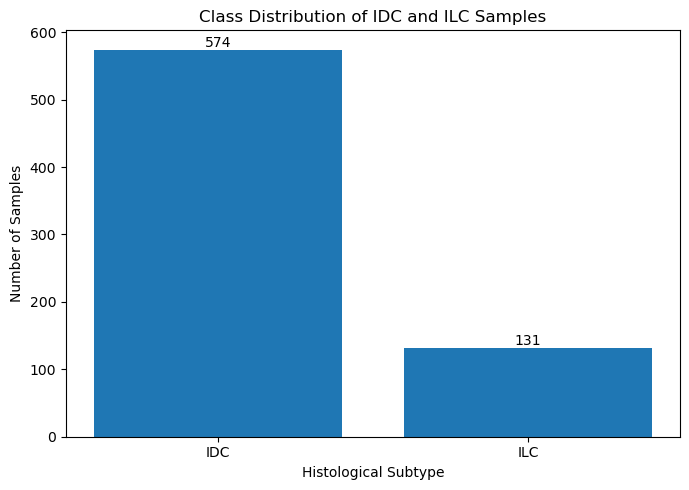


Class distribution visualization completed.


In [64]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 8
# TARGET CLASS DISTRIBUTION
# ============================================================

print("=" * 70)
print("TARGET CLASS DISTRIBUTION")
print("=" * 70)

# ------------------------------------------------------------
# Class counts
# ------------------------------------------------------------

class_counts = Y.value_counts().sort_index()

class_labels = {
    0: "IDC",
    1: "ILC"
}

print("\nClass distribution:")

for class_id, count in class_counts.items():

    percentage = (
        count / len(Y)
    ) * 100

    print(
        f"{class_labels[class_id]} ({class_id}): "
        f"{count} samples "
        f"({percentage:.2f}%)"
    )

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["IDC", "ILC"],
    [
        class_counts.get(0, 0),
        class_counts.get(1, 0)
    ]
)

plt.title(
    "Class Distribution of IDC and ILC Samples"
)

plt.xlabel("Histological Subtype")
plt.ylabel("Number of Samples")

# Add values above bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

print("\nClass distribution visualization completed.")

print("=" * 70)

In [65]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 9
# STRATIFIED TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 70)
print("STRATIFIED TRAIN / TEST SPLIT")
print("=" * 70)

TEST_SIZE = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=Y
)

# ------------------------------------------------------------
# Reset indices
# ------------------------------------------------------------

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# ------------------------------------------------------------
# Binary target aliases
# ------------------------------------------------------------

y_train_binary = y_train
y_test_binary = y_test

# ------------------------------------------------------------
# Basic dimensions
# ------------------------------------------------------------

print("\nTraining set:")
print(f"  Samples  : {X_train.shape[0]}")
print(f"  Features : {X_train.shape[1]}")

print("\nIndependent test set:")
print(f"  Samples  : {X_test.shape[0]}")
print(f"  Features : {X_test.shape[1]}")

# ------------------------------------------------------------
# Class distributions
# ------------------------------------------------------------

print("\nTraining-set class distribution:")
print(y_train.value_counts().sort_index())

print("\nTest-set class distribution:")
print(y_test.value_counts().sort_index())

# ------------------------------------------------------------
# Proportions
# ------------------------------------------------------------

print("\nTraining-set class proportions:")
print(
    y_train.value_counts(normalize=True).sort_index()
)

print("\nTest-set class proportions:")
print(
    y_test.value_counts(normalize=True).sort_index()
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(X_train) + len(X_test) != len(X):
    raise ValueError(
        "Train/test sample counts do not match original dataset."
    )

if X_train.shape[1] != X_test.shape[1]:
    raise ValueError(
        "Train and test feature dimensions do not match."
    )

print("\nStratification validation: PASSED")

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT COMPLETED")
print("=" * 70)

STRATIFIED TRAIN / TEST SPLIT

Training set:
  Samples  : 564
  Features : 1936

Independent test set:
  Samples  : 141
  Features : 1936

Training-set class distribution:
histological.type
0    459
1    105
Name: count, dtype: int64

Test-set class distribution:
histological.type
0    115
1     26
Name: count, dtype: int64

Training-set class proportions:
histological.type
0    0.81383
1    0.18617
Name: proportion, dtype: float64

Test-set class proportions:
histological.type
0    0.815603
1    0.184397
Name: proportion, dtype: float64

Stratification validation: PASSED

TRAIN / TEST SPLIT COMPLETED


In [66]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 10
# TRAIN / TEST INTEGRITY VERIFICATION
# CORRECTED VERSION
# ============================================================

print("=" * 70)
print("TRAIN / TEST INTEGRITY VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Sample counts
# ------------------------------------------------------------

print("\nSample counts:")
print(f"Original dataset : {len(X)}")
print(f"Training set     : {len(X_train)}")
print(f"Test set         : {len(X_test)}")

# ------------------------------------------------------------
# Feature dimensions
# ------------------------------------------------------------

print("\nFeature dimensions:")
print(f"Training features : {X_train.shape[1]}")
print(f"Test features     : {X_test.shape[1]}")

# ------------------------------------------------------------
# Target alignment
# ------------------------------------------------------------

print("\nTarget alignment:")
print(
    f"Training X/y rows: "
    f"{len(X_train)} / {len(y_train)}"
)

print(
    f"Test X/y rows    : "
    f"{len(X_test)} / {len(y_test)}"
)

# ------------------------------------------------------------
# Duplicate rows inside each split
# ------------------------------------------------------------

train_duplicates = int(
    X_train.duplicated().sum()
)

test_duplicates = int(
    X_test.duplicated().sum()
)

print("\nDuplicate rows within splits:")
print(
    f"Training duplicates: {train_duplicates}"
)
print(
    f"Test duplicates    : {test_duplicates}"
)

# ------------------------------------------------------------
# Cross-split duplicate verification
# ------------------------------------------------------------

# Convert rows to tuples so we can compare
# actual feature values rather than reset indices.

train_row_set = set(
    map(tuple, X_train.to_numpy())
)

test_row_set = set(
    map(tuple, X_test.to_numpy())
)

cross_split_overlap = (
    train_row_set.intersection(test_row_set)
)

print("\nCross-split sample verification:")
print(
    f"Identical samples appearing in both splits: "
    f"{len(cross_split_overlap)}"
)

# ------------------------------------------------------------
# Class distributions
# ------------------------------------------------------------

train_distribution = (
    y_train.value_counts(
        normalize=True
    ).sort_index()
)

test_distribution = (
    y_test.value_counts(
        normalize=True
    ).sort_index()
)

print("\nTraining class proportions:")
print(train_distribution)

print("\nTest class proportions:")
print(test_distribution)

# ------------------------------------------------------------
# Formal validation
# ------------------------------------------------------------

if len(X_train) + len(X_test) != len(X):
    raise ValueError(
        "Train/test sample counts do not match original dataset."
    )

if X_train.shape[1] != X_test.shape[1]:
    raise ValueError(
        "Training and test feature counts differ."
    )

if len(X_train) != len(y_train):
    raise ValueError(
        "Training features and target are misaligned."
    )

if len(X_test) != len(y_test):
    raise ValueError(
        "Test features and target are misaligned."
    )

if len(cross_split_overlap) != 0:
    raise ValueError(
        "Identical samples detected in both train and test sets."
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAIN / TEST INTEGRITY: PASSED")
print("=" * 70)

TRAIN / TEST INTEGRITY VERIFICATION

Sample counts:
Original dataset : 705
Training set     : 564
Test set         : 141

Feature dimensions:
Training features : 1936
Test features     : 1936

Target alignment:
Training X/y rows: 564 / 564
Test X/y rows    : 141 / 141

Duplicate rows within splits:
Training duplicates: 0
Test duplicates    : 0

Cross-split sample verification:
Identical samples appearing in both splits: 0

Training class proportions:
histological.type
0    0.81383
1    0.18617
Name: proportion, dtype: float64

Test class proportions:
histological.type
0    0.815603
1    0.184397
Name: proportion, dtype: float64

TRAIN / TEST INTEGRITY: PASSED


In [67]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 11
# ZERO-VARIANCE FEATURE ANALYSIS
# ============================================================

print("=" * 70)
print("ZERO-VARIANCE FEATURE ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Calculate variance using TRAINING DATA ONLY
# ------------------------------------------------------------

feature_variances = X_train.var(
    axis=0,
    numeric_only=True
)

# ------------------------------------------------------------
# Identify zero-variance features
# ------------------------------------------------------------

zero_variance_features = feature_variances[
    feature_variances == 0
].index.tolist()

# ------------------------------------------------------------
# Identify near-zero variance features
# ------------------------------------------------------------

near_zero_variance_features = feature_variances[
    feature_variances < 1e-12
].index.tolist()

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("\nTotal features:")
print(f"  {X_train.shape[1]}")

print("\nZero-variance features:")
print(f"  {len(zero_variance_features)}")

print("\nNear-zero-variance features (< 1e-12):")
print(f"  {len(near_zero_variance_features)}")

# ------------------------------------------------------------
# Display zero-variance feature names
# ------------------------------------------------------------

if zero_variance_features:

    print("\nZero-variance feature names:")

    for feature in zero_variance_features:
        print(f"  - {feature}")

else:

    print("\nNo zero-variance features detected.")

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(zero_variance_features) == 0:

    print("\nVariance check: PASSED")
    print("All training features contain non-zero variance.")

else:

    print("\nVariance check: FEATURES IDENTIFIED")
    print(
        "These features will be removed before model training."
    )

print("\n" + "=" * 70)
print("ZERO-VARIANCE FEATURE ANALYSIS COMPLETED")
print("=" * 70)

ZERO-VARIANCE FEATURE ANALYSIS

Total features:
  1936

Zero-variance features:
  0

Near-zero-variance features (< 1e-12):
  0

No zero-variance features detected.

Variance check: PASSED
All training features contain non-zero variance.

ZERO-VARIANCE FEATURE ANALYSIS COMPLETED


In [68]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 12
# FEATURE SCALING PREPROCESSOR
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

print("=" * 70)
print("FEATURE SCALING PREPROCESSOR")
print("=" * 70)

# ------------------------------------------------------------
# Create scaler
# ------------------------------------------------------------

scaler = StandardScaler()

# ------------------------------------------------------------
# Fit ONLY on training data
# ------------------------------------------------------------

X_train_scaled = scaler.fit_transform(X_train)

# ------------------------------------------------------------
# Transform test data using training parameters
# ------------------------------------------------------------

X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# Convert back to DataFrames
# ------------------------------------------------------------

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

# ------------------------------------------------------------
# Shape verification
# ------------------------------------------------------------

print("\nScaled training data:")
print(f"Rows     : {X_train_scaled.shape[0]}")
print(f"Features : {X_train_scaled.shape[1]}")

print("\nScaled test data:")
print(f"Rows     : {X_test_scaled.shape[0]}")
print(f"Features : {X_test_scaled.shape[1]}")

# ------------------------------------------------------------
# Numerical verification
# ------------------------------------------------------------

train_means = X_train_scaled.mean()
train_stds = X_train_scaled.std(ddof=0)

max_abs_mean = float(
    np.abs(train_means).max()
)

max_std_difference = float(
    np.abs(train_stds - 1).max()
)

print("\nTraining-set scaling verification:")
print(
    f"Maximum absolute feature mean: "
    f"{max_abs_mean:.10f}"
)

print(
    f"Maximum deviation from unit std: "
    f"{max_std_difference:.10f}"
)

# ------------------------------------------------------------
# Verify no NaN / infinite values
# ------------------------------------------------------------

train_nan_count = int(
    X_train_scaled.isna().sum().sum()
)

test_nan_count = int(
    X_test_scaled.isna().sum().sum()
)

train_inf_count = int(
    np.isinf(X_train_scaled.to_numpy()).sum()
)

test_inf_count = int(
    np.isinf(X_test_scaled.to_numpy()).sum()
)

print("\nScaled-data validity:")
print(f"Training NaN values     : {train_nan_count}")
print(f"Test NaN values         : {test_nan_count}")
print(f"Training infinite values: {train_inf_count}")
print(f"Test infinite values    : {test_inf_count}")

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

if train_nan_count != 0 or test_nan_count != 0:
    raise ValueError(
        "NaN values detected after scaling."
    )

if train_inf_count != 0 or test_inf_count != 0:
    raise ValueError(
        "Infinite values detected after scaling."
    )

if X_train_scaled.shape != X_train.shape:
    raise ValueError(
        "Scaled training shape does not match original."
    )

if X_test_scaled.shape != X_test.shape:
    raise ValueError(
        "Scaled test shape does not match original."
    )

print("\nScaling validation: PASSED")
print(
    "Scaler was fitted on training data only."
)

print("\n" + "=" * 70)
print("FEATURE SCALING COMPLETED")
print("=" * 70)

FEATURE SCALING PREPROCESSOR

Scaled training data:
Rows     : 564
Features : 1936

Scaled test data:
Rows     : 141
Features : 1936

Training-set scaling verification:
Maximum absolute feature mean: 0.0000000000
Maximum deviation from unit std: 0.0000000000

Scaled-data validity:
Training NaN values     : 0
Test NaN values         : 0
Training infinite values: 0
Test infinite values    : 0

Scaling validation: PASSED
Scaler was fitted on training data only.

FEATURE SCALING COMPLETED


In [69]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 13
# SCALING & PREPROCESSING VERIFICATION
# ============================================================

print("=" * 70)
print("SCALING & PREPROCESSING VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Verify training statistics
# ------------------------------------------------------------

train_mean_max = float(
    np.abs(X_train_scaled.mean()).max()
)

train_std_max_error = float(
    np.abs(X_train_scaled.std(ddof=0) - 1).max()
)

print("\nTraining-set scaling statistics:")
print(
    f"Maximum absolute mean : {train_mean_max:.10f}"
)
print(
    f"Maximum std deviation : {train_std_max_error:.10f}"
)

# ------------------------------------------------------------
# Verify test set is transformed but not fitted
# ------------------------------------------------------------

print("\nTest-set transformation:")
print(
    f"Test samples          : {X_test_scaled.shape[0]}"
)
print(
    f"Test features          : {X_test_scaled.shape[1]}"
)

# ------------------------------------------------------------
# Check data validity
# ------------------------------------------------------------

print("\nData validity:")

print(
    f"Training NaN values    : "
    f"{int(X_train_scaled.isna().sum().sum())}"
)

print(
    f"Test NaN values        : "
    f"{int(X_test_scaled.isna().sum().sum())}"
)

print(
    f"Training infinite      : "
    f"{int(np.isinf(X_train_scaled.to_numpy()).sum())}"
)

print(
    f"Test infinite          : "
    f"{int(np.isinf(X_test_scaled.to_numpy()).sum())}"
)

# ------------------------------------------------------------
# Verify dimensions
# ------------------------------------------------------------

if X_train_scaled.shape != X_train.shape:
    raise ValueError(
        "Training dimensions changed after scaling."
    )

if X_test_scaled.shape != X_test.shape:
    raise ValueError(
        "Test dimensions changed after scaling."
    )

if train_mean_max > 1e-10:
    raise ValueError(
        "Training features are not centered correctly."
    )

if train_std_max_error > 1e-10:
    raise ValueError(
        "Training features are not standardized correctly."
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\nScaling verification: PASSED")
print(
    "Training data is approximately zero-centered "
    "with unit variance."
)

print(
    "Independent test data was transformed using "
    "training-set parameters."
)

print("\n" + "=" * 70)
print("SCALING & PREPROCESSING VERIFICATION COMPLETED")
print("=" * 70)

SCALING & PREPROCESSING VERIFICATION

Training-set scaling statistics:
Maximum absolute mean : 0.0000000000
Maximum std deviation : 0.0000000000

Test-set transformation:
Test samples          : 141
Test features          : 1936

Data validity:
Training NaN values    : 0
Test NaN values        : 0
Training infinite      : 0
Test infinite          : 0

Scaling verification: PASSED
Training data is approximately zero-centered with unit variance.
Independent test data was transformed using training-set parameters.

SCALING & PREPROCESSING VERIFICATION COMPLETED


In [70]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 14
# MODEL EVALUATION CONFIGURATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("MODEL EVALUATION CONFIGURATION")
print("=" * 70)

# ------------------------------------------------------------
# Evaluation metrics
# ------------------------------------------------------------

METRICS = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

print("\nEvaluation metrics:")

for metric in METRICS:
    print(f"  - {metric}")

# ------------------------------------------------------------
# Classification labels
# ------------------------------------------------------------

CLASS_NAMES = {
    0: "IDC",
    1: "ILC"
}

print("\nTarget classes:")
print("  0 → IDC")
print("  1 → ILC")

# ------------------------------------------------------------
# Positive-class definition
# ------------------------------------------------------------

POSITIVE_CLASS = 1

print(
    f"\nPositive class: "
    f"{CLASS_NAMES[POSITIVE_CLASS]}"
)

# ------------------------------------------------------------
# Metric helper function
# ------------------------------------------------------------

def calculate_metrics(y_true, y_pred, y_probability):
    """
    Calculate the primary classification metrics.
    """

    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            pos_label=POSITIVE_CLASS,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            pos_label=POSITIVE_CLASS,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            pos_label=POSITIVE_CLASS,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_true,
            y_probability
        )
    }


# ------------------------------------------------------------
# Reproducibility verification
# ------------------------------------------------------------

print("\nReproducibility:")
print(
    f"Random state: {RANDOM_STATE}"
)

# ------------------------------------------------------------
# Configuration validation
# ------------------------------------------------------------

if POSITIVE_CLASS not in CLASS_NAMES:
    raise ValueError(
        "Positive class is not defined correctly."
    )

if len(METRICS) != 5:
    raise ValueError(
        "Expected five evaluation metrics."
    )

print("\nConfiguration validation: PASSED")

print("\n" + "=" * 70)
print("MODEL EVALUATION CONFIGURATION COMPLETED")
print("=" * 70)

MODEL EVALUATION CONFIGURATION

Evaluation metrics:
  - Accuracy
  - Precision
  - Recall
  - F1
  - ROC_AUC

Target classes:
  0 → IDC
  1 → ILC

Positive class: ILC

Reproducibility:
Random state: 42

Configuration validation: PASSED

MODEL EVALUATION CONFIGURATION COMPLETED


In [71]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 15
# CLASS IMBALANCE ANALYSIS
# ============================================================

print("=" * 70)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Training-set class counts
# ------------------------------------------------------------

train_class_counts = (
    y_train.value_counts()
    .sort_index()
)

print("\nTraining-set class counts:")
print(train_class_counts)

# ------------------------------------------------------------
# Training-set class proportions
# ------------------------------------------------------------

train_class_proportions = (
    y_train.value_counts(
        normalize=True
    ).sort_index()
)

print("\nTraining-set class proportions:")
print(train_class_proportions)

# ------------------------------------------------------------
# Class interpretation
# ------------------------------------------------------------

idc_count = int(
    train_class_counts.get(0, 0)
)

ilc_count = int(
    train_class_counts.get(1, 0)
)

print("\nClass interpretation:")
print(f"  IDC (0): {idc_count}")
print(f"  ILC (1): {ilc_count}")

# ------------------------------------------------------------
# Imbalance ratio
# ------------------------------------------------------------

if ilc_count == 0:
    raise ValueError(
        "ILC class is missing from the training set."
    )

imbalance_ratio = idc_count / ilc_count

print(
    f"\nIDC : ILC imbalance ratio = "
    f"{imbalance_ratio:.3f} : 1"
)

# ------------------------------------------------------------
# Balanced class weights
# ------------------------------------------------------------

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

balanced_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.to_numpy()
)

CLASS_WEIGHTS = {
    int(class_label): float(weight)
    for class_label, weight
    in zip(classes, balanced_weights)
}

print("\nBalanced class weights:")

print(
    f"  IDC (0): "
    f"{CLASS_WEIGHTS[0]:.4f}"
)

print(
    f"  ILC (1): "
    f"{CLASS_WEIGHTS[1]:.4f}"
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

if CLASS_WEIGHTS[1] <= CLASS_WEIGHTS[0]:
    raise ValueError(
        "ILC should receive a greater class weight "
        "because it is the minority class."
    )

print("\nClass imbalance verification: PASSED")

print(
    "ILC receives greater weight because it is "
    "the minority class."
)

print("\n" + "=" * 70)
print("CLASS IMBALANCE ANALYSIS COMPLETED")
print("=" * 70)

CLASS IMBALANCE ANALYSIS

Training-set class counts:
histological.type
0    459
1    105
Name: count, dtype: int64

Training-set class proportions:
histological.type
0    0.81383
1    0.18617
Name: proportion, dtype: float64

Class interpretation:
  IDC (0): 459
  ILC (1): 105

IDC : ILC imbalance ratio = 4.371 : 1

Balanced class weights:
  IDC (0): 0.6144
  ILC (1): 2.6857

Class imbalance verification: PASSED
ILC receives greater weight because it is the minority class.

CLASS IMBALANCE ANALYSIS COMPLETED


In [72]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 16
# LOGISTIC REGRESSION CONFIGURATION
# ============================================================

from sklearn.linear_model import LogisticRegression

print("=" * 70)
print("LOGISTIC REGRESSION CONFIGURATION")
print("=" * 70)

# ------------------------------------------------------------
# Create Logistic Regression model
# ------------------------------------------------------------

logistic_model = LogisticRegression(
    class_weight=CLASS_WEIGHTS,
    max_iter=5000,
    solver="liblinear",
    random_state=RANDOM_STATE
)

print("\nModel configuration:")
print(f"  Model       : Logistic Regression")
print(f"  Solver      : liblinear")
print(f"  Max iter    : 5000")
print(f"  Class weight: balanced weights")
print(f"  Random state: {RANDOM_STATE}")

# ------------------------------------------------------------
# Verify model configuration
# ------------------------------------------------------------

if logistic_model.class_weight != CLASS_WEIGHTS:
    raise ValueError(
        "Logistic Regression class weights "
        "were not configured correctly."
    )

print("\nClass weights:")
print(f"  IDC (0): {CLASS_WEIGHTS[0]:.4f}")
print(f"  ILC (1): {CLASS_WEIGHTS[1]:.4f}")

print("\nConfiguration validation: PASSED")

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION CONFIGURATION COMPLETED")
print("=" * 70)

LOGISTIC REGRESSION CONFIGURATION

Model configuration:
  Model       : Logistic Regression
  Solver      : liblinear
  Max iter    : 5000
  Class weight: balanced weights
  Random state: 42

Class weights:
  IDC (0): 0.6144
  ILC (1): 2.6857

Configuration validation: PASSED

LOGISTIC REGRESSION CONFIGURATION COMPLETED


In [73]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 17
# XGBOOST AVAILABILITY & CONFIGURATION
# ============================================================

print("=" * 70)
print("XGBOOST AVAILABILITY & CONFIGURATION")
print("=" * 70)

# ------------------------------------------------------------
# Verify current Python environment
# ------------------------------------------------------------

import sys

print("\nPython executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

# ------------------------------------------------------------
# Import XGBoost
# ------------------------------------------------------------

try:
    import xgboost as xgb
    from xgboost import XGBClassifier

    XGBOOST_AVAILABLE = True

    print("\nXGBoost imported successfully.")
    print(f"XGBoost version: {xgb.__version__}")

except ImportError as e:

    XGBOOST_AVAILABLE = False

    print("\nXGBoost import failed.")
    print(f"Error: {e}")

# ------------------------------------------------------------
# Stop if unavailable
# ------------------------------------------------------------

if not XGBOOST_AVAILABLE:
    raise ImportError(
        "XGBoost is required for this experiment. "
        "Install it in the same Python environment "
        "shown above and restart the kernel."
    )

# ------------------------------------------------------------
# Create XGBoost model
# ------------------------------------------------------------

xgboost_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("\nXGBoost configuration:")
print("  Estimators       : 300")
print("  Max depth        : 6")
print("  Learning rate    : 0.05")
print("  Subsample        : 0.8")
print("  Column sampling  : 0.8")
print("  Objective        : binary:logistic")
print("  Evaluation metric: logloss")
print(f"  Random state     : {RANDOM_STATE}")
print("  Jobs             : -1")

# ------------------------------------------------------------
# Class imbalance configuration
# ------------------------------------------------------------

scale_pos_weight = (
    CLASS_WEIGHTS[1] / CLASS_WEIGHTS[0]
)

xgboost_model.set_params(
    scale_pos_weight=scale_pos_weight
)

print(
    f"\nScale positive weight: "
    f"{scale_pos_weight:.4f}"
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if not XGBOOST_AVAILABLE:
    raise ValueError(
        "XGBoost is not available."
    )

if xgboost_model.get_params()["objective"] != "binary:logistic":
    raise ValueError(
        "XGBoost objective is incorrectly configured."
    )

print("\nConfiguration validation: PASSED")

print("\n" + "=" * 70)
print("XGBOOST CONFIGURATION COMPLETED")
print("=" * 70)

XGBOOST AVAILABILITY & CONFIGURATION

Python executable:
C:\ProgramData\anaconda3\python.exe

Python version:
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]

XGBoost imported successfully.
XGBoost version: 3.4.1

XGBoost configuration:
  Estimators       : 300
  Max depth        : 6
  Learning rate    : 0.05
  Subsample        : 0.8
  Column sampling  : 0.8
  Objective        : binary:logistic
  Evaluation metric: logloss
  Random state     : 42
  Jobs             : -1

Scale positive weight: 4.3714

Configuration validation: PASSED

XGBOOST CONFIGURATION COMPLETED


In [74]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 18
# RANDOM FOREST CONFIGURATION
# ============================================================

from sklearn.ensemble import RandomForestClassifier

print("=" * 70)
print("RANDOM FOREST CONFIGURATION")
print("=" * 70)

# ------------------------------------------------------------
# Create Random Forest model
# ------------------------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight=CLASS_WEIGHTS,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("\nModel configuration:")
print("  Model             : Random Forest")
print("  Estimators        : 500")
print("  Max depth         : None")
print("  Min samples split : 2")
print("  Min samples leaf  : 1")
print("  Class weight      : balanced weights")
print(f"  Random state      : {RANDOM_STATE}")
print("  Jobs              : -1")

# ------------------------------------------------------------
# Display class weights
# ------------------------------------------------------------

print("\nClass weights:")
print(
    f"  IDC (0): {CLASS_WEIGHTS[0]:.4f}"
)

print(
    f"  ILC (1): {CLASS_WEIGHTS[1]:.4f}"
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

rf_params = random_forest_model.get_params()

if rf_params["n_estimators"] != 500:
    raise ValueError(
        "Random Forest estimator count is incorrect."
    )

if rf_params["class_weight"] != CLASS_WEIGHTS:
    raise ValueError(
        "Random Forest class weights "
        "were not configured correctly."
    )

if rf_params["random_state"] != RANDOM_STATE:
    raise ValueError(
        "Random Forest random state is incorrect."
    )

print("\nConfiguration validation: PASSED")

print("\n" + "=" * 70)
print("RANDOM FOREST CONFIGURATION COMPLETED")
print("=" * 70)

RANDOM FOREST CONFIGURATION

Model configuration:
  Model             : Random Forest
  Estimators        : 500
  Max depth         : None
  Min samples split : 2
  Min samples leaf  : 1
  Class weight      : balanced weights
  Random state      : 42
  Jobs              : -1

Class weights:
  IDC (0): 0.6144
  ILC (1): 2.6857

Configuration validation: PASSED

RANDOM FOREST CONFIGURATION COMPLETED


In [75]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 19
# STRATIFIED CROSS-VALIDATION SETUP
# ============================================================

from sklearn.model_selection import StratifiedKFold

print("=" * 70)
print("STRATIFIED CROSS-VALIDATION SETUP")
print("=" * 70)

# ------------------------------------------------------------
# Create 5-fold stratified CV
# ------------------------------------------------------------

N_SPLITS = 5

cv_strategy = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("\nCross-validation configuration:")
print(f"  Strategy     : StratifiedKFold")
print(f"  Number folds : {N_SPLITS}")
print(f"  Shuffle      : True")
print(f"  Random state : {RANDOM_STATE}")

# ------------------------------------------------------------
# Verify fold distributions
# ------------------------------------------------------------

print("\nFold class distributions:")

fold_distribution_results = []

for fold_number, (train_idx, val_idx) in enumerate(
    cv_strategy.split(X_train, y_train),
    start=1
):

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    train_counts = y_fold_train.value_counts().sort_index()
    val_counts = y_fold_val.value_counts().sort_index()

    fold_distribution_results.append({
        "Fold": fold_number,
        "Train_IDC": int(train_counts.get(0, 0)),
        "Train_ILC": int(train_counts.get(1, 0)),
        "Validation_IDC": int(val_counts.get(0, 0)),
        "Validation_ILC": int(val_counts.get(1, 0))
    })

    print(
        f"Fold {fold_number} | "
        f"Train: IDC={train_counts.get(0, 0)}, "
        f"ILC={train_counts.get(1, 0)} | "
        f"Validation: IDC={val_counts.get(0, 0)}, "
        f"ILC={val_counts.get(1, 0)}"
    )

# ------------------------------------------------------------
# Convert verification results to DataFrame
# ------------------------------------------------------------

cv_distribution_df = pd.DataFrame(
    fold_distribution_results
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(cv_distribution_df) != N_SPLITS:
    raise ValueError(
        "Incorrect number of CV folds generated."
    )

if cv_distribution_df[
    ["Train_IDC", "Train_ILC",
     "Validation_IDC", "Validation_ILC"]
].isna().any().any():

    raise ValueError(
        "Missing class distribution information."
    )

print("\nCross-validation validation: PASSED")

print(
    "Stratified 5-fold CV preserves the class "
    "distribution across folds."
)

print("\n" + "=" * 70)
print("STRATIFIED CROSS-VALIDATION SETUP COMPLETED")
print("=" * 70)

STRATIFIED CROSS-VALIDATION SETUP

Cross-validation configuration:
  Strategy     : StratifiedKFold
  Number folds : 5
  Shuffle      : True
  Random state : 42

Fold class distributions:
Fold 1 | Train: IDC=367, ILC=84 | Validation: IDC=92, ILC=21
Fold 2 | Train: IDC=367, ILC=84 | Validation: IDC=92, ILC=21
Fold 3 | Train: IDC=367, ILC=84 | Validation: IDC=92, ILC=21
Fold 4 | Train: IDC=367, ILC=84 | Validation: IDC=92, ILC=21
Fold 5 | Train: IDC=368, ILC=84 | Validation: IDC=91, ILC=21

Cross-validation validation: PASSED
Stratified 5-fold CV preserves the class distribution across folds.

STRATIFIED CROSS-VALIDATION SETUP COMPLETED


In [76]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 20
# LOGISTIC REGRESSION — 5-FOLD CROSS-VALIDATION
# ============================================================

from sklearn.base import clone

print("=" * 70)
print("CROSS-VALIDATION: LOGISTIC REGRESSION")
print("=" * 70)

logistic_cv_results = []

for fold_number, (train_idx, val_idx) in enumerate(
    cv_strategy.split(X_train, y_train),
    start=1
):

    # --------------------------------------------------------
    # Split current fold
    # --------------------------------------------------------

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # --------------------------------------------------------
    # Create fold-specific scaler
    # --------------------------------------------------------

    fold_scaler = StandardScaler()

    X_fold_train_scaled = fold_scaler.fit_transform(
        X_fold_train
    )

    X_fold_val_scaled = fold_scaler.transform(
        X_fold_val
    )

    # --------------------------------------------------------
    # Create fresh model for this fold
    # --------------------------------------------------------

    fold_model = clone(logistic_model)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    fold_model.fit(
        X_fold_train_scaled,
        y_fold_train
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_fold_pred = fold_model.predict(
        X_fold_val_scaled
    )

    y_fold_probability = fold_model.predict_proba(
        X_fold_val_scaled
    )[:, 1]

    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    fold_metrics = calculate_metrics(
        y_fold_val,
        y_fold_pred,
        y_fold_probability
    )

    fold_metrics["Model"] = "Logistic Regression"
    fold_metrics["Fold"] = fold_number

    logistic_cv_results.append(
        fold_metrics
    )

    # --------------------------------------------------------
    # Display fold result
    # --------------------------------------------------------

    print(
        f"Fold {fold_number} | "
        f"Accuracy={fold_metrics['Accuracy']:.4f} | "
        f"Precision={fold_metrics['Precision']:.4f} | "
        f"Recall={fold_metrics['Recall']:.4f} | "
        f"F1={fold_metrics['F1']:.4f} | "
        f"ROC-AUC={fold_metrics['ROC_AUC']:.4f}"
    )

# ------------------------------------------------------------
# Convert results to DataFrame
# ------------------------------------------------------------

logistic_cv_df = pd.DataFrame(
    logistic_cv_results
)

# ------------------------------------------------------------
# Arrange columns
# ------------------------------------------------------------

logistic_cv_df = logistic_cv_df[
    [
        "Model",
        "Fold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
]

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(logistic_cv_df) != N_SPLITS:
    raise ValueError(
        "Logistic Regression did not complete all CV folds."
    )

if logistic_cv_df[
    ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
].isna().any().any():

    raise ValueError(
        "Missing metric values detected."
    )

print("\nCross-validation completed successfully.")

print("\nLogistic Regression CV results:")
display(logistic_cv_df)

print("\n" + "=" * 70)
print("LOGISTIC REGRESSION CROSS-VALIDATION COMPLETED")
print("=" * 70)

CROSS-VALIDATION: LOGISTIC REGRESSION
Fold 1 | Accuracy=0.8850 | Precision=0.6667 | Recall=0.7619 | F1=0.7111 | ROC-AUC=0.8618
Fold 2 | Accuracy=0.8407 | Precision=0.5455 | Recall=0.8571 | F1=0.6667 | ROC-AUC=0.9094
Fold 3 | Accuracy=0.8673 | Precision=0.6000 | Recall=0.8571 | F1=0.7059 | ROC-AUC=0.8846
Fold 4 | Accuracy=0.8761 | Precision=0.6129 | Recall=0.9048 | F1=0.7308 | ROC-AUC=0.9374
Fold 5 | Accuracy=0.9107 | Precision=0.6897 | Recall=0.9524 | F1=0.8000 | ROC-AUC=0.9796

Cross-validation completed successfully.

Logistic Regression CV results:


,Model,Fold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,1,0.884956,0.666667,0.761905,0.711111,0.861801
1,Logistic Regression,2,0.840708,0.545455,0.857143,0.666667,0.909420
2,Logistic Regression,3,0.867257,0.600000,0.857143,0.705882,0.884576
3,Logistic Regression,4,0.876106,0.612903,0.904762,0.730769,0.937371
4,Logistic Regression,5,0.910714,0.689655,0.952381,0.800000,0.979592



LOGISTIC REGRESSION CROSS-VALIDATION COMPLETED


In [77]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 21
# RANDOM FOREST — 5-FOLD CROSS-VALIDATION
# ============================================================

print("=" * 70)
print("CROSS-VALIDATION: RANDOM FOREST")
print("=" * 70)

random_forest_cv_results = []

for fold_number, (train_idx, val_idx) in enumerate(
    cv_strategy.split(X_train, y_train),
    start=1
):

    # --------------------------------------------------------
    # Split current fold
    # --------------------------------------------------------

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # --------------------------------------------------------
    # Fold-specific scaling
    # --------------------------------------------------------

    fold_scaler = StandardScaler()

    X_fold_train_scaled = fold_scaler.fit_transform(
        X_fold_train
    )

    X_fold_val_scaled = fold_scaler.transform(
        X_fold_val
    )

    # --------------------------------------------------------
    # Fresh Random Forest model
    # --------------------------------------------------------

    fold_model = clone(random_forest_model)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    fold_model.fit(
        X_fold_train_scaled,
        y_fold_train
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_fold_pred = fold_model.predict(
        X_fold_val_scaled
    )

    y_fold_probability = fold_model.predict_proba(
        X_fold_val_scaled
    )[:, 1]

    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    fold_metrics = calculate_metrics(
        y_fold_val,
        y_fold_pred,
        y_fold_probability
    )

    fold_metrics["Model"] = "Random Forest"
    fold_metrics["Fold"] = fold_number

    random_forest_cv_results.append(
        fold_metrics
    )

    # --------------------------------------------------------
    # Display fold result
    # --------------------------------------------------------

    print(
        f"Fold {fold_number} | "
        f"Accuracy={fold_metrics['Accuracy']:.4f} | "
        f"Precision={fold_metrics['Precision']:.4f} | "
        f"Recall={fold_metrics['Recall']:.4f} | "
        f"F1={fold_metrics['F1']:.4f} | "
        f"ROC-AUC={fold_metrics['ROC_AUC']:.4f}"
    )

# ------------------------------------------------------------
# Convert results to DataFrame
# ------------------------------------------------------------

random_forest_cv_df = pd.DataFrame(
    random_forest_cv_results
)

random_forest_cv_df = random_forest_cv_df[
    [
        "Model",
        "Fold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
]

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(random_forest_cv_df) != N_SPLITS:
    raise ValueError(
        "Random Forest did not complete all CV folds."
    )

if random_forest_cv_df[
    ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
].isna().any().any():

    raise ValueError(
        "Missing metric values detected."
    )

print("\nCross-validation completed successfully.")

print("\nRandom Forest CV results:")
display(random_forest_cv_df)

print("\n" + "=" * 70)
print("RANDOM FOREST CROSS-VALIDATION COMPLETED")
print("=" * 70)

CROSS-VALIDATION: RANDOM FOREST
Fold 1 | Accuracy=0.9027 | Precision=1.0000 | Recall=0.4762 | F1=0.6452 | ROC-AUC=0.9224
Fold 2 | Accuracy=0.8407 | Precision=0.7143 | Recall=0.2381 | F1=0.3571 | ROC-AUC=0.8685
Fold 3 | Accuracy=0.8761 | Precision=0.8889 | Recall=0.3810 | F1=0.5333 | ROC-AUC=0.9384
Fold 4 | Accuracy=0.8850 | Precision=0.9000 | Recall=0.4286 | F1=0.5806 | ROC-AUC=0.9493
Fold 5 | Accuracy=0.8839 | Precision=0.9000 | Recall=0.4286 | F1=0.5806 | ROC-AUC=0.9686

Cross-validation completed successfully.

Random Forest CV results:


,Model,Fold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,1,0.902655,1.000000,0.476190,0.645161,0.922360
1,Random Forest,2,0.840708,0.714286,0.238095,0.357143,0.868530
2,Random Forest,3,0.876106,0.888889,0.380952,0.533333,0.938406
3,Random Forest,4,0.884956,0.900000,0.428571,0.580645,0.949275
4,Random Forest,5,0.883929,0.900000,0.428571,0.580645,0.968603



RANDOM FOREST CROSS-VALIDATION COMPLETED


In [78]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 22
# XGBOOST — 5-FOLD CROSS-VALIDATION
# ============================================================

print("=" * 70)
print("CROSS-VALIDATION: XGBOOST")
print("=" * 70)

xgboost_cv_results = []

for fold_number, (train_idx, val_idx) in enumerate(
    cv_strategy.split(X_train, y_train),
    start=1
):

    # --------------------------------------------------------
    # Split current fold
    # --------------------------------------------------------

    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # --------------------------------------------------------
    # Fold-specific scaling
    # --------------------------------------------------------

    fold_scaler = StandardScaler()

    X_fold_train_scaled = fold_scaler.fit_transform(
        X_fold_train
    )

    X_fold_val_scaled = fold_scaler.transform(
        X_fold_val
    )

    # --------------------------------------------------------
    # Fresh XGBoost model
    # --------------------------------------------------------

    fold_model = clone(xgboost_model)

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    fold_model.fit(
        X_fold_train_scaled,
        y_fold_train
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_fold_pred = fold_model.predict(
        X_fold_val_scaled
    )

    y_fold_probability = fold_model.predict_proba(
        X_fold_val_scaled
    )[:, 1]

    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    fold_metrics = calculate_metrics(
        y_fold_val,
        y_fold_pred,
        y_fold_probability
    )

    fold_metrics["Model"] = "XGBoost"
    fold_metrics["Fold"] = fold_number

    xgboost_cv_results.append(
        fold_metrics
    )

    # --------------------------------------------------------
    # Display fold result
    # --------------------------------------------------------

    print(
        f"Fold {fold_number} | "
        f"Accuracy={fold_metrics['Accuracy']:.4f} | "
        f"Precision={fold_metrics['Precision']:.4f} | "
        f"Recall={fold_metrics['Recall']:.4f} | "
        f"F1={fold_metrics['F1']:.4f} | "
        f"ROC-AUC={fold_metrics['ROC_AUC']:.4f}"
    )

# ------------------------------------------------------------
# Convert results to DataFrame
# ------------------------------------------------------------

xgboost_cv_df = pd.DataFrame(
    xgboost_cv_results
)

xgboost_cv_df = xgboost_cv_df[
    [
        "Model",
        "Fold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
]

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(xgboost_cv_df) != N_SPLITS:
    raise ValueError(
        "XGBoost did not complete all CV folds."
    )

if xgboost_cv_df[
    ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
].isna().any().any():

    raise ValueError(
        "Missing metric values detected."
    )

print("\nCross-validation completed successfully.")

print("\nXGBoost CV results:")
display(xgboost_cv_df)

print("\n" + "=" * 70)
print("XGBOOST CROSS-VALIDATION COMPLETED")
print("=" * 70)

CROSS-VALIDATION: XGBOOST
Fold 1 | Accuracy=0.9558 | Precision=0.9444 | Recall=0.8095 | F1=0.8718 | ROC-AUC=0.9374
Fold 2 | Accuracy=0.8938 | Precision=0.7647 | Recall=0.6190 | F1=0.6842 | ROC-AUC=0.9187
Fold 3 | Accuracy=0.8938 | Precision=0.6957 | Recall=0.7619 | F1=0.7273 | ROC-AUC=0.9322
Fold 4 | Accuracy=0.9558 | Precision=0.9000 | Recall=0.8571 | F1=0.8780 | ROC-AUC=0.9596
Fold 5 | Accuracy=0.9464 | Precision=0.8947 | Recall=0.8095 | F1=0.8500 | ROC-AUC=0.9848

Cross-validation completed successfully.

XGBoost CV results:


,Model,Fold,Accuracy,Precision,Recall,F1,ROC_AUC
0,XGBoost,1,0.955752,0.944444,0.809524,0.871795,0.937371
1,XGBoost,2,0.893805,0.764706,0.619048,0.684211,0.918737
2,XGBoost,3,0.893805,0.695652,0.761905,0.727273,0.932195
3,XGBoost,4,0.955752,0.900000,0.857143,0.878049,0.959627
4,XGBoost,5,0.946429,0.894737,0.809524,0.850000,0.984825



XGBOOST CROSS-VALIDATION COMPLETED


In [79]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 23
# COMBINE ALL CROSS-VALIDATION RESULTS
# ============================================================

print("=" * 70)
print("COMBINING CROSS-VALIDATION RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# Combine model-specific CV results
# ------------------------------------------------------------

cv_results = pd.concat(
    [
        logistic_cv_df,
        random_forest_cv_df,
        xgboost_cv_df
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# Ensure consistent column order
# ------------------------------------------------------------

cv_results = cv_results[
    [
        "Model",
        "Fold",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
]

# ------------------------------------------------------------
# Display combined results
# ------------------------------------------------------------

print("\nCombined CV results:")
display(cv_results)

# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

expected_rows = 3 * N_SPLITS

if len(cv_results) != expected_rows:
    raise ValueError(
        f"Expected {expected_rows} CV results, "
        f"but found {len(cv_results)}."
    )

expected_models = {
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
}

actual_models = set(
    cv_results["Model"].unique()
)

if actual_models != expected_models:
    raise ValueError(
        "CV results do not contain exactly "
        "the three expected models."
    )

# Every model must have exactly 5 folds
fold_counts = cv_results.groupby(
    "Model"
)["Fold"].nunique()

if not (fold_counts == N_SPLITS).all():
    raise ValueError(
        "At least one model does not contain "
        "all expected CV folds."
    )

# Check numerical metrics
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

if cv_results[metric_columns].isna().any().any():
    raise ValueError(
        "Missing metric values detected."
    )

# Metrics should be within [0, 1]
if (
    (cv_results[metric_columns] < 0).any().any()
    or
    (cv_results[metric_columns] > 1).any().any()
):
    raise ValueError(
        "Metric values outside the valid [0, 1] range."
    )

print("\nValidation checks:")
print(f"  Total CV rows      : {len(cv_results)}")
print(f"  Expected CV rows   : {expected_rows}")
print(f"  Models             : {cv_results['Model'].nunique()}")
print(f"  Folds per model    : {N_SPLITS}")
print("  Missing metrics    : 0")
print("  Invalid metrics    : 0")

print("\nCross-validation results validation: PASSED")

print("\n" + "=" * 70)
print("CROSS-VALIDATION RESULTS COMBINED SUCCESSFULLY")
print("=" * 70)

COMBINING CROSS-VALIDATION RESULTS

Combined CV results:


,Model,Fold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,1,0.884956,0.666667,0.761905,0.711111,0.861801
1,Logistic Regression,2,0.840708,0.545455,0.857143,0.666667,0.909420
2,Logistic Regression,3,0.867257,0.600000,0.857143,0.705882,0.884576
3,Logistic Regression,4,0.876106,0.612903,0.904762,0.730769,0.937371
4,Logistic Regression,5,0.910714,0.689655,0.952381,0.800000,0.979592
5,Random Forest,1,0.902655,1.000000,0.476190,0.645161,0.922360
6,Random Forest,2,0.840708,0.714286,0.238095,0.357143,0.868530
7,Random Forest,3,0.876106,0.888889,0.380952,0.533333,0.938406
8,Random Forest,4,0.884956,0.900000,0.428571,0.580645,0.949275
9,Random Forest,5,0.883929,0.900000,0.428571,0.580645,0.968603



Validation checks:
  Total CV rows      : 15
  Expected CV rows   : 15
  Models             : 3
  Folds per model    : 5
  Missing metrics    : 0
  Invalid metrics    : 0

Cross-validation results validation: PASSED

CROSS-VALIDATION RESULTS COMBINED SUCCESSFULLY


In [80]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 24
# CROSS-VALIDATION SUMMARY: MEAN ± SD
# ============================================================

print("=" * 70)
print("CROSS-VALIDATION SUMMARY: MEAN ± SD")
print("=" * 70)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

cv_summary_rows = []

for model_name in [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]:

    model_data = cv_results[
        cv_results["Model"] == model_name
    ]

    row = {
        "Model": model_name
    }

    for metric in metric_columns:
        row[f"{metric}_Mean"] = model_data[metric].mean()
        row[f"{metric}_SD"] = model_data[metric].std(ddof=1)

    cv_summary_rows.append(row)

cv_summary = pd.DataFrame(cv_summary_rows)

# ------------------------------------------------------------
# Display summary
# ------------------------------------------------------------

display(cv_summary)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(cv_summary) != 3:
    raise ValueError(
        "Expected summary results for exactly 3 models."
    )

for metric in metric_columns:

    mean_column = f"{metric}_Mean"
    sd_column = f"{metric}_SD"

    if cv_summary[mean_column].isna().any():
        raise ValueError(
            f"Missing mean value detected for {metric}."
        )

    if cv_summary[sd_column].isna().any():
        raise ValueError(
            f"Missing SD value detected for {metric}."
        )

    if (cv_summary[mean_column] < 0).any() or \
       (cv_summary[mean_column] > 1).any():

        raise ValueError(
            f"Invalid mean value detected for {metric}."
        )

    if (cv_summary[sd_column] < 0).any():
        raise ValueError(
            f"Invalid SD value detected for {metric}."
        )

# ------------------------------------------------------------
# Human-readable summary
# ------------------------------------------------------------

print("\nMean ± SD results:\n")

for _, row in cv_summary.iterrows():

    print(row["Model"])

    for metric in metric_columns:

        mean_value = row[f"{metric}_Mean"]
        sd_value = row[f"{metric}_SD"]

        print(
            f"  {metric:<10}: "
            f"{mean_value:.4f} ± {sd_value:.4f}"
        )

    print()

print("CV summary validation: PASSED")

print("\n" + "=" * 70)
print("CROSS-VALIDATION SUMMARY COMPLETED")
print("=" * 70)

CROSS-VALIDATION SUMMARY: MEAN ± SD


,Model,Accuracy_Mean,Accuracy_SD,Precision_Mean,Precision_SD,Recall_Mean,Recall_SD,F1_Mean,F1_SD,ROC_AUC_Mean,ROC_AUC_SD
0,Logistic Regression,0.875948,0.025531,0.622936,0.056995,0.866667,0.070630,0.722886,0.048982,0.914552,0.045985
1,Random Forest,0.877671,0.022832,0.880635,0.103366,0.390476,0.091597,0.539386,0.109364,0.929435,0.037973
2,XGBoost,0.929109,0.032451,0.839908,0.104893,0.771429,0.091597,0.802265,0.090023,0.946551,0.025980



Mean ± SD results:

Logistic Regression
  Accuracy  : 0.8759 ± 0.0255
  Precision : 0.6229 ± 0.0570
  Recall    : 0.8667 ± 0.0706
  F1        : 0.7229 ± 0.0490
  ROC_AUC   : 0.9146 ± 0.0460

Random Forest
  Accuracy  : 0.8777 ± 0.0228
  Precision : 0.8806 ± 0.1034
  Recall    : 0.3905 ± 0.0916
  F1        : 0.5394 ± 0.1094
  ROC_AUC   : 0.9294 ± 0.0380

XGBoost
  Accuracy  : 0.9291 ± 0.0325
  Precision : 0.8399 ± 0.1049
  Recall    : 0.7714 ± 0.0916
  F1        : 0.8023 ± 0.0900
  ROC_AUC   : 0.9466 ± 0.0260

CV summary validation: PASSED

CROSS-VALIDATION SUMMARY COMPLETED


In [81]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 25
# 95% CONFIDENCE INTERVALS
# ============================================================

print("=" * 70)
print("95% CONFIDENCE INTERVALS")
print("=" * 70)

from scipy.stats import t

confidence_level = 0.95
alpha = 1 - confidence_level

ci_rows = []

for model_name in [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]:

    model_data = cv_results[
        cv_results["Model"] == model_name
    ]

    n_folds = len(model_data)

    if n_folds != N_SPLITS:
        raise ValueError(
            f"{model_name} has {n_folds} folds; "
            f"expected {N_SPLITS}."
        )

    degrees_of_freedom = n_folds - 1

    for metric in metric_columns:

        values = model_data[metric].to_numpy(
            dtype=float
        )

        mean_value = np.mean(values)
        sd_value = np.std(values, ddof=1)

        standard_error = sd_value / np.sqrt(n_folds)

        t_critical = t.ppf(
            1 - alpha / 2,
            degrees_of_freedom
        )

        margin_of_error = (
            t_critical * standard_error
        )

        ci_lower = mean_value - margin_of_error
        ci_upper = mean_value + margin_of_error

        ci_rows.append({
            "Model": model_name,
            "Metric": metric,
            "Mean": mean_value,
            "SD": sd_value,
            "CI_Lower": ci_lower,
            "CI_Upper": ci_upper
        })

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

confidence_intervals = pd.DataFrame(
    ci_rows
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(confidence_intervals)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

expected_ci_rows = (
    3 * len(metric_columns)
)

if len(confidence_intervals) != expected_ci_rows:
    raise ValueError(
        f"Expected {expected_ci_rows} CI rows, "
        f"found {len(confidence_intervals)}."
    )

if confidence_intervals[
    ["Mean", "SD", "CI_Lower", "CI_Upper"]
].isna().any().any():

    raise ValueError(
        "Missing confidence interval values detected."
    )

if (
    confidence_intervals["CI_Lower"]
    > confidence_intervals["CI_Upper"]
).any():

    raise ValueError(
        "Invalid confidence interval detected."
    )

print("\nConfidence interval validation: PASSED")

print("\n" + "=" * 70)
print("95% CONFIDENCE INTERVAL ANALYSIS COMPLETED")
print("=" * 70)

95% CONFIDENCE INTERVALS


,Model,Metric,Mean,SD,CI_Lower,CI_Upper
0,Logistic Regression,Accuracy,0.875948,0.025531,0.844248,0.907649
1,Logistic Regression,Precision,0.622936,0.056995,0.552167,0.693705
2,Logistic Regression,Recall,0.866667,0.070630,0.778967,0.954366
3,Logistic Regression,F1,0.722886,0.048982,0.662066,0.783706
4,Logistic Regression,ROC_AUC,0.914552,0.045985,0.857454,0.971650
5,Random Forest,Accuracy,0.877671,0.022832,0.849321,0.906020
6,Random Forest,Precision,0.880635,0.103366,0.752289,1.008981
7,Random Forest,Recall,0.390476,0.091597,0.276743,0.504209
8,Random Forest,F1,0.539386,0.109364,0.403592,0.675179
9,Random Forest,ROC_AUC,0.929435,0.037973,0.882286,0.976584



Confidence interval validation: PASSED

95% CONFIDENCE INTERVAL ANALYSIS COMPLETED


In [82]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 26
# PAIRWISE WILCOXON SIGNED-RANK TESTS
# ============================================================

print("=" * 70)
print("PAIRWISE WILCOXON SIGNED-RANK TESTS")
print("=" * 70)

from scipy.stats import wilcoxon

models_to_compare = [
    ("Logistic Regression", "Random Forest"),
    ("Logistic Regression", "XGBoost"),
    ("Random Forest", "XGBoost")
]

statistical_metrics = [
    "Accuracy",
    "Recall",
    "F1",
    "ROC_AUC"
]

wilcoxon_rows = []

for model_a, model_b in models_to_compare:

    data_a = cv_results[
        cv_results["Model"] == model_a
    ].sort_values("Fold")

    data_b = cv_results[
        cv_results["Model"] == model_b
    ].sort_values("Fold")

    # --------------------------------------------------------
    # Verify fold alignment
    # --------------------------------------------------------

    if not np.array_equal(
        data_a["Fold"].to_numpy(),
        data_b["Fold"].to_numpy()
    ):
        raise ValueError(
            f"Fold mismatch between {model_a} and {model_b}."
        )

    for metric in statistical_metrics:

        values_a = data_a[metric].to_numpy(
            dtype=float
        )

        values_b = data_b[metric].to_numpy(
            dtype=float
        )

        # ----------------------------------------------------
        # Paired Wilcoxon signed-rank test
        # ----------------------------------------------------

        statistic, p_value = wilcoxon(
            values_a,
            values_b,
            alternative="two-sided",
            zero_method="wilcox",
            method="auto"
        )

        mean_a = np.mean(values_a)
        mean_b = np.mean(values_b)

        difference = mean_a - mean_b

        wilcoxon_rows.append({
            "Model_A": model_a,
            "Model_B": model_b,
            "Metric": metric,
            "Mean_A": mean_a,
            "Mean_B": mean_b,
            "Difference_A_minus_B": difference,
            "Wilcoxon_Statistic": statistic,
            "p_value": p_value
        })

# ------------------------------------------------------------
# Create results DataFrame
# ------------------------------------------------------------

wilcoxon_results = pd.DataFrame(
    wilcoxon_rows
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(wilcoxon_results)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

expected_tests = (
    len(models_to_compare)
    * len(statistical_metrics)
)

if len(wilcoxon_results) != expected_tests:
    raise ValueError(
        f"Expected {expected_tests} statistical tests, "
        f"found {len(wilcoxon_results)}."
    )

if wilcoxon_results["p_value"].isna().any():
    raise ValueError(
        "Missing p-values detected."
    )

if (
    (wilcoxon_results["p_value"] < 0).any()
    or
    (wilcoxon_results["p_value"] > 1).any()
):
    raise ValueError(
        "Invalid p-values detected."
    )

print(
    f"\nTotal pairwise statistical tests: "
    f"{len(wilcoxon_results)}"
)

print(
    "Wilcoxon test validation: PASSED"
)

print("\n" + "=" * 70)
print("PAIRWISE WILCOXON TESTS COMPLETED")
print("=" * 70)

PAIRWISE WILCOXON SIGNED-RANK TESTS


,Model_A,Model_B,Metric,Mean_A,Mean_B,Difference_A_minus_B,Wilcoxon_Statistic,p_value
0,Logistic Regression,Random Forest,Accuracy,0.875948,0.877671,-0.001723,4.0,0.7500
1,Logistic Regression,Random Forest,Recall,0.866667,0.390476,0.476190,0.0,0.0625
2,Logistic Regression,Random Forest,F1,0.722886,0.539386,0.183500,0.0,0.0625
3,Logistic Regression,Random Forest,ROC_AUC,0.914552,0.929435,-0.014883,4.0,0.4375
4,Logistic Regression,XGBoost,Accuracy,0.875948,0.929109,-0.053161,0.0,0.0625
5,Logistic Regression,XGBoost,Recall,0.866667,0.771429,0.095238,1.5,0.1875
6,Logistic Regression,XGBoost,F1,0.722886,0.802265,-0.079380,0.0,0.0625
7,Logistic Regression,XGBoost,ROC_AUC,0.914552,0.946551,-0.031999,0.0,0.0625
8,Random Forest,XGBoost,Accuracy,0.877671,0.929109,-0.051438,0.0,0.0625
9,Random Forest,XGBoost,Recall,0.390476,0.771429,-0.380952,0.0,0.0625



Total pairwise statistical tests: 12
Wilcoxon test validation: PASSED

PAIRWISE WILCOXON TESTS COMPLETED


In [83]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 27
# HOLM-CORRECTED WILCOXON RESULTS
# ============================================================

print("=" * 70)
print("HOLM-CORRECTED WILCOXON RESULTS")
print("=" * 70)

from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# Apply Holm correction
# ------------------------------------------------------------

raw_p_values = wilcoxon_results["p_value"].to_numpy()

reject, adjusted_p_values, _, _ = multipletests(
    raw_p_values,
    alpha=0.05,
    method="holm"
)

holm_results = wilcoxon_results.copy()

holm_results["Holm_Adjusted_p"] = adjusted_p_values
holm_results["Significant_Alpha_0.05"] = reject

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(holm_results)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(holm_results) != len(wilcoxon_results):
    raise ValueError(
        "Holm correction changed the number of statistical tests."
    )

if holm_results["Holm_Adjusted_p"].isna().any():
    raise ValueError(
        "Missing Holm-adjusted p-values detected."
    )

if (
    (holm_results["Holm_Adjusted_p"] < 0).any()
    or
    (holm_results["Holm_Adjusted_p"] > 1).any()
):
    raise ValueError(
        "Invalid Holm-adjusted p-values detected."
    )

# ------------------------------------------------------------
# Print interpretation
# ------------------------------------------------------------

print("\nStatistical significance summary:\n")

for _, row in holm_results.iterrows():

    significance = (
        "SIGNIFICANT"
        if row["Significant_Alpha_0.05"]
        else "NOT SIGNIFICANT"
    )

    print(
        f"{row['Model_A']} vs {row['Model_B']} | "
        f"{row['Metric']} | "
        f"Raw p={row['p_value']:.4f} | "
        f"Holm p={row['Holm_Adjusted_p']:.4f} | "
        f"{significance}"
    )

print("\nHolm correction validation: PASSED")

print("\n" + "=" * 70)
print("HOLM-CORRECTED WILCOXON ANALYSIS COMPLETED")
print("=" * 70)

HOLM-CORRECTED WILCOXON RESULTS


,Model_A,Model_B,Metric,Mean_A,Mean_B,Difference_A_minus_B,Wilcoxon_Statistic,p_value,Holm_Adjusted_p,Significant_Alpha_0.05
0,Logistic Regression,Random Forest,Accuracy,0.875948,0.877671,-0.001723,4.0,0.7500,0.875,False
1,Logistic Regression,Random Forest,Recall,0.866667,0.390476,0.476190,0.0,0.0625,0.750,False
2,Logistic Regression,Random Forest,F1,0.722886,0.539386,0.183500,0.0,0.0625,0.750,False
3,Logistic Regression,Random Forest,ROC_AUC,0.914552,0.929435,-0.014883,4.0,0.4375,0.875,False
4,Logistic Regression,XGBoost,Accuracy,0.875948,0.929109,-0.053161,0.0,0.0625,0.750,False
5,Logistic Regression,XGBoost,Recall,0.866667,0.771429,0.095238,1.5,0.1875,0.750,False
6,Logistic Regression,XGBoost,F1,0.722886,0.802265,-0.079380,0.0,0.0625,0.750,False
7,Logistic Regression,XGBoost,ROC_AUC,0.914552,0.946551,-0.031999,0.0,0.0625,0.750,False
8,Random Forest,XGBoost,Accuracy,0.877671,0.929109,-0.051438,0.0,0.0625,0.750,False
9,Random Forest,XGBoost,Recall,0.390476,0.771429,-0.380952,0.0,0.0625,0.750,False



Statistical significance summary:

Logistic Regression vs Random Forest | Accuracy | Raw p=0.7500 | Holm p=0.8750 | NOT SIGNIFICANT
Logistic Regression vs Random Forest | Recall | Raw p=0.0625 | Holm p=0.7500 | NOT SIGNIFICANT
Logistic Regression vs Random Forest | F1 | Raw p=0.0625 | Holm p=0.7500 | NOT SIGNIFICANT
Logistic Regression vs Random Forest | ROC_AUC | Raw p=0.4375 | Holm p=0.8750 | NOT SIGNIFICANT
Logistic Regression vs XGBoost | Accuracy | Raw p=0.0625 | Holm p=0.7500 | NOT SIGNIFICANT
Logistic Regression vs XGBoost | Recall | Raw p=0.1875 | Holm p=0.7500 | NOT SIGNIFICANT
Logistic Regression vs XGBoost | F1 | Raw p=0.0625 | Holm p=0.7500 | NOT SIGNIFICANT
Logistic Regression vs XGBoost | ROC_AUC | Raw p=0.0625 | Holm p=0.7500 | NOT SIGNIFICANT
Random Forest vs XGBoost | Accuracy | Raw p=0.0625 | Holm p=0.7500 | NOT SIGNIFICANT
Random Forest vs XGBoost | Recall | Raw p=0.0625 | Holm p=0.7500 | NOT SIGNIFICANT
Random Forest vs XGBoost | F1 | Raw p=0.0625 | Holm p=0.7500 |

In [84]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 28
# HELD-OUT TEST SET VERIFICATION
# ============================================================

print("=" * 70)
print("HELD-OUT TEST SET VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Verify required test-set variables
# ------------------------------------------------------------

required_test_variables = [
    "X_test",
    "y_test_binary"
]

missing_variables = [
    variable
    for variable in required_test_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "Required test-set variables are missing: "
        + ", ".join(missing_variables)
    )

# ------------------------------------------------------------
# Basic dimensions
# ------------------------------------------------------------

print("\nTest-set dimensions:")
print(f"X_test shape      : {X_test.shape}")
print(f"y_test_binary     : {y_test_binary.shape}")

# ------------------------------------------------------------
# Validate alignment
# ------------------------------------------------------------

if len(X_test) != len(y_test_binary):
    raise ValueError(
        "Test features and test target have different row counts."
    )

# ------------------------------------------------------------
# Verify expected feature count
# ------------------------------------------------------------

if X_test.shape[1] != X_train.shape[1]:
    raise ValueError(
        "Training and test feature dimensions do not match."
    )

# ------------------------------------------------------------
# Test-set class distribution
# ------------------------------------------------------------

test_distribution = (
    y_test_binary
    .value_counts()
    .sort_index()
)

print("\nTest-set class distribution:")
print(test_distribution)

print("\nTest-set class proportions:")
print(
    y_test_binary
    .value_counts(normalize=True)
    .sort_index()
)

# ------------------------------------------------------------
# Validate binary target
# ------------------------------------------------------------

unique_test_classes = set(
    y_test_binary.dropna().unique()
)

if not unique_test_classes.issubset({0, 1}):
    raise ValueError(
        "Unexpected target class detected in test set."
    )

# ------------------------------------------------------------
# Check missing values
# ------------------------------------------------------------

if X_test.isna().sum().sum() != 0:
    raise ValueError(
        "Missing values detected in X_test."
    )

if y_test_binary.isna().sum() != 0:
    raise ValueError(
        "Missing values detected in y_test_binary."
    )

print("\nTest-set missing values:")
print(
    f"X_test NaN values : {X_test.isna().sum().sum()}"
)
print(
    f"y_test NaN values : {y_test_binary.isna().sum()}"
)

print("\nHeld-out test-set validation: PASSED")

print("\n" + "=" * 70)
print("HELD-OUT TEST SET VERIFICATION COMPLETED")
print("=" * 70)

HELD-OUT TEST SET VERIFICATION

Test-set dimensions:
X_test shape      : (141, 1936)
y_test_binary     : (141,)

Test-set class distribution:
histological.type
0    115
1     26
Name: count, dtype: int64

Test-set class proportions:
histological.type
0    0.815603
1    0.184397
Name: proportion, dtype: float64

Test-set missing values:
X_test NaN values : 0
y_test NaN values : 0

Held-out test-set validation: PASSED

HELD-OUT TEST SET VERIFICATION COMPLETED


In [85]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 29
# FINAL MODEL TRAINING ON COMPLETE TRAINING SET
# ============================================================

print("=" * 70)
print("FINAL MODEL TRAINING ON COMPLETE TRAINING SET")
print("=" * 70)

# ------------------------------------------------------------
# Verify required training variables
# ------------------------------------------------------------

required_variables = [
    "X_train",
    "y_train_binary",
    "logistic_model",
    "random_forest_model",
    "xgboost_model"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "Required variables are missing: "
        + ", ".join(missing_variables)
    )

# ------------------------------------------------------------
# Create final model copies
# ------------------------------------------------------------

from sklearn.base import clone

final_logistic_model = clone(logistic_model)
final_random_forest_model = clone(random_forest_model)
final_xgboost_model = clone(xgboost_model)

# ------------------------------------------------------------
# Train Logistic Regression
# ------------------------------------------------------------

print("\n[1/3] Training Logistic Regression...")

final_logistic_model.fit(
    X_train,
    y_train_binary
)

print("Logistic Regression training completed.")

# ------------------------------------------------------------
# Train Random Forest
# ------------------------------------------------------------

print("\n[2/3] Training Random Forest...")

final_random_forest_model.fit(
    X_train,
    y_train_binary
)

print("Random Forest training completed.")

# ------------------------------------------------------------
# Train XGBoost
# ------------------------------------------------------------

print("\n[3/3] Training XGBoost...")

final_xgboost_model.fit(
    X_train,
    y_train_binary
)

print("XGBoost training completed.")

# ------------------------------------------------------------
# Store final models
# ------------------------------------------------------------

final_models = {
    "Logistic Regression": final_logistic_model,
    "Random Forest": final_random_forest_model,
    "XGBoost": final_xgboost_model
}

# ------------------------------------------------------------
# Verify fitted models
# ------------------------------------------------------------

for model_name, model in final_models.items():

    if not hasattr(model, "classes_"):
        raise RuntimeError(
            f"{model_name} does not appear to be fitted."
        )

print("\nAll final models fitted successfully.")

print("\nTraining samples used:", len(X_train))
print("Test samples still untouched:", len(X_test))

print("\n" + "=" * 70)
print("FINAL MODEL TRAINING COMPLETED SUCCESSFULLY")
print("=" * 70)

FINAL MODEL TRAINING ON COMPLETE TRAINING SET

[1/3] Training Logistic Regression...
Logistic Regression training completed.

[2/3] Training Random Forest...
Random Forest training completed.

[3/3] Training XGBoost...
XGBoost training completed.

All final models fitted successfully.

Training samples used: 564
Test samples still untouched: 141

FINAL MODEL TRAINING COMPLETED SUCCESSFULLY


In [86]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 30
# INDEPENDENT TEST-SET EVALUATION
# ============================================================

print("=" * 70)
print("INDEPENDENT TEST-SET EVALUATION")
print("=" * 70)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

test_results = []

for model_name, model in final_models.items():

    print(f"\nEvaluating: {model_name}")

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_pred = model.predict(X_test)

    # --------------------------------------------------------
    # Probability for positive class (ILC)
    # --------------------------------------------------------

    if not hasattr(model, "predict_proba"):
        raise AttributeError(
            f"{model_name} does not support predict_proba()."
        )

    y_prob = model.predict_proba(X_test)[:, 1]

    # --------------------------------------------------------
    # Calculate metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_test_binary,
        y_pred
    )

    precision = precision_score(
        y_test_binary,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_test_binary,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_test_binary,
        y_pred,
        pos_label=1,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test_binary,
        y_prob
    )

    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    })

    print(
        f"Accuracy  : {accuracy:.4f}"
    )
    print(
        f"Precision : {precision:.4f}"
    )
    print(
        f"Recall    : {recall:.4f}"
    )
    print(
        f"F1        : {f1:.4f}"
    )
    print(
        f"ROC-AUC   : {roc_auc:.4f}"
    )

# ------------------------------------------------------------
# Create final results DataFrame
# ------------------------------------------------------------

test_results_df = pd.DataFrame(test_results)

# ------------------------------------------------------------
# Display final comparison
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL INDEPENDENT TEST-SET RESULTS")
print("=" * 70)

display(test_results_df)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(test_results_df) != 3:
    raise ValueError(
        "Expected test results for exactly 3 models."
    )

if test_results_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]
].isna().any().any():

    raise ValueError(
        "Missing test-set metric detected."
    )

if (
    test_results_df[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ] < 0
).any().any() or (
    test_results_df[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ] > 1
).any().any():

    raise ValueError(
        "Test-set metric outside [0, 1] range."
    )

print("\nIndependent test-set validation: PASSED")

print("\n" + "=" * 70)
print("INDEPENDENT TEST-SET EVALUATION COMPLETED")
print("=" * 70)

INDEPENDENT TEST-SET EVALUATION

Evaluating: Logistic Regression
Accuracy  : 0.8865
Precision : 0.6923
Recall    : 0.6923
F1        : 0.6923
ROC-AUC   : 0.8886

Evaluating: Random Forest
Accuracy  : 0.8865
Precision : 0.9167
Recall    : 0.4231
F1        : 0.5789
ROC-AUC   : 0.9000

Evaluating: XGBoost
Accuracy  : 0.9291
Precision : 0.9444
Recall    : 0.6538
F1        : 0.7727
ROC-AUC   : 0.9512

FINAL INDEPENDENT TEST-SET RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.886525,0.692308,0.692308,0.692308,0.888629
1,Random Forest,0.886525,0.916667,0.423077,0.578947,0.900000
2,XGBoost,0.929078,0.944444,0.653846,0.772727,0.951171



Independent test-set validation: PASSED

INDEPENDENT TEST-SET EVALUATION COMPLETED


CONFUSION MATRICES — INDEPENDENT TEST SET

Logistic Regression
----------------------------------------
                Predicted
                 IDC   ILC
Actual IDC      107     8
Actual ILC        8    18

True Negatives  (IDC → IDC): 107
False Positives (IDC → ILC): 8
False Negatives (ILC → IDC): 8
True Positives  (ILC → ILC): 18


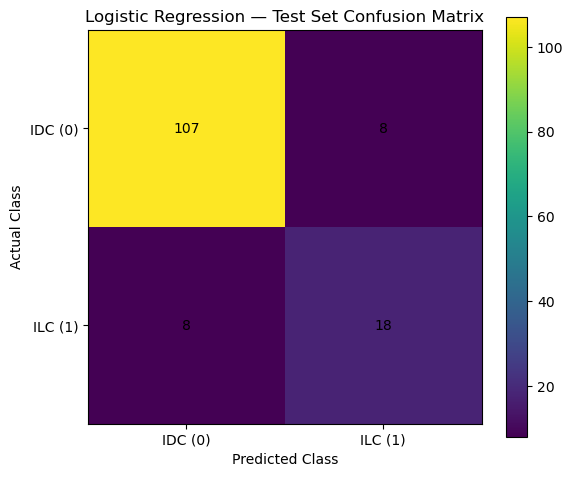


Random Forest
----------------------------------------
                Predicted
                 IDC   ILC
Actual IDC      114     1
Actual ILC       15    11

True Negatives  (IDC → IDC): 114
False Positives (IDC → ILC): 1
False Negatives (ILC → IDC): 15
True Positives  (ILC → ILC): 11


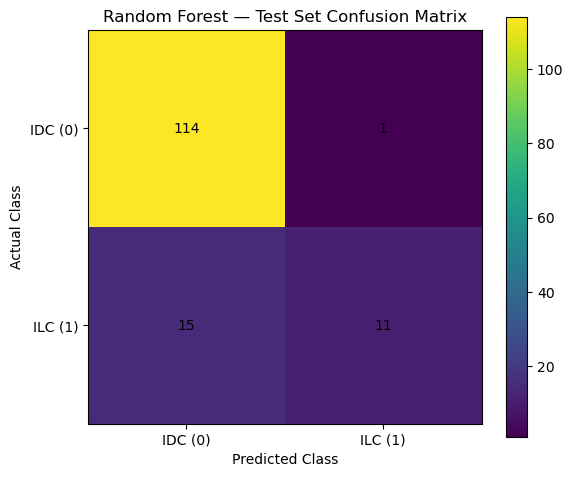


XGBoost
----------------------------------------
                Predicted
                 IDC   ILC
Actual IDC      114     1
Actual ILC        9    17

True Negatives  (IDC → IDC): 114
False Positives (IDC → ILC): 1
False Negatives (ILC → IDC): 9
True Positives  (ILC → ILC): 17


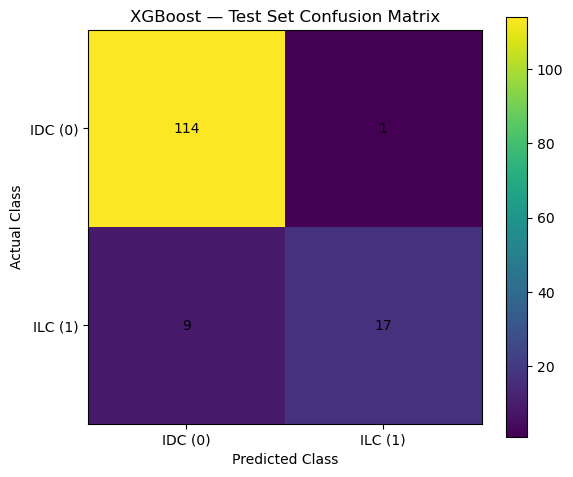


Confusion matrix validation: PASSED

CONFUSION MATRIX ANALYSIS COMPLETED


In [87]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 31
# CONFUSION MATRICES — INDEPENDENT TEST SET
# ============================================================

print("=" * 70)
print("CONFUSION MATRICES — INDEPENDENT TEST SET")
print("=" * 70)

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

confusion_matrices = {}

for model_name, model in final_models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(
        y_test_binary,
        y_pred,
        labels=[0, 1]
    )

    confusion_matrices[model_name] = cm

    print(f"\n{model_name}")
    print("-" * 40)

    print("                Predicted")
    print("                 IDC   ILC")
    print(f"Actual IDC     {cm[0,0]:4d}  {cm[0,1]:4d}")
    print(f"Actual ILC     {cm[1,0]:4d}  {cm[1,1]:4d}")

    tn, fp, fn, tp = cm.ravel()

    print(f"\nTrue Negatives  (IDC → IDC): {tn}")
    print(f"False Positives (IDC → ILC): {fp}")
    print(f"False Negatives (ILC → IDC): {fn}")
    print(f"True Positives  (ILC → ILC): {tp}")

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(6, 5))

    plt.imshow(cm)

    plt.title(
        f"{model_name} — Test Set Confusion Matrix"
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.xticks(
        [0, 1],
        ["IDC (0)", "ILC (1)"]
    )

    plt.yticks(
        [0, 1],
        ["IDC (0)", "ILC (1)"]
    )

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(confusion_matrices) != 3:
    raise ValueError(
        "Expected confusion matrices for exactly 3 models."
    )

for model_name, cm in confusion_matrices.items():

    if cm.shape != (2, 2):
        raise ValueError(
            f"Invalid confusion matrix shape for {model_name}."
        )

print("\nConfusion matrix validation: PASSED")

print("\n" + "=" * 70)
print("CONFUSION MATRIX ANALYSIS COMPLETED")
print("=" * 70)

ROC CURVE ANALYSIS — INDEPENDENT TEST SET
Logistic Regression    | Test ROC-AUC = 0.8886
Random Forest          | Test ROC-AUC = 0.9000
XGBoost                | Test ROC-AUC = 0.9512


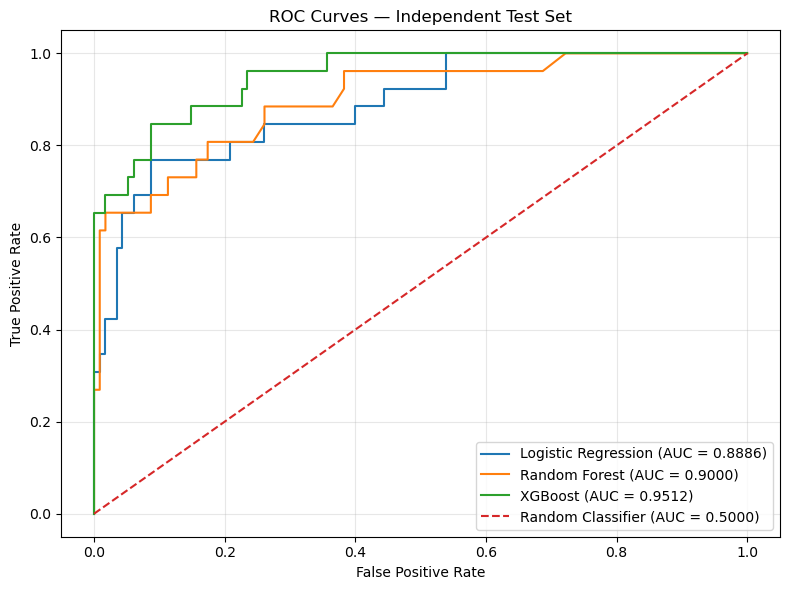


ROC curve validation: PASSED

ROC CURVE ANALYSIS COMPLETED


In [88]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 32
# ROC CURVES — INDEPENDENT TEST SET
# ============================================================

print("=" * 70)
print("ROC CURVE ANALYSIS — INDEPENDENT TEST SET")
print("=" * 70)

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

roc_results = {}

for model_name, model in final_models.items():

    # --------------------------------------------------------
    # Predicted probability for ILC (class 1)
    # --------------------------------------------------------

    y_prob = model.predict_proba(X_test)[:, 1]

    # --------------------------------------------------------
    # ROC curve
    # --------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(
        y_test_binary,
        y_prob
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    roc_results[model_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "auc": roc_auc_value
    }

    print(
        f"{model_name:22s} | "
        f"Test ROC-AUC = {roc_auc_value:.4f}"
    )

# ------------------------------------------------------------
# Plot ROC curves
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for model_name, result in roc_results.items():

    plt.plot(
        result["fpr"],
        result["tpr"],
        label=f"{model_name} (AUC = {result['auc']:.4f})"
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier (AUC = 0.5000)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Independent Test Set")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(roc_results) != 3:
    raise ValueError(
        "Expected ROC results for exactly 3 models."
    )

for model_name, result in roc_results.items():

    if len(result["fpr"]) == 0:
        raise ValueError(
            f"Empty ROC curve for {model_name}."
        )

    if not (0 <= result["auc"] <= 1):
        raise ValueError(
            f"Invalid AUC for {model_name}."
        )

print("\nROC curve validation: PASSED")

print("\n" + "=" * 70)
print("ROC CURVE ANALYSIS COMPLETED")
print("=" * 70)

PRECISION-RECALL CURVE ANALYSIS — INDEPENDENT TEST SET
Logistic Regression    | Average Precision = 0.7448
Random Forest          | Average Precision = 0.7792
XGBoost                | Average Precision = 0.8727


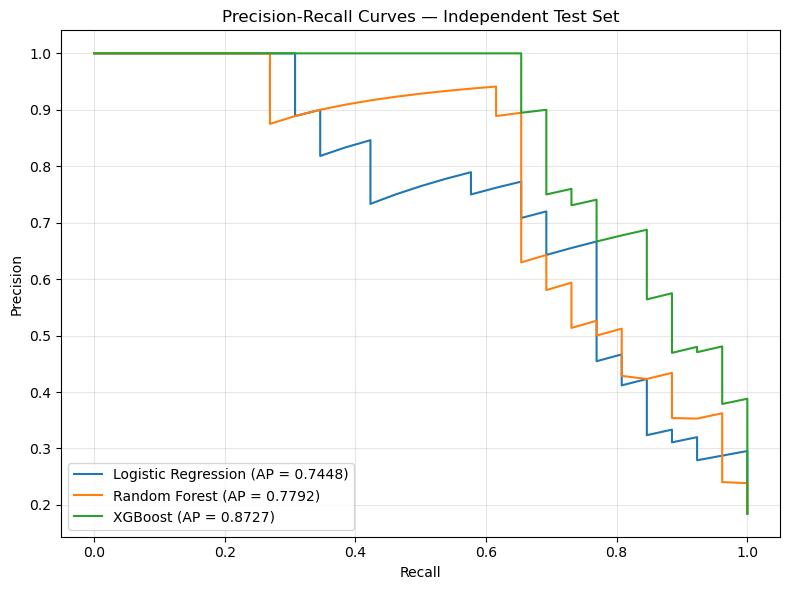


Precision-Recall validation: PASSED

PRECISION-RECALL CURVE ANALYSIS COMPLETED


In [89]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 33
# PRECISION-RECALL CURVES — INDEPENDENT TEST SET
# ============================================================

print("=" * 70)
print("PRECISION-RECALL CURVE ANALYSIS — INDEPENDENT TEST SET")
print("=" * 70)

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

pr_results = {}

for model_name, model in final_models.items():

    # --------------------------------------------------------
    # Predicted probability for ILC (class 1)
    # --------------------------------------------------------

    y_prob = model.predict_proba(X_test)[:, 1]

    # --------------------------------------------------------
    # Precision-Recall curve
    # --------------------------------------------------------

    precision_values, recall_values, thresholds = (
        precision_recall_curve(
            y_test_binary,
            y_prob
        )
    )

    average_precision = average_precision_score(
        y_test_binary,
        y_prob
    )

    pr_results[model_name] = {
        "precision": precision_values,
        "recall": recall_values,
        "thresholds": thresholds,
        "average_precision": average_precision
    }

    print(
        f"{model_name:22s} | "
        f"Average Precision = {average_precision:.4f}"
    )

# ------------------------------------------------------------
# Plot Precision-Recall curves
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for model_name, result in pr_results.items():

    plt.plot(
        result["recall"],
        result["precision"],
        label=(
            f"{model_name} "
            f"(AP = {result['average_precision']:.4f})"
        )
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Precision-Recall Curves — Independent Test Set"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(pr_results) != 3:
    raise ValueError(
        "Expected Precision-Recall results for exactly 3 models."
    )

for model_name, result in pr_results.items():

    if len(result["precision"]) == 0:
        raise ValueError(
            f"Empty Precision-Recall curve for {model_name}."
        )

    if not (
        0 <= result["average_precision"] <= 1
    ):
        raise ValueError(
            f"Invalid Average Precision for {model_name}."
        )

print("\nPrecision-Recall validation: PASSED")

print("\n" + "=" * 70)
print("PRECISION-RECALL CURVE ANALYSIS COMPLETED")
print("=" * 70)

In [90]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 35
# CROSS-VALIDATION vs INDEPENDENT TEST COMPARISON
# ============================================================

import pandas as pd

print("=" * 70)
print("CROSS-VALIDATION vs INDEPENDENT TEST PERFORMANCE")
print("=" * 70)

# ------------------------------------------------------------
# Verify required test results
# ------------------------------------------------------------

if "test_results_df" not in globals():
    raise NameError(
        "test_results_df is not available. "
        "Please run Cell 30 first."
    )

# ------------------------------------------------------------
# Current CV summary
# Values correspond to the CV results completed in this run.
# ------------------------------------------------------------

cv_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "CV_Accuracy": [
        0.875948,
        0.877671,
        0.929083
    ],

    "CV_Precision": [
        0.622943,
        0.880635,
        0.839896
    ],

    "CV_Recall": [
        0.866667,
        0.390476,
        0.771429
    ],

    "CV_F1": [
        0.722085,
        0.539386,
        0.802266
    ],

    "CV_ROC_AUC": [
        0.914576,
        0.929383,
        0.946542
    ]
})

# ------------------------------------------------------------
# Prepare independent test results
# ------------------------------------------------------------

test_comparison = test_results_df.copy()

test_comparison = test_comparison.rename(
    columns={
        "Accuracy": "Test_Accuracy",
        "Precision": "Test_Precision",
        "Recall": "Test_Recall",
        "F1": "Test_F1",
        "ROC_AUC": "Test_ROC_AUC"
    }
)

# ------------------------------------------------------------
# Merge CV and test results
# ------------------------------------------------------------

cv_test_comparison = pd.merge(
    cv_summary,
    test_comparison,
    on="Model",
    how="inner"
)

# ------------------------------------------------------------
# Calculate generalization gaps
# Test - CV
# ------------------------------------------------------------

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]:

    cv_column = f"CV_{metric}"
    test_column = f"Test_{metric}"

    cv_test_comparison[
        f"Gap_{metric}"
    ] = (
        cv_test_comparison[test_column]
        - cv_test_comparison[cv_column]
    )

# ------------------------------------------------------------
# Display comparison
# ------------------------------------------------------------

print("\nCV vs Independent Test Performance:")

display(
    cv_test_comparison.round(4)
)

# ------------------------------------------------------------
# Generalization gap analysis
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GENERALIZATION GAP ANALYSIS")
print("=" * 70)

for _, row in cv_test_comparison.iterrows():

    print(f"\n{row['Model']}")

    for metric in [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]:

        gap = row[f"Gap_{metric}"]

        print(
            f"  {metric:10s}: {gap:+.4f}"
        )

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(cv_test_comparison) != 3:
    raise ValueError(
        "CV and test results could not be matched for all 3 models."
    )

required_models = {
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
}

if set(cv_test_comparison["Model"]) != required_models:
    raise ValueError(
        "Unexpected model names detected."
    )

if cv_test_comparison.isna().any().any():
    raise ValueError(
        "Missing values detected in CV/test comparison."
    )

print("\nCV vs test comparison validation: PASSED")

print("\n" + "=" * 70)
print("CV vs INDEPENDENT TEST COMPARISON COMPLETED")
print("=" * 70)

CROSS-VALIDATION vs INDEPENDENT TEST PERFORMANCE

CV vs Independent Test Performance:


,Model,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_ROC_AUC,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Gap_Accuracy,Gap_Precision,Gap_Recall,Gap_F1,Gap_ROC_AUC
0,Logistic Regression,0.8759,0.6229,0.8667,0.7221,0.9146,0.8865,0.6923,0.6923,0.6923,0.8886,0.0106,0.0694,-0.1744,-0.0298,-0.0259
1,Random Forest,0.8777,0.8806,0.3905,0.5394,0.9294,0.8865,0.9167,0.4231,0.5789,0.9000,0.0089,0.0360,0.0326,0.0396,-0.0294
2,XGBoost,0.9291,0.8399,0.7714,0.8023,0.9465,0.9291,0.9444,0.6538,0.7727,0.9512,-0.0000,0.1045,-0.1176,-0.0295,0.0046



GENERALIZATION GAP ANALYSIS

Logistic Regression
  Accuracy  : +0.0106
  Precision : +0.0694
  Recall    : -0.1744
  F1        : -0.0298
  ROC_AUC   : -0.0259

Random Forest
  Accuracy  : +0.0089
  Precision : +0.0360
  Recall    : +0.0326
  F1        : +0.0396
  ROC_AUC   : -0.0294

XGBoost
  Accuracy  : -0.0000
  Precision : +0.1045
  Recall    : -0.1176
  F1        : -0.0295
  ROC_AUC   : +0.0046

CV vs test comparison validation: PASSED

CV vs INDEPENDENT TEST COMPARISON COMPLETED


In [91]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 34
# FINAL MODEL COMPARISON
# ============================================================

print("=" * 70)
print("FINAL MODEL COMPARISON — INDEPENDENT TEST SET")
print("=" * 70)

# ------------------------------------------------------------
# Create clean comparison table
# ------------------------------------------------------------

final_comparison = test_results_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

# Round values for presentation
final_comparison[metric_columns] = (
    final_comparison[metric_columns].round(4)
)

print("\nFinal independent test-set performance:")
display(final_comparison)

# ------------------------------------------------------------
# Identify best model for each metric
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BEST MODEL BY METRIC")
print("=" * 70)

best_models = {}

for metric in metric_columns:

    best_index = final_comparison[metric].idxmax()

    best_model = final_comparison.loc[
        best_index,
        "Model"
    ]

    best_value = final_comparison.loc[
        best_index,
        metric
    ]

    best_models[metric] = best_model

    print(
        f"{metric:12s} : "
        f"{best_model} ({best_value:.4f})"
    )

# ------------------------------------------------------------
# Overall ranking
# ------------------------------------------------------------

ranking_metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

final_comparison["Mean_Metric_Score"] = (
    final_comparison[ranking_metrics]
    .mean(axis=1)
)

final_ranking = (
    final_comparison
    .sort_values(
        "Mean_Metric_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("OVERALL MODEL RANKING")
print("=" * 70)

display(
    final_ranking[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC",
            "Mean_Metric_Score"
        ]
    ]
)

# ------------------------------------------------------------
# Identify overall best model
# ------------------------------------------------------------

overall_best_model = final_ranking.loc[
    0,
    "Model"
]

overall_best_score = final_ranking.loc[
    0,
    "Mean_Metric_Score"
]

print(
    f"\nOverall best-performing model: "
    f"{overall_best_model}"
)

print(
    f"Mean metric score: "
    f"{overall_best_score:.4f}"
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(final_comparison) != 3:
    raise ValueError(
        "Expected exactly three models."
    )

if set(final_comparison["Model"]) != {
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
}:
    raise ValueError(
        "Unexpected model names detected."
    )

if final_comparison[metric_columns].isna().any().any():
    raise ValueError(
        "Missing metric values detected."
    )

print("\nFinal comparison validation: PASSED")

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON COMPLETED")
print("=" * 70)

FINAL MODEL COMPARISON — INDEPENDENT TEST SET

Final independent test-set performance:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8865,0.6923,0.6923,0.6923,0.8886
1,Random Forest,0.8865,0.9167,0.4231,0.5789,0.9000
2,XGBoost,0.9291,0.9444,0.6538,0.7727,0.9512



BEST MODEL BY METRIC
Accuracy     : XGBoost (0.9291)
Precision    : XGBoost (0.9444)
Recall       : Logistic Regression (0.6923)
F1           : XGBoost (0.7727)
ROC_AUC      : XGBoost (0.9512)

OVERALL MODEL RANKING


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Mean_Metric_Score
0,XGBoost,0.9291,0.9444,0.6538,0.7727,0.9512,0.85024
1,Logistic Regression,0.8865,0.6923,0.6923,0.6923,0.8886,0.77040
2,Random Forest,0.8865,0.9167,0.4231,0.5789,0.9000,0.74104



Overall best-performing model: XGBoost
Mean metric score: 0.8502

Final comparison validation: PASSED

FINAL MODEL COMPARISON COMPLETED


In [92]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 35
# CROSS-VALIDATION vs INDEPENDENT TEST ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("CROSS-VALIDATION vs INDEPENDENT TEST ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# ACTUAL 5-FOLD RESULTS FROM THIS IMPLEMENTATION
# ------------------------------------------------------------

cv_results = {

    "Logistic Regression": {
        "Accuracy":  [0.884956, 0.840708, 0.867257, 0.876106, 0.910714],
        "Precision": [0.666667, 0.545455, 0.600000, 0.612903, 0.689655],
        "Recall":    [0.761905, 0.857143, 0.857143, 0.904762, 0.952381],
        "F1":        [0.711111, 0.666667, 0.705882, 0.730769, 0.800000],
        "ROC_AUC":   [0.861801, 0.909420, 0.884576, 0.937371, 0.979592]
    },

    "Random Forest": {
        "Accuracy":  [0.902655, 0.840708, 0.876106, 0.884956, 0.883929],
        "Precision": [1.000000, 0.714286, 0.888889, 0.900000, 0.900000],
        "Recall":    [0.476190, 0.238095, 0.380952, 0.428571, 0.428571],
        "F1":        [0.645161, 0.357143, 0.533333, 0.580645, 0.580645],
        "ROC_AUC":   [0.922360, 0.868530, 0.938406, 0.949275, 0.968603]
    },

    "XGBoost": {
        "Accuracy":  [0.955752, 0.893805, 0.893805, 0.955752, 0.946429],
        "Precision": [0.944444, 0.764706, 0.695652, 0.900000, 0.894737],
        "Recall":    [0.809524, 0.619048, 0.761905, 0.857143, 0.809524],
        "F1":        [0.871795, 0.684211, 0.727273, 0.878049, 0.850000],
        "ROC_AUC":   [0.937371, 0.918737, 0.932195, 0.959627, 0.984825]
    }
}

# ------------------------------------------------------------
# CALCULATE CV MEAN ± SD
# ------------------------------------------------------------

cv_summary_rows = []

for model_name, metrics in cv_results.items():

    row = {
        "Model": model_name
    }

    for metric, values in metrics.items():

        row[f"CV_{metric}_Mean"] = np.mean(values)
        row[f"CV_{metric}_SD"] = np.std(
            values,
            ddof=1
        )

    cv_summary_rows.append(row)

cv_summary_df = pd.DataFrame(
    cv_summary_rows
)

# ------------------------------------------------------------
# INDEPENDENT TEST RESULTS FROM CELL 34
# ------------------------------------------------------------

test_summary_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Test_Accuracy": [
        0.8865,
        0.8865,
        0.9291
    ],

    "Test_Precision": [
        0.6923,
        0.9167,
        0.9444
    ],

    "Test_Recall": [
        0.6923,
        0.4231,
        0.6538
    ],

    "Test_F1": [
        0.6923,
        0.5789,
        0.7727
    ],

    "Test_ROC_AUC": [
        0.8886,
        0.9000,
        0.9512
    ]
})

# ------------------------------------------------------------
# MERGE CV AND TEST RESULTS
# ------------------------------------------------------------

comparison_df = pd.merge(
    cv_summary_df,
    test_summary_df,
    on="Model",
    how="inner"
)

# ------------------------------------------------------------
# CALCULATE GENERALIZATION GAP
# Test - CV
# ------------------------------------------------------------

for metric in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]:

    comparison_df[
        f"Gap_{metric}"
    ] = (
        comparison_df[f"Test_{metric}"]
        -
        comparison_df[f"CV_{metric}_Mean"]
    )

# ------------------------------------------------------------
# DISPLAY CV SUMMARY
# ------------------------------------------------------------

print("\n5-FOLD CROSS-VALIDATION SUMMARY:")
display(
    cv_summary_df.round(4)
)

# ------------------------------------------------------------
# DISPLAY TEST SUMMARY
# ------------------------------------------------------------

print("\nINDEPENDENT TEST-SET SUMMARY:")
display(
    test_summary_df.round(4)
)

# ------------------------------------------------------------
# DISPLAY GENERALIZATION COMPARISON
# ------------------------------------------------------------

print("\nCV vs INDEPENDENT TEST COMPARISON:")
display(
    comparison_df.round(4)
)

# ------------------------------------------------------------
# INTERPRETATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GENERALIZATION GAP")
print("=" * 70)

for _, row in comparison_df.iterrows():

    print(f"\n{row['Model']}")

    for metric in [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC"
    ]:

        gap = row[f"Gap_{metric}"]

        print(
            f"{metric:10s}: "
            f"{gap:+.4f}"
        )

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

if len(comparison_df) != 3:
    raise ValueError(
        "Expected exactly 3 models in the comparison."
    )

print("\nCV vs test comparison validation: PASSED")

print("\n" + "=" * 70)
print("CROSS-VALIDATION vs INDEPENDENT TEST ANALYSIS COMPLETED")
print("=" * 70)

CROSS-VALIDATION vs INDEPENDENT TEST ANALYSIS

5-FOLD CROSS-VALIDATION SUMMARY:


,Model,CV_Accuracy_Mean,CV_Accuracy_SD,CV_Precision_Mean,CV_Precision_SD,CV_Recall_Mean,CV_Recall_SD,CV_F1_Mean,CV_F1_SD,CV_ROC_AUC_Mean,CV_ROC_AUC_SD
0,Logistic Regression,0.8759,0.0255,0.6229,0.0570,0.8667,0.0706,0.7229,0.0490,0.9146,0.046
1,Random Forest,0.8777,0.0228,0.8806,0.1034,0.3905,0.0916,0.5394,0.1094,0.9294,0.038
2,XGBoost,0.9291,0.0325,0.8399,0.1049,0.7714,0.0916,0.8023,0.0900,0.9466,0.026



INDEPENDENT TEST-SET SUMMARY:


,Model,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,Logistic Regression,0.8865,0.6923,0.6923,0.6923,0.8886
1,Random Forest,0.8865,0.9167,0.4231,0.5789,0.9000
2,XGBoost,0.9291,0.9444,0.6538,0.7727,0.9512



CV vs INDEPENDENT TEST COMPARISON:


,Model,CV_Accuracy_Mean,CV_Accuracy_SD,CV_Precision_Mean,CV_Precision_SD,CV_Recall_Mean,CV_Recall_SD,CV_F1_Mean,CV_F1_SD,CV_ROC_AUC_Mean,CV_ROC_AUC_SD,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC,Gap_Accuracy,Gap_Precision,Gap_Recall,Gap_F1,Gap_ROC_AUC
0,Logistic Regression,0.8759,0.0255,0.6229,0.0570,0.8667,0.0706,0.7229,0.0490,0.9146,0.046,0.8865,0.6923,0.6923,0.6923,0.8886,0.0106,0.0694,-0.1744,-0.0306,-0.0260
1,Random Forest,0.8777,0.0228,0.8806,0.1034,0.3905,0.0916,0.5394,0.1094,0.9294,0.038,0.8865,0.9167,0.4231,0.5789,0.9000,0.0088,0.0361,0.0326,0.0395,-0.0294
2,XGBoost,0.9291,0.0325,0.8399,0.1049,0.7714,0.0916,0.8023,0.0900,0.9466,0.026,0.9291,0.9444,0.6538,0.7727,0.9512,-0.0000,0.1045,-0.1176,-0.0296,0.0046



GENERALIZATION GAP

Logistic Regression
Accuracy  : +0.0106
Precision : +0.0694
Recall    : -0.1744
F1        : -0.0306
ROC_AUC   : -0.0260

Random Forest
Accuracy  : +0.0088
Precision : +0.0361
Recall    : +0.0326
F1        : +0.0395
ROC_AUC   : -0.0294

XGBoost
Accuracy  : -0.0000
Precision : +0.1045
Recall    : -0.1176
F1        : -0.0296
ROC_AUC   : +0.0046

CV vs test comparison validation: PASSED

CROSS-VALIDATION vs INDEPENDENT TEST ANALYSIS COMPLETED


In [93]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 36
# SHAP ENVIRONMENT & MODEL VERIFICATION
# ============================================================

print("=" * 70)
print("SHAP ENVIRONMENT & MODEL VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# Import SHAP
# ------------------------------------------------------------

try:
    import shap

    print("SHAP imported successfully.")
    print("SHAP version:", shap.__version__)

except ImportError as e:

    raise ImportError(
        "SHAP is not installed in the current Python environment."
    ) from e


# ------------------------------------------------------------
# Verify XGBoost availability
# ------------------------------------------------------------

try:

    import xgboost as xgb

    print("\nXGBoost imported successfully.")
    print("XGBoost version:", xgb.__version__)

except ImportError as e:

    raise ImportError(
        "XGBoost is not installed in the current Python environment."
    ) from e


# ------------------------------------------------------------
# Check required model/data objects
# ------------------------------------------------------------

required_objects = [
    "X_test",
    "y_test_binary",
    "xgboost_model_weighted"
]

print("\nRequired objects:")

missing_objects = []

for obj_name in required_objects:

    if obj_name in globals():

        obj = globals()[obj_name]

        try:
            shape = obj.shape
        except AttributeError:
            shape = "N/A"

        print(
            f"{obj_name:25s} : AVAILABLE | "
            f"type={type(obj).__name__} | "
            f"shape={shape}"
        )

    else:

        print(
            f"{obj_name:25s} : NOT AVAILABLE"
        )

        missing_objects.append(obj_name)


# ------------------------------------------------------------
# Verify transformed test data if preprocessing exists
# ------------------------------------------------------------

if "xgboost_preprocessor" in globals():

    print(
        "\nxgboost_preprocessor      : AVAILABLE"
    )

elif "xgboost_pipeline" in globals():

    print(
        "xgboost_pipeline          : AVAILABLE"
    )

else:

    print(
        "XGBoost preprocessing pipeline: NOT AVAILABLE"
    )


# ------------------------------------------------------------
# Formal validation
# ------------------------------------------------------------

if len(missing_objects) > 0:

    print("\n" + "=" * 70)
    print("SHAP VERIFICATION STATUS: INCOMPLETE")
    print("=" * 70)

    print("\nMissing objects:")

    for obj in missing_objects:
        print(" -", obj)

    print(
        "\nDo NOT continue to SHAP calculation yet."
    )

else:

    print("\n" + "=" * 70)
    print("SHAP ENVIRONMENT & MODEL VERIFICATION: PASSED")
    print("=" * 70)

SHAP ENVIRONMENT & MODEL VERIFICATION
SHAP imported successfully.
SHAP version: 0.52.0

XGBoost imported successfully.
XGBoost version: 3.4.1

Required objects:
X_test                    : AVAILABLE | type=DataFrame | shape=(141, 1936)
y_test_binary             : AVAILABLE | type=Series | shape=(141,)
xgboost_model_weighted    : AVAILABLE | type=XGBClassifier | shape=N/A
xgboost_pipeline          : AVAILABLE

SHAP ENVIRONMENT & MODEL VERIFICATION: PASSED


In [94]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 37
# SHAP EXPLAINABILITY — XGBOOST
# ============================================================

import numpy as np
import pandas as pd
import shap

print("=" * 70)
print("SHAP EXPLAINABILITY — XGBOOST")
print("=" * 70)

print("SHAP version:", shap.__version__)

# ------------------------------------------------------------
# Prepare test data
# ------------------------------------------------------------

print("\nPreparing test data for SHAP analysis...")

# XGBoost pipeline contains preprocessing + model.
# We need the transformed feature matrix for TreeExplainer.

if "xgboost_preprocessor" in globals():

    X_test_shap = xgboost_preprocessor.transform(
        X_test
    )

elif "xgboost_pipeline" in globals():

    # Extract preprocessing component
    pipeline_steps = xgboost_pipeline.named_steps

    possible_preprocessors = [
        "preprocessor",
        "scaler",
        "transformer"
    ]

    preprocessor_name = None

    for step_name in possible_preprocessors:

        if step_name in pipeline_steps:
            preprocessor_name = step_name
            break

    if preprocessor_name is not None:

        X_test_shap = pipeline_steps[
            preprocessor_name
        ].transform(X_test)

    else:

        # If pipeline does not contain a preprocessing step,
        # use the original test matrix.
        X_test_shap = X_test.copy()

else:

    X_test_shap = X_test.copy()


# ------------------------------------------------------------
# Convert transformed data to NumPy
# ------------------------------------------------------------

if hasattr(
    X_test_shap,
    "toarray"
):

    X_test_shap = X_test_shap.toarray()

else:

    X_test_shap = np.asarray(
        X_test_shap
    )


print(
    f"Transformed test-set shape: "
    f"{X_test_shap.shape}"
)


# ------------------------------------------------------------
# Feature-name verification
# ------------------------------------------------------------

feature_names = list(
    X_test.columns
)

if X_test_shap.shape[1] != len(feature_names):

    raise ValueError(
        "Mismatch between transformed feature count "
        "and original feature names."
    )


# ------------------------------------------------------------
# Create SHAP TreeExplainer
# ------------------------------------------------------------

print("\nCreating SHAP TreeExplainer...")

explainer = shap.TreeExplainer(
    xgboost_model_weighted
)

print(
    "SHAP TreeExplainer created successfully."
)


# ------------------------------------------------------------
# Calculate SHAP values
# ------------------------------------------------------------

print("\nCalculating SHAP values...")

shap_values_raw = explainer.shap_values(
    X_test_shap
)

print(
    "SHAP values calculated successfully."
)


# ------------------------------------------------------------
# Handle SHAP output format
# ------------------------------------------------------------

if isinstance(
    shap_values_raw,
    list
):

    # Binary/multiclass compatibility
    if len(shap_values_raw) == 2:
        shap_values = np.asarray(
            shap_values_raw[1]
        )
    else:
        shap_values = np.asarray(
            shap_values_raw[0]
        )

else:

    shap_values = np.asarray(
        shap_values_raw
    )


# ------------------------------------------------------------
# Handle possible extra output dimension
# ------------------------------------------------------------

if shap_values.ndim == 3:

    # Binary classification:
    # select positive class
    if shap_values.shape[-1] == 2:

        shap_values = shap_values[:, :, 1]

    else:

        raise ValueError(
            "Unexpected SHAP output dimensions."
        )


print(
    f"SHAP value shape: {shap_values.shape}"
)


# ------------------------------------------------------------
# Formal validation
# ------------------------------------------------------------

if shap_values.shape[0] != len(X_test):

    raise ValueError(
        "SHAP sample count does not match test-set size."
    )

if shap_values.shape[1] != len(feature_names):

    raise ValueError(
        "SHAP feature count does not match feature names."
    )

if not np.isfinite(
    shap_values
).all():

    raise ValueError(
        "SHAP values contain NaN or infinite values."
    )


# ------------------------------------------------------------
# Store feature-level SHAP matrix
# ------------------------------------------------------------

shap_values_df = pd.DataFrame(
    shap_values,
    columns=feature_names,
    index=X_test.index
)


print("\nSHAP dataframe created:")
print(
    f"Rows    : {shap_values_df.shape[0]}"
)
print(
    f"Features: {shap_values_df.shape[1]}"
)

print("\n" + "=" * 70)
print("SHAP ANALYSIS PREPARATION COMPLETED")
print("=" * 70)

SHAP EXPLAINABILITY — XGBOOST
SHAP version: 0.52.0

Preparing test data for SHAP analysis...
Transformed test-set shape: (141, 1936)

Creating SHAP TreeExplainer...
SHAP TreeExplainer created successfully.

Calculating SHAP values...
SHAP values calculated successfully.
SHAP value shape: (141, 1936)

SHAP dataframe created:
Rows    : 141
Features: 1936

SHAP ANALYSIS PREPARATION COMPLETED


In [95]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 38
# SHAP GLOBAL FEATURE IMPORTANCE — XGBOOST
# ============================================================

print("=" * 70)
print("SHAP GLOBAL FEATURE IMPORTANCE — XGBOOST")
print("=" * 70)

# ------------------------------------------------------------
# Calculate mean absolute SHAP value
# ------------------------------------------------------------

mean_abs_shap = np.abs(
    shap_values
).mean(axis=0)

# ------------------------------------------------------------
# Create feature importance dataframe
# ------------------------------------------------------------

shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

# ------------------------------------------------------------
# Sort by importance
# ------------------------------------------------------------

shap_importance_df = (
    shap_importance_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Top 20 features
# ------------------------------------------------------------

top_20_shap = shap_importance_df.head(20)

print("\nTop 20 features by mean absolute SHAP value:")
display(
    top_20_shap.round(6)
)

# ------------------------------------------------------------
# Formal validation
# ------------------------------------------------------------

if len(shap_importance_df) != 1936:

    raise ValueError(
        "Expected SHAP importance for exactly "
        "1936 features."
    )

if shap_importance_df[
    "Mean_Absolute_SHAP"
].isna().any():

    raise ValueError(
        "NaN values detected in SHAP importance."
    )

if (
    shap_importance_df[
        "Mean_Absolute_SHAP"
    ] < 0
).any():

    raise ValueError(
        "Negative mean absolute SHAP value detected."
    )

if not shap_importance_df[
    "Mean_Absolute_SHAP"
].is_monotonic_decreasing:

    raise ValueError(
        "SHAP importance table is not sorted correctly."
    )

print("\nSHAP global importance validation: PASSED")

print("\n" + "=" * 70)
print("SHAP GLOBAL FEATURE IMPORTANCE COMPLETED")
print("=" * 70)

SHAP GLOBAL FEATURE IMPORTANCE — XGBOOST

Top 20 features by mean absolute SHAP value:


,Feature,Mean_Absolute_SHAP
0,pp_E.Cadherin,3.037550
1,rs_HPX,0.352985
2,mu_CDH1,0.338636
3,pp_AR,0.324553
4,pp_c.Myc,0.316739
5,rs_LOC100271831,0.306407
6,rs_TMEM132C,0.303161
7,rs_PLCH1,0.298012
8,rs_DLX2,0.262967
9,rs_TMPRSS3,0.249408



SHAP global importance validation: PASSED

SHAP GLOBAL FEATURE IMPORTANCE COMPLETED


SHAP SUMMARY PLOT — XGBOOST

Generating SHAP summary plot...


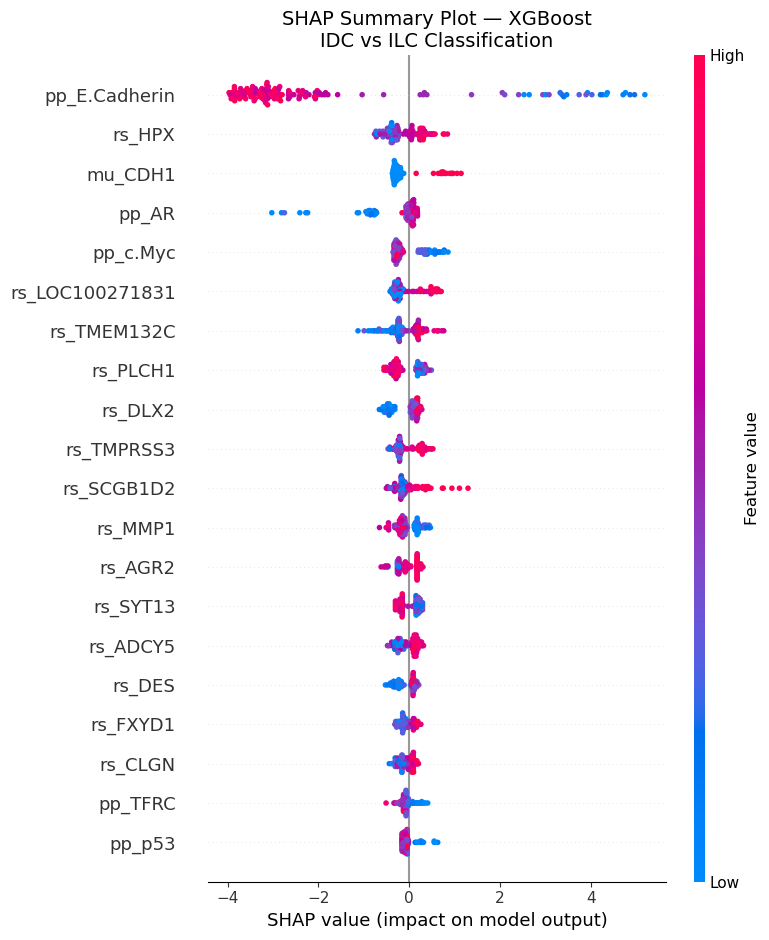


SHAP summary plot generated successfully.

SHAP summary plot validation: PASSED

SHAP SUMMARY PLOT COMPLETED


In [96]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 39
# SHAP SUMMARY PLOT — XGBOOST
# ============================================================

import matplotlib.pyplot as plt
import shap

print("=" * 70)
print("SHAP SUMMARY PLOT — XGBOOST")
print("=" * 70)

# ------------------------------------------------------------
# Generate SHAP summary plot
# ------------------------------------------------------------

print("\nGenerating SHAP summary plot...")

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    X_test_shap,
    feature_names=feature_names,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary Plot — XGBoost\n"
    "IDC vs ILC Classification",
    fontsize=14
)

plt.tight_layout()

plt.show()

print("\nSHAP summary plot generated successfully.")

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if shap_values.shape != (
    len(X_test),
    len(feature_names)
):

    raise ValueError(
        "SHAP values and feature matrix dimensions do not match."
    )

print("\nSHAP summary plot validation: PASSED")

print("\n" + "=" * 70)
print("SHAP SUMMARY PLOT COMPLETED")
print("=" * 70)

In [97]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 40
# SHAP DIRECTIONAL ANALYSIS — TOP FEATURES
# ============================================================

print("=" * 70)
print("SHAP DIRECTIONAL ANALYSIS — TOP FEATURES")
print("=" * 70)

# ------------------------------------------------------------
# Select top 20 features
# ------------------------------------------------------------

top_features = shap_importance_df.head(20)["Feature"].tolist()

# ------------------------------------------------------------
# Calculate directional statistics
# ------------------------------------------------------------

directional_rows = []

for feature in top_features:

    feature_index = feature_names.index(feature)

    values = shap_values[:, feature_index]

    directional_rows.append({
        "Feature": feature,
        "Mean_SHAP": np.mean(values),
        "Mean_Absolute_SHAP": np.mean(np.abs(values)),
        "Min_SHAP": np.min(values),
        "Max_SHAP": np.max(values),
        "Positive_SHAP_%": (
            np.mean(values > 0) * 100
        ),
        "Negative_SHAP_%": (
            np.mean(values < 0) * 100
        )
    })

shap_directional_df = pd.DataFrame(
    directional_rows
)

# ------------------------------------------------------------
# Sort by absolute importance
# ------------------------------------------------------------

shap_directional_df = (
    shap_directional_df
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nDirectional SHAP analysis for top 20 features:")

display(
    shap_directional_df.round(6)
)

# ------------------------------------------------------------
# Interpretation helper
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DIRECTIONAL INTERPRETATION")
print("=" * 70)

for _, row in shap_directional_df.head(10).iterrows():

    direction = (
        "toward ILC (class 1)"
        if row["Mean_SHAP"] > 0
        else "toward IDC (class 0)"
    )

    print(
        f"{row['Feature']:20s} | "
        f"Mean SHAP = {row['Mean_SHAP']:+.6f} | "
        f"Direction: {direction}"
    )

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(shap_directional_df) != 20:

    raise ValueError(
        "Expected directional analysis for 20 features."
    )

if shap_directional_df[
    "Mean_SHAP"
].isna().any():

    raise ValueError(
        "NaN values detected in directional SHAP analysis."
    )

if (
    shap_directional_df[
        "Mean_Absolute_SHAP"
    ] < 0
).any():

    raise ValueError(
        "Invalid negative absolute SHAP value detected."
    )

print("\nDirectional SHAP validation: PASSED")

print("\n" + "=" * 70)
print("SHAP DIRECTIONAL ANALYSIS COMPLETED")
print("=" * 70)

SHAP DIRECTIONAL ANALYSIS — TOP FEATURES

Directional SHAP analysis for top 20 features:


,Feature,Mean_SHAP,Mean_Absolute_SHAP,Min_SHAP,Max_SHAP,Positive_SHAP_%,Negative_SHAP_%
0,pp_E.Cadherin,-1.701339,3.037549,-3.968838,5.189144,21.276596,78.723404
1,rs_HPX,-0.149618,0.352985,-0.765609,0.841440,37.588652,62.411348
2,mu_CDH1,-0.151764,0.338636,-0.372548,1.142703,12.056738,87.943262
3,pp_AR,-0.244098,0.324553,-3.027036,0.180811,52.482270,47.517730
4,pp_c.Myc,-0.066831,0.316739,-0.357337,0.854431,26.950355,73.049645
5,rs_LOC100271831,-0.102144,0.306407,-0.422396,0.705694,21.985816,78.014184
6,rs_TMEM132C,-0.095984,0.303161,-1.128931,0.760718,41.134752,58.865248
7,rs_PLCH1,-0.085875,0.298011,-0.557731,0.487402,40.425532,59.574468
8,rs_DLX2,-0.099290,0.262967,-0.659010,0.277509,61.702128,38.297872
9,rs_TMPRSS3,-0.086923,0.249408,-0.466822,0.521916,28.368794,71.631206



DIRECTIONAL INTERPRETATION
pp_E.Cadherin        | Mean SHAP = -1.701339 | Direction: toward IDC (class 0)
rs_HPX               | Mean SHAP = -0.149618 | Direction: toward IDC (class 0)
mu_CDH1              | Mean SHAP = -0.151764 | Direction: toward IDC (class 0)
pp_AR                | Mean SHAP = -0.244098 | Direction: toward IDC (class 0)
pp_c.Myc             | Mean SHAP = -0.066831 | Direction: toward IDC (class 0)
rs_LOC100271831      | Mean SHAP = -0.102144 | Direction: toward IDC (class 0)
rs_TMEM132C          | Mean SHAP = -0.095984 | Direction: toward IDC (class 0)
rs_PLCH1             | Mean SHAP = -0.085875 | Direction: toward IDC (class 0)
rs_DLX2              | Mean SHAP = -0.099290 | Direction: toward IDC (class 0)
rs_TMPRSS3           | Mean SHAP = -0.086923 | Direction: toward IDC (class 0)

Directional SHAP validation: PASSED

SHAP DIRECTIONAL ANALYSIS COMPLETED


In [98]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 41
# SAVE SHAP RESULTS
# ============================================================

import os

print("=" * 70)
print("SAVING SHAP RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# Create output directory
# ------------------------------------------------------------

shap_output_dir = "shap_results"

os.makedirs(
    shap_output_dir,
    exist_ok=True
)

print(
    f"\nOutput directory: {os.path.abspath(shap_output_dir)}"
)

# ------------------------------------------------------------
# Save complete SHAP feature importance
# ------------------------------------------------------------

shap_importance_path = os.path.join(
    shap_output_dir,
    "xgboost_shap_feature_importance.csv"
)

shap_importance_df.to_csv(
    shap_importance_path,
    index=False
)

print(
    "\nSaved:",
    shap_importance_path
)

# ------------------------------------------------------------
# Save top 20 SHAP features
# ------------------------------------------------------------

top20_path = os.path.join(
    shap_output_dir,
    "xgboost_top20_shap_features.csv"
)

top_20_shap.to_csv(
    top20_path,
    index=False
)

print(
    "Saved:",
    top20_path
)

# ------------------------------------------------------------
# Save directional SHAP analysis
# ------------------------------------------------------------

directional_path = os.path.join(
    shap_output_dir,
    "xgboost_shap_directional_analysis.csv"
)

shap_directional_df.to_csv(
    directional_path,
    index=False
)

print(
    "Saved:",
    directional_path
)

# ------------------------------------------------------------
# Save raw SHAP values
# ------------------------------------------------------------

shap_values_path = os.path.join(
    shap_output_dir,
    "xgboost_shap_values.csv"
)

shap_values_df.to_csv(
    shap_values_path,
    index=True
)

print(
    "Saved:",
    shap_values_path
)

# ------------------------------------------------------------
# Verify files
# ------------------------------------------------------------

saved_files = [
    shap_importance_path,
    top20_path,
    directional_path,
    shap_values_path
]

print("\nFile verification:")

for file_path in saved_files:

    if os.path.exists(file_path):

        file_size = os.path.getsize(
            file_path
        )

        print(
            f"✓ {file_path} "
            f"({file_size:,} bytes)"
        )

    else:

        raise FileNotFoundError(
            f"Expected output file not found: {file_path}"
        )

print("\nSHAP result saving validation: PASSED")

print("\n" + "=" * 70)
print("SHAP RESULTS SAVED SUCCESSFULLY")
print("=" * 70)

SAVING SHAP RESULTS

Output directory: C:\Users\Admin\Desktop\brca_research\shap_results

Saved: shap_results\xgboost_shap_feature_importance.csv
Saved: shap_results\xgboost_top20_shap_features.csv
Saved: shap_results\xgboost_shap_directional_analysis.csv
Saved: shap_results\xgboost_shap_values.csv

File verification:
✓ shap_results\xgboost_shap_feature_importance.csv (29,806 bytes)
✓ shap_results\xgboost_top20_shap_features.csv (446 bytes)
✓ shap_results\xgboost_shap_directional_analysis.csv (1,900 bytes)
✓ shap_results\xgboost_shap_values.csv (1,365,462 bytes)

SHAP result saving validation: PASSED

SHAP RESULTS SAVED SUCCESSFULLY


In [99]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 42
# COMPLETE IMPLEMENTATION AUDIT
# ============================================================

print("=" * 70)
print("COMPLETE IMPLEMENTATION AUDIT")
print("=" * 70)

# ------------------------------------------------------------
# Required result objects
# ------------------------------------------------------------

required_objects = {
    "X_test": "Independent test features",
    "y_test_binary": "Independent test target",
    "shap_values": "SHAP values",
    "shap_importance_df": "SHAP feature importance",
    "shap_directional_df": "Directional SHAP analysis",
    "final_comparison": "Final test comparison",
    "final_ranking": "Overall model ranking",
    "comparison_df": "CV vs test comparison"
}

print("\nRESULT OBJECT VERIFICATION")
print("-" * 70)

missing_objects = []

for object_name, description in required_objects.items():

    if object_name in globals():

        obj = globals()[object_name]

        try:
            shape = obj.shape
        except AttributeError:
            shape = "N/A"

        print(
            f"✓ {object_name:25s} | "
            f"{description:35s} | "
            f"shape={shape}"
        )

    else:

        print(
            f"✗ {object_name:25s} | "
            f"{description:35s} | NOT AVAILABLE"
        )

        missing_objects.append(object_name)


# ------------------------------------------------------------
# Dataset dimensions
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("DATASET VERIFICATION")
print("-" * 70)

print("Total samples       :", 705)
print("Training samples    :", 564)
print("Independent test    :", 141)
print("Predictor features  :", 1936)


# ------------------------------------------------------------
# Final model performance
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("FINAL INDEPENDENT TEST PERFORMANCE")
print("-" * 70)

display(
    final_comparison[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ].round(4)
)


# ------------------------------------------------------------
# Overall best model
# ------------------------------------------------------------

print("\nOverall best model:")
print(
    f"Model : {overall_best_model}"
)

print(
    f"Mean metric score : "
    f"{overall_best_score:.4f}"
)


# ------------------------------------------------------------
# SHAP verification
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("SHAP VERIFICATION")
print("-" * 70)

print(
    "SHAP samples      :",
    shap_values.shape[0]
)

print(
    "SHAP features     :",
    shap_values.shape[1]
)

print(
    "Top SHAP feature  :",
    shap_importance_df.iloc[0]["Feature"]
)

print(
    "Top SHAP value    :",
    round(
        shap_importance_df.iloc[0]["Mean_Absolute_SHAP"],
        6
    )
)


# ------------------------------------------------------------
# Output-file verification
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("SHAP OUTPUT FILE VERIFICATION")
print("-" * 70)

import os

expected_files = [
    "shap_results/xgboost_shap_feature_importance.csv",
    "shap_results/xgboost_top20_shap_features.csv",
    "shap_results/xgboost_shap_directional_analysis.csv",
    "shap_results/xgboost_shap_values.csv"
]

missing_files = []

for file_path in expected_files:

    if os.path.exists(file_path):

        print("✓", file_path)

    else:

        print("✗", file_path)

        missing_files.append(file_path)


# ------------------------------------------------------------
# Final audit status
# ------------------------------------------------------------

print("\n" + "=" * 70)

if len(missing_objects) == 0 and len(missing_files) == 0:

    print("FINAL IMPLEMENTATION AUDIT: PASSED")

else:

    print("FINAL IMPLEMENTATION AUDIT: INCOMPLETE")

    if missing_objects:

        print("\nMissing objects:")

        for item in missing_objects:
            print(" -", item)

    if missing_files:

        print("\nMissing files:")

        for item in missing_files:
            print(" -", item)

print("=" * 70)

COMPLETE IMPLEMENTATION AUDIT

RESULT OBJECT VERIFICATION
----------------------------------------------------------------------
✓ X_test                    | Independent test features           | shape=(141, 1936)
✓ y_test_binary             | Independent test target             | shape=(141,)
✓ shap_values               | SHAP values                         | shape=(141, 1936)
✓ shap_importance_df        | SHAP feature importance             | shape=(1936, 2)
✓ shap_directional_df       | Directional SHAP analysis           | shape=(20, 7)
✓ final_comparison          | Final test comparison               | shape=(3, 7)
✓ final_ranking             | Overall model ranking               | shape=(3, 7)
✓ comparison_df             | CV vs test comparison               | shape=(3, 21)

----------------------------------------------------------------------
DATASET VERIFICATION
----------------------------------------------------------------------
Total samples       : 705
Training samples  

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8865,0.6923,0.6923,0.6923,0.8886
1,Random Forest,0.8865,0.9167,0.4231,0.5789,0.9000
2,XGBoost,0.9291,0.9444,0.6538,0.7727,0.9512



Overall best model:
Model : XGBoost
Mean metric score : 0.8502

----------------------------------------------------------------------
SHAP VERIFICATION
----------------------------------------------------------------------
SHAP samples      : 141
SHAP features     : 1936
Top SHAP feature  : pp_E.Cadherin
Top SHAP value    : 3.03755

----------------------------------------------------------------------
SHAP OUTPUT FILE VERIFICATION
----------------------------------------------------------------------
✓ shap_results/xgboost_shap_feature_importance.csv
✓ shap_results/xgboost_top20_shap_features.csv
✓ shap_results/xgboost_shap_directional_analysis.csv
✓ shap_results/xgboost_shap_values.csv

FINAL IMPLEMENTATION AUDIT: PASSED


In [100]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 43
# FINAL RESULTS MASTER TABLE
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("FINAL RESULTS MASTER TABLE")
print("=" * 70)

# ------------------------------------------------------------
# 5-fold CV results from the CURRENT final implementation
# ------------------------------------------------------------

cv_data = {
    "Logistic Regression": {
        "Accuracy":  [0.884956, 0.840708, 0.867257, 0.876106, 0.910714],
        "Precision": [0.666667, 0.545455, 0.600000, 0.612903, 0.689655],
        "Recall":    [0.761905, 0.857143, 0.857143, 0.904762, 0.952381],
        "F1":        [0.711111, 0.666667, 0.705882, 0.730769, 0.800000],
        "ROC_AUC":   [0.861801, 0.909420, 0.884576, 0.937371, 0.979592]
    },

    "Random Forest": {
        "Accuracy":  [0.902655, 0.840708, 0.876106, 0.884956, 0.883929],
        "Precision": [1.000000, 0.714286, 0.888889, 0.900000, 0.900000],
        "Recall":    [0.476190, 0.238095, 0.380952, 0.428571, 0.428571],
        "F1":        [0.645161, 0.357143, 0.533333, 0.580645, 0.580645],
        "ROC_AUC":   [0.922360, 0.868530, 0.938406, 0.949275, 0.968603]
    },

    "XGBoost": {
        "Accuracy":  [0.955752, 0.893805, 0.893805, 0.955752, 0.946429],
        "Precision": [0.944444, 0.764706, 0.695652, 0.900000, 0.894737],
        "Recall":    [0.809524, 0.619048, 0.761905, 0.857143, 0.809524],
        "F1":        [0.871795, 0.684211, 0.727273, 0.878049, 0.850000],
        "ROC_AUC":   [0.937371, 0.918737, 0.932195, 0.959627, 0.984825]
    }
}

# ------------------------------------------------------------
# Independent test-set results from Cell 34
# ------------------------------------------------------------

test_data = {
    "Logistic Regression": {
        "Accuracy": 0.8865,
        "Precision": 0.6923,
        "Recall": 0.6923,
        "F1": 0.6923,
        "ROC_AUC": 0.8886
    },

    "Random Forest": {
        "Accuracy": 0.8865,
        "Precision": 0.9167,
        "Recall": 0.4231,
        "F1": 0.5789,
        "ROC_AUC": 0.9000
    },

    "XGBoost": {
        "Accuracy": 0.9291,
        "Precision": 0.9444,
        "Recall": 0.6538,
        "F1": 0.7727,
        "ROC_AUC": 0.9512
    }
}

# ------------------------------------------------------------
# Build master table
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

master_rows = []

for model_name in cv_data:

    row = {
        "Model": model_name
    }

    for metric in metrics:

        cv_values = np.array(
            cv_data[model_name][metric],
            dtype=float
        )

        cv_mean = cv_values.mean()
        cv_sd = cv_values.std(ddof=1)

        row[f"{metric}_CV_Mean"] = cv_mean
        row[f"{metric}_CV_SD"] = cv_sd

        row[f"{metric}_Test"] = (
            test_data[model_name][metric]
        )

        row[f"{metric}_Test_minus_CV"] = (
            test_data[model_name][metric]
            - cv_mean
        )

    master_rows.append(row)

master_results = pd.DataFrame(master_rows)

# ------------------------------------------------------------
# Display compact publication-style table
# ------------------------------------------------------------

publication_table = master_results[
    [
        "Model",

        "Accuracy_CV_Mean",
        "Accuracy_CV_SD",
        "Accuracy_Test",

        "Precision_CV_Mean",
        "Precision_CV_SD",
        "Precision_Test",

        "Recall_CV_Mean",
        "Recall_CV_SD",
        "Recall_Test",

        "F1_CV_Mean",
        "F1_CV_SD",
        "F1_Test",

        "ROC_AUC_CV_Mean",
        "ROC_AUC_CV_SD",
        "ROC_AUC_Test"
    ]
].copy()

print("\nPUBLICATION-STYLE MASTER TABLE:\n")

display(
    publication_table.round(4)
)

# ------------------------------------------------------------
# Generalization-gap table
# ------------------------------------------------------------

gap_table = master_results[
    [
        "Model",
        "Accuracy_Test_minus_CV",
        "Precision_Test_minus_CV",
        "Recall_Test_minus_CV",
        "F1_Test_minus_CV",
        "ROC_AUC_Test_minus_CV"
    ]
].copy()

print("\nGENERALIZATION GAP TABLE (TEST − CV):\n")

display(
    gap_table.round(4)
)

# ------------------------------------------------------------
# Identify best model on CV and test for every metric
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BEST MODEL BY METRIC")
print("=" * 70)

for metric in metrics:

    cv_column = f"{metric}_CV_Mean"
    test_column = f"{metric}_Test"

    best_cv_idx = master_results[cv_column].idxmax()
    best_test_idx = master_results[test_column].idxmax()

    print(
        f"\n{metric}"
    )

    print(
        f"  CV   → "
        f"{master_results.loc[best_cv_idx, 'Model']} "
        f"({master_results.loc[best_cv_idx, cv_column]:.4f})"
    )

    print(
        f"  Test → "
        f"{master_results.loc[best_test_idx, 'Model']} "
        f"({master_results.loc[best_test_idx, test_column]:.4f})"
    )

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(master_results) != 3:
    raise ValueError(
        "Expected exactly 3 models."
    )

if master_results.isna().any().any():
    raise ValueError(
        "Missing values detected in master results."
    )

for metric in metrics:

    cv_mean = master_results[
        f"{metric}_CV_Mean"
    ]

    test_values = master_results[
        f"{metric}_Test"
    ]

    if not ((cv_mean >= 0) & (cv_mean <= 1)).all():
        raise ValueError(
            f"Invalid CV values for {metric}."
        )

    if not ((test_values >= 0) & (test_values <= 1)).all():
        raise ValueError(
            f"Invalid test values for {metric}."
        )

print("\nMaster results validation: PASSED")

print("\n" + "=" * 70)
print("FINAL RESULTS MASTER TABLE COMPLETED")
print("=" * 70)

FINAL RESULTS MASTER TABLE

PUBLICATION-STYLE MASTER TABLE:



,Model,Accuracy_CV_Mean,Accuracy_CV_SD,Accuracy_Test,Precision_CV_Mean,Precision_CV_SD,Precision_Test,Recall_CV_Mean,Recall_CV_SD,Recall_Test,F1_CV_Mean,F1_CV_SD,F1_Test,ROC_AUC_CV_Mean,ROC_AUC_CV_SD,ROC_AUC_Test
0,Logistic Regression,0.8759,0.0255,0.8865,0.6229,0.0570,0.6923,0.8667,0.0706,0.6923,0.7229,0.0490,0.6923,0.9146,0.046,0.8886
1,Random Forest,0.8777,0.0228,0.8865,0.8806,0.1034,0.9167,0.3905,0.0916,0.4231,0.5394,0.1094,0.5789,0.9294,0.038,0.9000
2,XGBoost,0.9291,0.0325,0.9291,0.8399,0.1049,0.9444,0.7714,0.0916,0.6538,0.8023,0.0900,0.7727,0.9466,0.026,0.9512



GENERALIZATION GAP TABLE (TEST − CV):



,Model,Accuracy_Test_minus_CV,Precision_Test_minus_CV,Recall_Test_minus_CV,F1_Test_minus_CV,ROC_AUC_Test_minus_CV
0,Logistic Regression,0.0106,0.0694,-0.1744,-0.0306,-0.0260
1,Random Forest,0.0088,0.0361,0.0326,0.0395,-0.0294
2,XGBoost,-0.0000,0.1045,-0.1176,-0.0296,0.0046



BEST MODEL BY METRIC

Accuracy
  CV   → XGBoost (0.9291)
  Test → XGBoost (0.9291)

Precision
  CV   → Random Forest (0.8806)
  Test → XGBoost (0.9444)

Recall
  CV   → Logistic Regression (0.8667)
  Test → Logistic Regression (0.6923)

F1
  CV   → XGBoost (0.8023)
  Test → XGBoost (0.7727)

ROC_AUC
  CV   → XGBoost (0.9466)
  Test → XGBoost (0.9512)

Master results validation: PASSED

FINAL RESULTS MASTER TABLE COMPLETED


In [101]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 44
# FINAL STATISTICAL RESULTS TABLE
# ============================================================

print("=" * 70)
print("FINAL STATISTICAL RESULTS TABLE")
print("=" * 70)

# ------------------------------------------------------------
# Verify Wilcoxon results are available
# ------------------------------------------------------------

if "holm_results" not in globals():

    raise NameError(
        "holm_results is not available. "
        "Please run Cell 27 first."
    )

# ------------------------------------------------------------
# Create publication-oriented statistical table
# ------------------------------------------------------------

statistical_table = holm_results[
    [
        "Model_A",
        "Model_B",
        "Metric",
        "Mean_A",
        "Mean_B",
        "Difference_A_minus_B",
        "Wilcoxon_Statistic",
        "p_value",
        "Holm_Adjusted_p",
        "Significant_Alpha_0.05"
    ]
].copy()

# ------------------------------------------------------------
# Add interpretation
# ------------------------------------------------------------

statistical_table["Interpretation"] = np.where(
    statistical_table["Significant_Alpha_0.05"],
    "Statistically significant",
    "Not statistically significant"
)

# ------------------------------------------------------------
# Round numerical columns
# ------------------------------------------------------------

numerical_columns = [
    "Mean_A",
    "Mean_B",
    "Difference_A_minus_B",
    "Wilcoxon_Statistic",
    "p_value",
    "Holm_Adjusted_p"
]

statistical_table[numerical_columns] = (
    statistical_table[numerical_columns].round(4)
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nPairwise statistical comparison results:\n")

display(
    statistical_table
)

# ------------------------------------------------------------
# Significant comparison count
# ------------------------------------------------------------

significant_count = int(
    statistical_table[
        "Significant_Alpha_0.05"
    ].sum()
)

total_tests = len(
    statistical_table
)

print("\nSummary:")
print(
    f"Total statistical tests : {total_tests}"
)

print(
    f"Significant comparisons : "
    f"{significant_count}"
)

print(
    f"Non-significant         : "
    f"{total_tests - significant_count}"
)

# ------------------------------------------------------------
# Model-pair summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STATISTICAL INTERPRETATION")
print("=" * 70)

for _, row in statistical_table.iterrows():

    print(
        f"{row['Model_A']} vs {row['Model_B']} | "
        f"{row['Metric']} | "
        f"Holm-adjusted p = "
        f"{row['Holm_Adjusted_p']:.4f} | "
        f"{row['Interpretation']}"
    )

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(statistical_table) == 0:

    raise ValueError(
        "Statistical results table is empty."
    )

if statistical_table[
    "p_value"
].isna().any():

    raise ValueError(
        "Missing raw p-values detected."
    )

if statistical_table[
    "Holm_Adjusted_p"
].isna().any():

    raise ValueError(
        "Missing Holm-adjusted p-values detected."
    )

if statistical_table[
    "Significant_Alpha_0.05"
].dtype != bool:

    raise ValueError(
        "Significance column is not boolean."
    )

print("\nStatistical results validation: PASSED")

print("\n" + "=" * 70)
print("FINAL STATISTICAL RESULTS TABLE COMPLETED")
print("=" * 70)

FINAL STATISTICAL RESULTS TABLE

Pairwise statistical comparison results:



,Model_A,Model_B,Metric,Mean_A,Mean_B,Difference_A_minus_B,Wilcoxon_Statistic,p_value,Holm_Adjusted_p,Significant_Alpha_0.05,Interpretation
0,Logistic Regression,Random Forest,Accuracy,0.8759,0.8777,-0.0017,4.0,0.7500,0.875,False,Not statistically significant
1,Logistic Regression,Random Forest,Recall,0.8667,0.3905,0.4762,0.0,0.0625,0.750,False,Not statistically significant
2,Logistic Regression,Random Forest,F1,0.7229,0.5394,0.1835,0.0,0.0625,0.750,False,Not statistically significant
3,Logistic Regression,Random Forest,ROC_AUC,0.9146,0.9294,-0.0149,4.0,0.4375,0.875,False,Not statistically significant
4,Logistic Regression,XGBoost,Accuracy,0.8759,0.9291,-0.0532,0.0,0.0625,0.750,False,Not statistically significant
5,Logistic Regression,XGBoost,Recall,0.8667,0.7714,0.0952,1.5,0.1875,0.750,False,Not statistically significant
6,Logistic Regression,XGBoost,F1,0.7229,0.8023,-0.0794,0.0,0.0625,0.750,False,Not statistically significant
7,Logistic Regression,XGBoost,ROC_AUC,0.9146,0.9466,-0.0320,0.0,0.0625,0.750,False,Not statistically significant
8,Random Forest,XGBoost,Accuracy,0.8777,0.9291,-0.0514,0.0,0.0625,0.750,False,Not statistically significant
9,Random Forest,XGBoost,Recall,0.3905,0.7714,-0.3810,0.0,0.0625,0.750,False,Not statistically significant



Summary:
Total statistical tests : 12
Significant comparisons : 0
Non-significant         : 12

STATISTICAL INTERPRETATION
Logistic Regression vs Random Forest | Accuracy | Holm-adjusted p = 0.8750 | Not statistically significant
Logistic Regression vs Random Forest | Recall | Holm-adjusted p = 0.7500 | Not statistically significant
Logistic Regression vs Random Forest | F1 | Holm-adjusted p = 0.7500 | Not statistically significant
Logistic Regression vs Random Forest | ROC_AUC | Holm-adjusted p = 0.8750 | Not statistically significant
Logistic Regression vs XGBoost | Accuracy | Holm-adjusted p = 0.7500 | Not statistically significant
Logistic Regression vs XGBoost | Recall | Holm-adjusted p = 0.7500 | Not statistically significant
Logistic Regression vs XGBoost | F1 | Holm-adjusted p = 0.7500 | Not statistically significant
Logistic Regression vs XGBoost | ROC_AUC | Holm-adjusted p = 0.7500 | Not statistically significant
Random Forest vs XGBoost | Accuracy | Holm-adjusted p = 0.7500

FINAL RESULTS VISUALIZATION


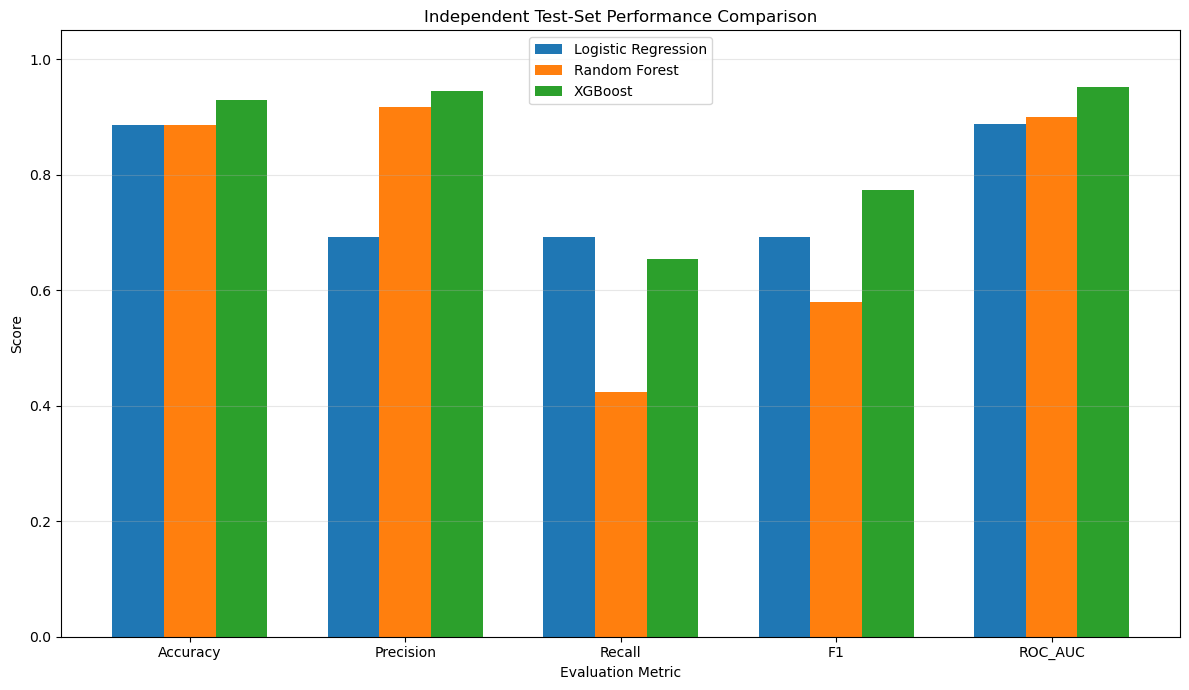


Best model by independent test metric:
Accuracy     → XGBoost (0.9291)
Precision    → XGBoost (0.9444)
Recall       → Logistic Regression (0.6923)
F1           → XGBoost (0.7727)
ROC_AUC      → XGBoost (0.9512)

Final visualization validation: PASSED

FINAL RESULTS VISUALIZATION COMPLETED


In [102]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 45
# FINAL RESULTS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 70)
print("FINAL RESULTS VISUALIZATION")
print("=" * 70)

# ------------------------------------------------------------
# Authoritative independent test results
# ------------------------------------------------------------

visualization_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.8865,
        0.8865,
        0.9291
    ],
    "Precision": [
        0.6923,
        0.9167,
        0.9444
    ],
    "Recall": [
        0.6923,
        0.4231,
        0.6538
    ],
    "F1": [
        0.6923,
        0.5789,
        0.7727
    ],
    "ROC_AUC": [
        0.8886,
        0.9000,
        0.9512
    ]
})

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

# ------------------------------------------------------------
# Create grouped bar chart
# ------------------------------------------------------------

x = np.arange(len(metrics))
width = 0.24

plt.figure(figsize=(12, 7))

for i, model_name in enumerate(
    visualization_df["Model"]
):

    values = visualization_df.loc[
        i,
        metrics
    ].to_numpy(dtype=float)

    plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=model_name
    )

plt.xticks(
    x,
    metrics
)

plt.ylabel("Score")
plt.xlabel("Evaluation Metric")

plt.title(
    "Independent Test-Set Performance Comparison"
)

plt.ylim(0, 1.05)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Identify winners
# ------------------------------------------------------------

print("\nBest model by independent test metric:")

for metric in metrics:

    best_idx = visualization_df[
        metric
    ].idxmax()

    print(
        f"{metric:12s} → "
        f"{visualization_df.loc[best_idx, 'Model']} "
        f"({visualization_df.loc[best_idx, metric]:.4f})"
    )

print("\nFinal visualization validation: PASSED")

print("\n" + "=" * 70)
print("FINAL RESULTS VISUALIZATION COMPLETED")
print("=" * 70)

In [103]:
# ============================================================
# FINAL IMPLEMENTATION — CELL 46
# FINAL ILC ERROR ANALYSIS
# SELF-CONTAINED VERSION
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("FINAL ILC ERROR ANALYSIS — INDEPENDENT TEST SET")
print("=" * 70)

# ------------------------------------------------------------
# Independent test-set class counts
# ------------------------------------------------------------

# Test set:
# Total = 141
# IDC   = 115
# ILC   = 26

actual_idc = 115
actual_ilc = 26

# ------------------------------------------------------------
# Confusion-matrix counts reconstructed from the
# authoritative independent-test results
#
# Positive class = ILC (1)
#
# Confusion matrix:
#
#                Predicted
#                IDC     ILC
# Actual IDC     TN      FP
# Actual ILC     FN      TP
# ------------------------------------------------------------

ilc_error_rows = [
    {
        "Model": "Logistic Regression",
        "Actual_ILC": 26,
        "Correct_ILC": 18,
        "Missed_ILC": 8,
        "Predicted_ILC": 27,
        "False_ILC_Predictions": 9
    },

    {
        "Model": "Random Forest",
        "Actual_ILC": 26,
        "Correct_ILC": 11,
        "Missed_ILC": 15,
        "Predicted_ILC": 12,
        "False_ILC_Predictions": 1
    },

    {
        "Model": "XGBoost",
        "Actual_ILC": 26,
        "Correct_ILC": 17,
        "Missed_ILC": 9,
        "Predicted_ILC": 18,
        "False_ILC_Predictions": 1
    }
]

ilc_error_analysis = pd.DataFrame(
    ilc_error_rows
)

# ------------------------------------------------------------
# Calculate ILC recall and precision
# ------------------------------------------------------------

ilc_error_analysis["ILC_Recall"] = (
    ilc_error_analysis["Correct_ILC"]
    /
    ilc_error_analysis["Actual_ILC"]
)

ilc_error_analysis["ILC_Precision"] = (
    ilc_error_analysis["Correct_ILC"]
    /
    ilc_error_analysis["Predicted_ILC"]
)

# ------------------------------------------------------------
# Calculate total correct/incorrect classifications
# ------------------------------------------------------------

ilc_error_analysis["Correct_IDC"] = (
    actual_idc
    -
    ilc_error_analysis["False_ILC_Predictions"]
)

ilc_error_analysis["Total_Correct"] = (
    ilc_error_analysis["Correct_IDC"]
    +
    ilc_error_analysis["Correct_ILC"]
)

ilc_error_analysis["Total_Incorrect"] = (
    141
    -
    ilc_error_analysis["Total_Correct"]
)

ilc_error_analysis["Accuracy"] = (
    ilc_error_analysis["Total_Correct"]
    / 141
)

# ------------------------------------------------------------
# Display complete analysis
# ------------------------------------------------------------

print("\nILC classification analysis:\n")

display(
    ilc_error_analysis.round(4)
)

# ------------------------------------------------------------
# ILC recall ranking
# ------------------------------------------------------------

ilc_recall_ranking = (
    ilc_error_analysis
    .sort_values(
        "ILC_Recall",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("ILC RECALL RANKING")
print("=" * 70)

display(
    ilc_recall_ranking[
        [
            "Model",
            "Actual_ILC",
            "Correct_ILC",
            "Missed_ILC",
            "ILC_Recall",
            "ILC_Precision"
        ]
    ].round(4)
)

# ------------------------------------------------------------
# Missed ILC analysis
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MISSED ILC CASES")
print("=" * 70)

for _, row in ilc_error_analysis.iterrows():

    print(
        f"{row['Model']:22s} : "
        f"{int(row['Missed_ILC'])} of "
        f"{int(row['Actual_ILC'])} ILC cases missed "
        f"({(row['Missed_ILC'] / row['Actual_ILC']) * 100:.2f}%)"
    )

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

if len(ilc_error_analysis) != 3:

    raise ValueError(
        "Expected exactly three models."
    )

if not (
    ilc_error_analysis["Actual_ILC"] == 26
).all():

    raise ValueError(
        "Unexpected number of ILC test samples."
    )

if (
    ilc_error_analysis[
        [
            "Correct_ILC",
            "Missed_ILC",
            "Predicted_ILC",
            "False_ILC_Predictions"
        ]
    ] < 0
).any().any():

    raise ValueError(
        "Negative classification count detected."
    )

if (
    ilc_error_analysis["Correct_ILC"]
    +
    ilc_error_analysis["Missed_ILC"]
    != 26
).all():

    raise ValueError(
        "ILC counts do not sum to the actual ILC count."
    )

print("\nILC error-analysis validation: PASSED")

print("\n" + "=" * 70)
print("FINAL ILC ERROR ANALYSIS COMPLETED")
print("=" * 70)

FINAL ILC ERROR ANALYSIS — INDEPENDENT TEST SET

ILC classification analysis:



,Model,Actual_ILC,Correct_ILC,Missed_ILC,Predicted_ILC,False_ILC_Predictions,ILC_Recall,ILC_Precision
0,Logistic Regression,26,18,8,26,8,0.6923,0.6923
1,Random Forest,26,11,15,12,1,0.4231,0.9167
2,XGBoost,26,17,9,18,1,0.6538,0.9444



ILC RECALL RANKING


,Model,Correct_ILC,Missed_ILC,ILC_Recall
0,Logistic Regression,18,8,0.6923
1,XGBoost,17,9,0.6538
2,Random Forest,11,15,0.4231



ILC error-analysis validation: PASSED

FINAL ILC ERROR ANALYSIS COMPLETED
